# 09 — SPY Implied Volatility Inversion and Surface-Grade Filtering

This notebook converts the quote-quality SPY option-chain panel from Notebook 08 into an implied-volatility panel suitable for raw surface diagnostics.

Notebook 08 answered:

> Can SPY option-chain quotes be ingested, standardized, and filtered into a usable contract panel?

This notebook answers:

> Which of those quotes can become reliable implied-volatility and total-variance surface observations?

The purpose of this notebook is **quality control**, not model fitting. It applies Black-Scholes-Merton price bounds, implied-volatility inversion, low-vega diagnostics, bid-ask IV uncertainty checks, call-put reconciliation, and stricter surface-grade filtering.

The final output is a filtered empirical IV panel for Notebook 10, where raw static-arbitrage diagnostics will be applied.

---

## Research role in the project sequence

This notebook sits between market ingestion and surface diagnostics:

1. Notebook 08: ingest and quote-filter SPY option-chain data  
2. Notebook 09: invert implied volatility and construct a surface-grade panel  
3. Notebook 10: diagnose raw static-arbitrage violations  
4. Notebook 11: smooth or repair the surface only after raw diagnostics are understood  

This notebook does **not** smooth, repair, or calibrate the volatility surface.

---

## Allowed claims

If the notebook passes its validation checks, the following claims are allowed:

| Claim | Meaning |
|---|---|
| IV inversion was attempted only after no-arbitrage price-bound checks | Prices outside Black-Scholes-Merton bounds are not blindly inverted |
| Valid implied volatilities were classified by numerical quality | IV existence is separated from IV reliability |
| Low-vega and near-intrinsic contracts were flagged | The notebook identifies unstable IV observations |
| Bid-ask IV uncertainty was measured where possible | Mid IV is not treated as exact market truth |
| Call-put consistency was checked at matched expiry-strike pairs | Duplicate call/put surface information is reconciled rather than blindly pooled |
| A stricter surface-grade subset was produced | Notebook 10 receives a cleaner diagnostic panel |
| Exclusions are auditable | Rejected rows are preserved with rejection reasons |

---

## Not allowed claims

This notebook does **not** allow the following claims:

| Not allowed claim | Reason |
|---|---|
| The SPY volatility surface is arbitrage-free | Static-arbitrage diagnostics are deferred to Notebook 10 |
| The filtered panel is the true market surface | It is only a research-grade subset created under stated assumptions |
| SVI, SSVI, Heston, or Bates calibration is justified | Model fitting is outside this notebook |
| Removed quotes are wrong | They are only unsuitable for this workflow under the chosen filters |
| The surface is smooth | No smoothing is performed here |
| Mid prices are exact | Bid-ask uncertainty is explicitly tracked |

---

## Main outputs

This notebook produces the following handoff artifacts:

| Artifact | Purpose |
|---|---|
| `iv_grade_panel` | Rows with valid central implied volatility |
| `surface_candidate_panel` | OTM-preferred or call-put reconciled observations |
| `surface_grade_panel` | Final strict panel for Notebook 10 |
| `rejection_ledger` | Row-level exclusion reasons |
| `expiry_viability_table` | Expiry-level surface usability summary |
| `filter_funnel_table` | Row counts through each filtering tier |
| `notebook_09_metadata` | Snapshot, assumptions, thresholds, and validation status |

---

## Final notebook target

The notebook is considered ready only if:

1. Notebook 08 artifacts load successfully.
2. Black-Scholes-Merton price-bound checks are completed.
3. Implied-volatility inversion succeeds for the IV-grade subset.
4. Low-vega, time-value, and bid-ask IV instability are flagged.
5. Call-put pair consistency is measured.
6. A one-observation-per-expiry-strike surface panel is created.
7. Every exclusion is recorded in the rejection ledger.
8. The final surface-grade panel passes handoff validation.

The final readiness flag is:

`NOTEBOOK_09_READY_FOR_10`

In [1]:
# ============================================================
# Notebook 09 Setup
# SPY Implied Volatility Inversion and Surface-Grade Filtering
# ============================================================

from __future__ import annotations

import json
import math
import os
import platform
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.stats import norm


# ------------------------------------------------------------
# Global display and numerical settings
# ------------------------------------------------------------

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

np.set_printoptions(
    precision=6,
    suppress=True,
    linewidth=180,
)

RNG_SEED = 62009
rng = np.random.default_rng(RNG_SEED)


# ------------------------------------------------------------
# Notebook identity
# ------------------------------------------------------------

NOTEBOOK_ID = "09_spy_implied_volatility_inversion_and_surface_grade_filtering"
NOTEBOOK_SHORT_NAME = "N09"
UNDERLYING = "SPY"

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat(timespec="seconds")


# ------------------------------------------------------------
# Project path resolution
# ------------------------------------------------------------

def first_existing_path(candidates: Iterable[Path]) -> Path:
    """
    Return the first existing path from a list of candidates.

    This keeps the notebook portable across:
    - local Windows project folders
    - relative project execution
    - sandbox or cloud execution
    """
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError(
        "None of the candidate project roots exist:\n"
        + "\n".join(str(p) for p in candidates)
    )


PROJECT_ROOT = first_existing_path(
    [
        Path(os.environ.get("DERIVATIVE_PRICING_PROJECT_ROOT", "")),
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data"),
        Path(r"D:\Derivative Pricing project"),
    ]
)

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
N08_OUTPUT_DIR = OUTPUT_ROOT / "08_spy_option_chain_ingestion_and_quote_filtering"
N09_OUTPUT_DIR = OUTPUT_ROOT / NOTEBOOK_ID

N09_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Expected Notebook 08 artifact names
# ------------------------------------------------------------

N08_ARTIFACT_CANDIDATES = {
    "quote_quality_panel": [
        N08_OUTPUT_DIR / "quote_quality_panel.parquet",
        N08_OUTPUT_DIR / "spy_quote_quality_panel.parquet",
        N08_OUTPUT_DIR / "n08_quote_quality_panel.parquet",
        N08_OUTPUT_DIR / "quote_quality_passed_panel.parquet",
        N08_OUTPUT_DIR / "surface_candidate_input.parquet",
    ],
    "rejection_ledger_n08": [
        N08_OUTPUT_DIR / "rejection_ledger.parquet",
        N08_OUTPUT_DIR / "n08_rejection_ledger.parquet",
        N08_OUTPUT_DIR / "quote_rejection_ledger.parquet",
    ],
    "matched_pairs": [
        N08_OUTPUT_DIR / "matched_call_put_pairs.parquet",
        N08_OUTPUT_DIR / "n08_matched_pairs.parquet",
        N08_OUTPUT_DIR / "parity_forward_pairs.parquet",
    ],
    "metadata": [
        N08_OUTPUT_DIR / "metadata.json",
        N08_OUTPUT_DIR / "n08_metadata.json",
        N08_OUTPUT_DIR / "notebook_08_metadata.json",
    ],
}


# ------------------------------------------------------------
# Conservative research thresholds
# ------------------------------------------------------------

@dataclass(frozen=True)
class N09Thresholds:
    """
    Research filters for IV-grade and surface-grade panel construction.

    These are not universal market rules. They are conservative filters
    designed to prevent obvious quote noise and ill-conditioned IVs from
    dominating Notebook 10 static-arbitrage diagnostics.
    """

    # Maturity filters
    min_dte_main_surface: int = 5
    min_time_to_maturity: float = 1.0 / 365.0

    # Quote-quality filters stricter than Notebook 08
    max_relative_spread_surface: float = 0.25
    max_absolute_spread_surface: float = 3.00

    # IV inversion bounds
    min_iv: float = 1e-6
    max_iv: float = 5.00

    # Numerical stability
    min_vega_surface: float = 1e-4
    min_time_value_surface: float = 1e-4
    max_iv_bid_ask_width_surface: float = 0.50

    # Pair consistency
    max_call_put_iv_diff_surface: float = 0.10
    max_parity_residual_bps_surface: float = 100.0

    # Expiry viability
    min_surface_strikes_per_expiry: int = 8
    min_left_wing_points: int = 3
    min_right_wing_points: int = 3

    # ATM definition using absolute forward log-moneyness
    atm_log_moneyness_band: float = 0.025

    # OTM quote selection
    otm_switch_band: float = 0.005


THRESHOLDS = N09Thresholds()


# ------------------------------------------------------------
# Notebook metadata shell
# ------------------------------------------------------------

notebook_09_metadata: dict[str, Any] = {
    "notebook_id": NOTEBOOK_ID,
    "notebook_short_name": NOTEBOOK_SHORT_NAME,
    "underlying": UNDERLYING,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "rng_seed": RNG_SEED,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "project_root": str(PROJECT_ROOT),
    "output_dir": str(N09_OUTPUT_DIR),
    "n08_output_dir": str(N08_OUTPUT_DIR),
    "thresholds": asdict(THRESHOLDS),
    "readiness_flag": "NOT_STARTED",
}


print(f"{NOTEBOOK_SHORT_NAME} setup complete.")
print(f"Project root: {PROJECT_ROOT}")
print(f"N08 output directory: {N08_OUTPUT_DIR}")
print(f"N09 output directory: {N09_OUTPUT_DIR}")
print(f"Run timestamp UTC: {RUN_TIMESTAMP_UTC}")

N09 setup complete.
Project root: D:\Derivative Pricing Project v1.0+\V1.1
N08 output directory: D:\Derivative Pricing Project v1.0+\V1.1\outputs\08_spy_option_chain_ingestion_and_quote_filtering
N09 output directory: D:\Derivative Pricing Project v1.0+\V1.1\outputs\09_spy_implied_volatility_inversion_and_surface_grade_filtering
Run timestamp UTC: 2026-07-05T16:51:31+00:00


In [2]:
# ============================================================
# Load Notebook 08 Artifacts from Actual Data Paths
# ============================================================

DATA_ROOT = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_ROOT / "raw"
PROCESSED_DATA_DIR = DATA_ROOT / "processed"
MANIFEST_DIR = DATA_ROOT / "manifest"

N08_SNAPSHOT_TAG = "20260705_154512_UTC"

N08_EXPLICIT_ARTIFACTS = {
    "manifest": MANIFEST_DIR / f"spy_option_snapshot_manifest_{N08_SNAPSHOT_TAG}.json",
    "raw_snapshot": RAW_DATA_DIR / f"spy_option_chain_raw_snapshot_{N08_SNAPSHOT_TAG}.parquet",
    "raw_quote_panel": PROCESSED_DATA_DIR / f"spy_option_quote_panel_raw_{N08_SNAPSHOT_TAG}.parquet",
    "filtered_quote_panel": PROCESSED_DATA_DIR / f"spy_option_quote_panel_filtered_{N08_SNAPSHOT_TAG}.parquet",
    "n09_candidate_panel": PROCESSED_DATA_DIR / f"spy_option_n09_candidate_{N08_SNAPSHOT_TAG}.parquet",
    "matched_pairs": PROCESSED_DATA_DIR / f"spy_option_matched_pairs_{N08_SNAPSHOT_TAG}.parquet",
    "rejection_ledger_n08": PROCESSED_DATA_DIR / f"spy_option_rejection_ledger_{N08_SNAPSHOT_TAG}.csv",
    "expiry_summary": PROCESSED_DATA_DIR / f"spy_option_expiry_summary_{N08_SNAPSHOT_TAG}.csv",
    "final_validation_ledger_n08": PROCESSED_DATA_DIR / f"spy_notebook08_final_validation_ledger_{N08_SNAPSHOT_TAG}.csv",
}


# ------------------------------------------------------------
# Artifact existence check
# ------------------------------------------------------------

artifact_status = []

for name, path in N08_EXPLICIT_ARTIFACTS.items():
    artifact_status.append(
        {
            "artifact": name,
            "path": str(path),
            "exists": path.exists(),
            "suffix": path.suffix.lower(),
            "size_mb": path.stat().st_size / 1_000_000 if path.exists() else np.nan,
            "modified_utc": (
                datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat(timespec="seconds")
                if path.exists()
                else None
            ),
        }
    )

n08_artifact_status = pd.DataFrame(artifact_status)

display(
    n08_artifact_status[
        ["artifact", "exists", "suffix", "size_mb", "modified_utc", "path"]
    ]
)

missing_artifacts = n08_artifact_status.loc[
    ~n08_artifact_status["exists"], "artifact"
].tolist()

if missing_artifacts:
    raise FileNotFoundError(
        "Missing required Notebook 08 artifact(s): "
        + ", ".join(missing_artifacts)
        + "\n\nChecked paths:\n"
        + "\n".join(str(N08_EXPLICIT_ARTIFACTS[name]) for name in missing_artifacts)
    )


# ------------------------------------------------------------
# File readers
# ------------------------------------------------------------

def read_artifact(path: Path) -> Any:
    """
    Read a Notebook 08 artifact based on file suffix.
    """
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    raise ValueError(f"Unsupported artifact suffix: {suffix} for path {path}")


n08_manifest = read_artifact(N08_EXPLICIT_ARTIFACTS["manifest"])
n08_raw_snapshot = read_artifact(N08_EXPLICIT_ARTIFACTS["raw_snapshot"])
n08_raw_quote_panel = read_artifact(N08_EXPLICIT_ARTIFACTS["raw_quote_panel"])
n08_filtered_quote_panel = read_artifact(N08_EXPLICIT_ARTIFACTS["filtered_quote_panel"])
n08_candidate_panel = read_artifact(N08_EXPLICIT_ARTIFACTS["n09_candidate_panel"])
n08_matched_pairs = read_artifact(N08_EXPLICIT_ARTIFACTS["matched_pairs"])
n08_rejection_ledger = read_artifact(N08_EXPLICIT_ARTIFACTS["rejection_ledger_n08"])
n08_expiry_summary = read_artifact(N08_EXPLICIT_ARTIFACTS["expiry_summary"])
n08_final_validation_ledger = read_artifact(N08_EXPLICIT_ARTIFACTS["final_validation_ledger_n08"])


# ------------------------------------------------------------
# Basic shape and schema summary
# ------------------------------------------------------------

n08_loaded_summary = pd.DataFrame(
    [
        {
            "artifact": "raw_snapshot",
            "rows": len(n08_raw_snapshot),
            "columns": n08_raw_snapshot.shape[1],
        },
        {
            "artifact": "raw_quote_panel",
            "rows": len(n08_raw_quote_panel),
            "columns": n08_raw_quote_panel.shape[1],
        },
        {
            "artifact": "filtered_quote_panel",
            "rows": len(n08_filtered_quote_panel),
            "columns": n08_filtered_quote_panel.shape[1],
        },
        {
            "artifact": "n09_candidate_panel",
            "rows": len(n08_candidate_panel),
            "columns": n08_candidate_panel.shape[1],
        },
        {
            "artifact": "matched_pairs",
            "rows": len(n08_matched_pairs),
            "columns": n08_matched_pairs.shape[1],
        },
        {
            "artifact": "rejection_ledger_n08",
            "rows": len(n08_rejection_ledger),
            "columns": n08_rejection_ledger.shape[1],
        },
        {
            "artifact": "expiry_summary",
            "rows": len(n08_expiry_summary),
            "columns": n08_expiry_summary.shape[1],
        },
        {
            "artifact": "final_validation_ledger_n08",
            "rows": len(n08_final_validation_ledger),
            "columns": n08_final_validation_ledger.shape[1],
        },
    ]
)

display(n08_loaded_summary)


# ------------------------------------------------------------
# Select Notebook 09 starting panel
# ------------------------------------------------------------

n09_input_panel = n08_candidate_panel.copy()

n09_input_panel["n09_source_artifact"] = "spy_option_n09_candidate"
n09_input_panel["n09_snapshot_tag"] = N08_SNAPSHOT_TAG


# ------------------------------------------------------------
# Manifest and metadata extraction
# ------------------------------------------------------------

def flatten_manifest_top_level(manifest: dict[str, Any]) -> pd.DataFrame:
    """
    Display non-nested manifest fields for quick audit.
    """
    rows = []

    for key, value in manifest.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            rows.append({"field": key, "value": value})
        else:
            rows.append({"field": key, "value": f"<{type(value).__name__}>"})

    return pd.DataFrame(rows)


display(flatten_manifest_top_level(n08_manifest))


# ------------------------------------------------------------
# Required minimum schema check for Notebook 09
# ------------------------------------------------------------

required_any_price_cols = {"bid", "ask", "mid", "lastPrice", "last_price"}
required_core_cols = {
    "option_type",
    "expiry",
    "strike",
}

available_cols = set(n09_input_panel.columns)

missing_core_cols = sorted(required_core_cols - available_cols)
available_price_cols = sorted(required_any_price_cols & available_cols)

if missing_core_cols:
    raise ValueError(
        "N09 input panel is missing required core column(s): "
        + ", ".join(missing_core_cols)
        + "\nAvailable columns:\n"
        + ", ".join(sorted(n09_input_panel.columns))
    )

if not available_price_cols:
    raise ValueError(
        "N09 input panel does not contain any recognized price column. "
        f"Expected at least one of: {sorted(required_any_price_cols)}"
    )


# ------------------------------------------------------------
# Snapshot-level audit
# ------------------------------------------------------------

print("Notebook 08 artifacts loaded successfully.")
print(f"Snapshot tag: {N08_SNAPSHOT_TAG}")
print(f"N09 input panel shape: {n09_input_panel.shape}")
print(f"Available price columns: {available_price_cols}")
print(f"Input columns: {list(n09_input_panel.columns)}")


# ------------------------------------------------------------
# Update notebook metadata
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "n08_snapshot_tag": N08_SNAPSHOT_TAG,
        "n08_artifact_paths": {
            name: str(path) for name, path in N08_EXPLICIT_ARTIFACTS.items()
        },
        "n08_loaded_summary": n08_loaded_summary.to_dict(orient="records"),
        "n09_input_rows": int(len(n09_input_panel)),
        "n09_input_columns": int(n09_input_panel.shape[1]),
        "readiness_flag": "N08_ARTIFACTS_LOADED",
    }
)

,artifact,exists,suffix,size_mb,modified_utc,path
0,manifest,True,.json,0.007558,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
1,raw_snapshot,True,.parquet,0.199906,2026-07-05T15:45:16+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
2,raw_quote_panel,True,.parquet,0.225046,2026-07-05T15:45:16+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
3,filtered_quote_panel,True,.parquet,0.379840,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
4,n09_candidate_panel,True,.parquet,0.427713,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
5,matched_pairs,True,.parquet,0.425952,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
6,rejection_ledger_n08,True,.csv,0.161702,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
7,expiry_summary,True,.csv,0.010381,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...
8,final_validation_ledger_n08,True,.csv,0.004845,2026-07-05T15:45:17+00:00,D:\Derivative Pricing Project v1.0+\V1.1\data\...


,artifact,rows,columns
0,raw_snapshot,3954,20
1,raw_quote_panel,3954,25
2,filtered_quote_panel,3527,84
3,n09_candidate_panel,3527,92
4,matched_pairs,1510,75
5,rejection_ledger_n08,427,48
6,expiry_summary,12,72
7,final_validation_ledger_n08,29,6


,field,value
0,notebook_id,08_spy_option_chain_ingestion_and_quote_filtering
1,notebook_version,v1.1
2,run_id,20260705_154512_UTC
3,run_timestamp_utc,2026-07-05T15:45:12.973274+00:00
4,ticker,SPY
5,data_source,yfinance
6,snapshot_policy,pull_then_cache
7,config,<dict>
8,artifact_paths,<dict>
9,environment,<dict>


Notebook 08 artifacts loaded successfully.
Snapshot tag: 20260705_154512_UTC
N09 input panel shape: (3527, 94)
Available price columns: ['ask', 'bid', 'last_price', 'mid']
Input columns: ['row_id', 'snapshot_ts_utc', 'snapshot_date_utc', 'ticker', 'source', 'option_type', 'expiry', 'expiry_ts', 'dte_calendar', 'tau_years', 'strike', 'contract_symbol', 'last_trade_date', 'last_price', 'bid', 'ask', 'change', 'percent_change', 'volume', 'open_interest', 'vendor_implied_vol', 'vendor_in_the_money', 'contract_size', 'currency', 'underlying_spot_snapshot', 'mid', 'spread', 'rel_spread_mid', 'spread_bps_mid', 'has_bid', 'has_ask', 'has_last_price', 'is_crossed_market', 'is_locked_market', 'is_zero_bid', 'is_zero_ask', 'is_nonpositive_mid', 'is_dust_mid', 'is_wide_abs_spread', 'is_wide_rel_spread', 'has_open_interest', 'has_volume', 'moneyness_spot', 'log_moneyness_spot', 'abs_log_moneyness_spot', 'intrinsic_spot', 'extrinsic_mid_vs_spot', 'negative_extrinsic_vs_spot', 'last_trade_age_days', 

In [3]:
# ============================================================
# Contract Panel Construction and Pricing Convention Fields
# ============================================================

# Work only from the Notebook 08 candidate handoff.
contract_panel = n09_input_panel.copy()

contract_panel = contract_panel.reset_index(drop=True)
contract_panel["n09_row_id"] = np.arange(len(contract_panel), dtype=int)


# ------------------------------------------------------------
# Column normalization
# ------------------------------------------------------------

required_columns = [
    "row_id",
    "snapshot_ts_utc",
    "ticker",
    "option_type",
    "expiry",
    "dte_calendar",
    "tau_years",
    "strike",
    "bid",
    "ask",
    "mid",
    "last_price",
    "underlying_spot_snapshot",
    "median_parity_forward_proxy",
    "usable_forward_proxy",
    "median_carry_rate_proxy",
    "forward_log_moneyness_proxy",
    "abs_forward_log_moneyness_proxy",
    "rel_spread_mid",
    "spread",
    "quote_quality_bucket",
    "notebook09_candidate",
]

missing_columns = [col for col in required_columns if col not in contract_panel.columns]

if missing_columns:
    raise ValueError(
        "Contract panel is missing required column(s): "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# Type coercion
# ------------------------------------------------------------

date_cols = [
    "snapshot_ts_utc",
    "expiry",
]

numeric_cols = [
    "dte_calendar",
    "tau_years",
    "strike",
    "bid",
    "ask",
    "mid",
    "last_price",
    "underlying_spot_snapshot",
    "median_parity_forward_proxy",
    "median_carry_rate_proxy",
    "forward_log_moneyness_proxy",
    "abs_forward_log_moneyness_proxy",
    "rel_spread_mid",
    "spread",
]

for col in date_cols:
    contract_panel[col] = pd.to_datetime(contract_panel[col], errors="coerce", utc=True)

for col in numeric_cols:
    contract_panel[col] = pd.to_numeric(contract_panel[col], errors="coerce")

contract_panel["option_type"] = (
    contract_panel["option_type"]
    .astype(str)
    .str.lower()
    .str.strip()
)

contract_panel["ticker"] = (
    contract_panel["ticker"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ------------------------------------------------------------
# Basic row-level integrity checks
# ------------------------------------------------------------

contract_panel["n09_valid_option_type"] = contract_panel["option_type"].isin(["call", "put"])
contract_panel["n09_positive_strike"] = contract_panel["strike"] > 0
contract_panel["n09_positive_tau"] = contract_panel["tau_years"] > 0
contract_panel["n09_positive_spot"] = contract_panel["underlying_spot_snapshot"] > 0
contract_panel["n09_positive_mid"] = contract_panel["mid"] > 0
contract_panel["n09_valid_bid_ask"] = (
    contract_panel["bid"].notna()
    & contract_panel["ask"].notna()
    & (contract_panel["bid"] >= 0)
    & (contract_panel["ask"] >= contract_panel["bid"])
)

contract_panel["n09_basic_integrity_pass"] = (
    contract_panel["n09_valid_option_type"]
    & contract_panel["n09_positive_strike"]
    & contract_panel["n09_positive_tau"]
    & contract_panel["n09_positive_spot"]
    & contract_panel["n09_positive_mid"]
    & contract_panel["n09_valid_bid_ask"]
)


# ------------------------------------------------------------
# Pricing convention
# ------------------------------------------------------------
# N08 already provides a parity-implied forward proxy by expiry.
#
# For this notebook, the primary moneyness object is:
#
#     k = log(K / F)
#
# where F is the expiry-level forward proxy from N08.
#
# Discounting is needed for Black-Scholes-Merton bounds and IV inversion.
# Since N08 provides net carry but not necessarily a separate risk-free and
# dividend curve, this notebook uses a conservative flat risk-free proxy.
#
# The implied dividend yield is then:
#
#     q = r - carry
#
# where carry = log(F / S) / T.
#
# This preserves the observed forward relationship:
#
#     F = S * exp((r - q)T)
#
# subject to available N08 forward data.

DEFAULT_FLAT_RISK_FREE_RATE = 0.045

def extract_config_value(manifest: dict[str, Any], possible_keys: list[str], default: Any = None) -> Any:
    """
    Search the top-level manifest and its config dictionary for a value.
    """
    for key in possible_keys:
        if key in manifest:
            return manifest[key]

    config = manifest.get("config", {})
    if isinstance(config, dict):
        for key in possible_keys:
            if key in config:
                return config[key]

    return default


flat_risk_free_rate = extract_config_value(
    n08_manifest,
    possible_keys=[
        "flat_risk_free_rate",
        "risk_free_rate",
        "rate_annual",
        "default_rate_annual",
    ],
    default=DEFAULT_FLAT_RISK_FREE_RATE,
)

flat_risk_free_rate = float(flat_risk_free_rate)


contract_panel["spot"] = contract_panel["underlying_spot_snapshot"]

contract_panel["forward"] = np.where(
    contract_panel["usable_forward_proxy"].astype(bool)
    & contract_panel["median_parity_forward_proxy"].notna()
    & (contract_panel["median_parity_forward_proxy"] > 0),
    contract_panel["median_parity_forward_proxy"],
    contract_panel["spot"] * np.exp(
        contract_panel["median_carry_rate_proxy"].fillna(0.0)
        * contract_panel["tau_years"]
    ),
)

contract_panel["forward"] = np.where(
    contract_panel["forward"].notna() & (contract_panel["forward"] > 0),
    contract_panel["forward"],
    contract_panel["spot"],
)

contract_panel["net_carry_rate"] = np.where(
    contract_panel["spot"].gt(0)
    & contract_panel["forward"].gt(0)
    & contract_panel["tau_years"].gt(0),
    np.log(contract_panel["forward"] / contract_panel["spot"]) / contract_panel["tau_years"],
    np.nan,
)

contract_panel["rate_annual"] = flat_risk_free_rate
contract_panel["dividend_yield_annual"] = contract_panel["rate_annual"] - contract_panel["net_carry_rate"]

contract_panel["discount_factor"] = np.exp(
    -contract_panel["rate_annual"] * contract_panel["tau_years"]
)

contract_panel["dividend_discount_factor"] = np.exp(
    -contract_panel["dividend_yield_annual"] * contract_panel["tau_years"]
)

contract_panel["log_moneyness_forward"] = np.log(
    contract_panel["strike"] / contract_panel["forward"]
)

contract_panel["abs_log_moneyness_forward"] = contract_panel["log_moneyness_forward"].abs()

contract_panel["moneyness_forward"] = contract_panel["strike"] / contract_panel["forward"]


# ------------------------------------------------------------
# Moneyness buckets
# ------------------------------------------------------------

contract_panel["is_atm_forward"] = (
    contract_panel["abs_log_moneyness_forward"] <= THRESHOLDS.atm_log_moneyness_band
)

contract_panel["is_otm_by_forward"] = np.select(
    [
        (contract_panel["option_type"] == "call") & (contract_panel["strike"] > contract_panel["forward"]),
        (contract_panel["option_type"] == "put") & (contract_panel["strike"] < contract_panel["forward"]),
    ],
    [
        True,
        True,
    ],
    default=False,
)

contract_panel["moneyness_bucket"] = pd.cut(
    contract_panel["log_moneyness_forward"],
    bins=[-np.inf, -0.20, -0.10, -0.025, 0.025, 0.10, 0.20, np.inf],
    labels=[
        "deep_left",
        "left_wing",
        "near_left",
        "atm",
        "near_right",
        "right_wing",
        "deep_right",
    ],
)


# ------------------------------------------------------------
# Intrinsic and time value under selected convention
# ------------------------------------------------------------

call_intrinsic = np.maximum(
    contract_panel["spot"] * contract_panel["dividend_discount_factor"]
    - contract_panel["strike"] * contract_panel["discount_factor"],
    0.0,
)

put_intrinsic = np.maximum(
    contract_panel["strike"] * contract_panel["discount_factor"]
    - contract_panel["spot"] * contract_panel["dividend_discount_factor"],
    0.0,
)

contract_panel["bsm_intrinsic_value"] = np.where(
    contract_panel["option_type"] == "call",
    call_intrinsic,
    put_intrinsic,
)

contract_panel["bsm_time_value_mid"] = (
    contract_panel["mid"] - contract_panel["bsm_intrinsic_value"]
)

contract_panel["bsm_time_value_bid"] = (
    contract_panel["bid"] - contract_panel["bsm_intrinsic_value"]
)

contract_panel["bsm_time_value_ask"] = (
    contract_panel["ask"] - contract_panel["bsm_intrinsic_value"]
)


# ------------------------------------------------------------
# DTE buckets
# ------------------------------------------------------------

contract_panel["dte_bucket"] = pd.cut(
    contract_panel["dte_calendar"],
    bins=[-np.inf, 4, 14, 30, 60, 120, 250, np.inf],
    labels=[
        "ultra_short",
        "short",
        "one_month",
        "two_month",
        "quarter",
        "medium",
        "long",
    ],
)


# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------

contract_panel_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(contract_panel)},
        {"metric": "calls", "value": int((contract_panel["option_type"] == "call").sum())},
        {"metric": "puts", "value": int((contract_panel["option_type"] == "put").sum())},
        {"metric": "expiries", "value": int(contract_panel["expiry"].nunique())},
        {"metric": "basic_integrity_pass_rows", "value": int(contract_panel["n09_basic_integrity_pass"].sum())},
        {"metric": "basic_integrity_fail_rows", "value": int((~contract_panel["n09_basic_integrity_pass"]).sum())},
        {"metric": "otm_by_forward_rows", "value": int(contract_panel["is_otm_by_forward"].sum())},
        {"metric": "atm_forward_rows", "value": int(contract_panel["is_atm_forward"].sum())},
        {"metric": "flat_risk_free_rate_used", "value": flat_risk_free_rate},
    ]
)

expiry_contract_summary = (
    contract_panel
    .groupby("expiry", dropna=False)
    .agg(
        rows=("n09_row_id", "size"),
        calls=("option_type", lambda x: int((x == "call").sum())),
        puts=("option_type", lambda x: int((x == "put").sum())),
        dte_calendar=("dte_calendar", "median"),
        tau_years=("tau_years", "median"),
        spot=("spot", "median"),
        forward=("forward", "median"),
        net_carry_rate=("net_carry_rate", "median"),
        dividend_yield_annual=("dividend_yield_annual", "median"),
        min_log_moneyness=("log_moneyness_forward", "min"),
        max_log_moneyness=("log_moneyness_forward", "max"),
        atm_rows=("is_atm_forward", "sum"),
        otm_rows=("is_otm_by_forward", "sum"),
        median_rel_spread=("rel_spread_mid", "median"),
    )
    .reset_index()
    .sort_values("expiry")
)

display(contract_panel_summary)
display(expiry_contract_summary)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

contract_panel_validation = pd.DataFrame(
    [
        {
            "check": "all rows have valid option type",
            "passed": bool(contract_panel["n09_valid_option_type"].all()),
            "detail": int((~contract_panel["n09_valid_option_type"]).sum()),
        },
        {
            "check": "all rows have positive strike",
            "passed": bool(contract_panel["n09_positive_strike"].all()),
            "detail": int((~contract_panel["n09_positive_strike"]).sum()),
        },
        {
            "check": "all rows have positive tau",
            "passed": bool(contract_panel["n09_positive_tau"].all()),
            "detail": int((~contract_panel["n09_positive_tau"]).sum()),
        },
        {
            "check": "all rows have positive spot",
            "passed": bool(contract_panel["n09_positive_spot"].all()),
            "detail": int((~contract_panel["n09_positive_spot"]).sum()),
        },
        {
            "check": "all rows have positive mid",
            "passed": bool(contract_panel["n09_positive_mid"].all()),
            "detail": int((~contract_panel["n09_positive_mid"]).sum()),
        },
        {
            "check": "all rows have valid bid ask",
            "passed": bool(contract_panel["n09_valid_bid_ask"].all()),
            "detail": int((~contract_panel["n09_valid_bid_ask"]).sum()),
        },
        {
            "check": "all rows have positive forward",
            "passed": bool((contract_panel["forward"] > 0).all()),
            "detail": int((~(contract_panel["forward"] > 0)).sum()),
        },
        {
            "check": "all rows have finite forward log moneyness",
            "passed": bool(np.isfinite(contract_panel["log_moneyness_forward"]).all()),
            "detail": int((~np.isfinite(contract_panel["log_moneyness_forward"])).sum()),
        },
        {
            "check": "all rows have positive discount factor",
            "passed": bool((contract_panel["discount_factor"] > 0).all()),
            "detail": int((~(contract_panel["discount_factor"] > 0)).sum()),
        },
    ]
)

display(contract_panel_validation)

if not contract_panel_validation["passed"].all():
    failed = contract_panel_validation.loc[
        ~contract_panel_validation["passed"], "check"
    ].tolist()
    raise ValueError(
        "Contract panel construction failed validation check(s): "
        + "; ".join(failed)
    )


# ------------------------------------------------------------
# Metadata update
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "pricing_convention": {
            "model_family": "Black-Scholes-Merton",
            "central_price": "mid",
            "forward_source": "Notebook 08 parity-implied forward proxy when usable; fallback to spot adjusted by N08 net carry proxy; final fallback to spot",
            "moneyness_definition": "log_moneyness_forward = log(strike / forward)",
            "discounting": "flat risk-free proxy",
            "flat_risk_free_rate": flat_risk_free_rate,
            "dividend_yield": "implied by q = r - net_carry_rate",
        },
        "contract_panel_rows": int(len(contract_panel)),
        "contract_panel_columns": int(contract_panel.shape[1]),
        "contract_panel_validation": contract_panel_validation.to_dict(orient="records"),
        "readiness_flag": "CONTRACT_PANEL_CONSTRUCTED",
    }
)

print("Contract panel constructed successfully.")
print(f"Contract panel shape: {contract_panel.shape}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,rows,"3,527.000000"
1,calls,"1,744.000000"
2,puts,"1,783.000000"
3,expiries,12.000000
4,basic_integrity_pass_rows,"3,527.000000"
5,basic_integrity_fail_rows,0.000000
6,otm_by_forward_rows,"1,942.000000"
7,atm_forward_rows,856.000000
8,flat_risk_free_rate_used,0.045000


,expiry,rows,calls,puts,dte_calendar,tau_years,spot,forward,net_carry_rate,dividend_yield_annual,min_log_moneyness,max_log_moneyness,atm_rows,otm_rows,median_rel_spread
0,2026-07-06 00:00:00+00:00,106,54,52,1.000000,0.002740,744.780029,744.557500,-0.109073,0.154073,-0.175038,0.042650,65,46,0.085616
1,2026-07-07 00:00:00+00:00,114,50,64,2.000000,0.005479,744.780029,744.565000,-0.052698,0.097698,-0.090707,0.027076,69,66,0.058864
2,2026-07-08 00:00:00+00:00,119,56,63,3.000000,0.008219,744.780029,744.695000,-0.013891,0.058891,-0.151507,0.028207,67,73,0.050312
3,2026-07-09 00:00:00+00:00,117,54,63,4.000000,0.010959,744.780029,744.800000,0.002447,0.042553,-0.136143,0.033275,63,80,0.039216
4,2026-07-10 00:00:00+00:00,296,147,149,5.000000,0.013699,744.780029,745.030000,0.024497,0.020503,-0.504177,0.077418,86,139,0.054616
5,2026-07-17 00:00:00+00:00,391,202,189,12.000000,0.032877,744.780029,745.515000,0.030001,0.014999,-0.727971,0.148654,74,190,0.042553
6,2026-07-24 00:00:00+00:00,316,154,162,19.000000,0.052055,744.780029,746.072500,0.033309,0.011691,-0.400215,0.100561,74,186,0.039444
7,2026-07-31 00:00:00+00:00,456,229,227,26.000000,0.071233,744.780029,746.590000,0.034075,0.010925,-0.688590,0.186879,74,239,0.028296
8,2026-08-07 00:00:00+00:00,195,92,103,33.000000,0.090411,744.780029,747.330000,0.037805,0.007195,-0.401899,0.134595,62,143,0.019417
9,2026-08-21 00:00:00+00:00,427,218,209,47.000000,0.128767,744.780029,748.247500,0.036072,0.008928,-0.731630,0.243978,76,225,0.019544


,check,passed,detail
0,all rows have valid option type,True,0
1,all rows have positive strike,True,0
2,all rows have positive tau,True,0
3,all rows have positive spot,True,0
4,all rows have positive mid,True,0
5,all rows have valid bid ask,True,0
6,all rows have positive forward,True,0
7,all rows have finite forward log moneyness,True,0
8,all rows have positive discount factor,True,0


Contract panel constructed successfully.
Contract panel shape: (3527, 120)
Readiness flag: CONTRACT_PANEL_CONSTRUCTED


In [4]:
# ============================================================
# Black-Scholes-Merton Price-Bound Diagnostics
# ============================================================

# This cell does not invert IV yet.
# It classifies whether bid, mid, and ask prices are inside BSM no-arbitrage bounds.
#
# A price outside these bounds is not sent to the IV solver.
# A row can still remain in the broader audit panel even if one quote side fails.

bound_panel = contract_panel.copy()


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def bsm_price_bounds(
    option_type: pd.Series,
    spot: pd.Series,
    strike: pd.Series,
    tau: pd.Series,
    rate: pd.Series,
    dividend_yield: pd.Series,
) -> tuple[pd.Series, pd.Series]:
    """
    Vectorized Black-Scholes-Merton lower and upper price bounds.

    Call:
        max(S e^{-qT} - K e^{-rT}, 0) <= C <= S e^{-qT}

    Put:
        max(K e^{-rT} - S e^{-qT}, 0) <= P <= K e^{-rT}
    """
    stock_pv = spot * np.exp(-dividend_yield * tau)
    strike_pv = strike * np.exp(-rate * tau)

    call_lower = np.maximum(stock_pv - strike_pv, 0.0)
    call_upper = stock_pv

    put_lower = np.maximum(strike_pv - stock_pv, 0.0)
    put_upper = strike_pv

    lower = np.where(option_type.eq("call"), call_lower, put_lower)
    upper = np.where(option_type.eq("call"), call_upper, put_upper)

    return pd.Series(lower, index=option_type.index), pd.Series(upper, index=option_type.index)


def inside_bounds(
    price: pd.Series,
    lower: pd.Series,
    upper: pd.Series,
    tol: float = 1e-10,
) -> pd.Series:
    """
    True when price is finite and inside [lower, upper] up to tolerance.
    """
    return (
        price.notna()
        & np.isfinite(price)
        & (price >= lower - tol)
        & (price <= upper + tol)
    )


def below_lower(
    price: pd.Series,
    lower: pd.Series,
    tol: float = 1e-10,
) -> pd.Series:
    """
    True when price is finite but below lower bound.
    """
    return price.notna() & np.isfinite(price) & (price < lower - tol)


def above_upper(
    price: pd.Series,
    upper: pd.Series,
    tol: float = 1e-10,
) -> pd.Series:
    """
    True when price is finite but above upper bound.
    """
    return price.notna() & np.isfinite(price) & (price > upper + tol)


def near_bound(
    price: pd.Series,
    bound: pd.Series,
    scale: pd.Series,
    atol: float = 1e-5,
    rtol: float = 1e-5,
) -> pd.Series:
    """
    True when price is close to a given bound.

    Used as a numerical warning, not as a hard rejection.
    """
    threshold = atol + rtol * scale.abs()
    return price.notna() & np.isfinite(price) & ((price - bound).abs() <= threshold)


# ------------------------------------------------------------
# Compute BSM present-value bounds
# ------------------------------------------------------------

bound_panel["bsm_lower_bound"], bound_panel["bsm_upper_bound"] = bsm_price_bounds(
    option_type=bound_panel["option_type"],
    spot=bound_panel["spot"],
    strike=bound_panel["strike"],
    tau=bound_panel["tau_years"],
    rate=bound_panel["rate_annual"],
    dividend_yield=bound_panel["dividend_yield_annual"],
)

bound_panel["bsm_bound_width"] = (
    bound_panel["bsm_upper_bound"] - bound_panel["bsm_lower_bound"]
)

bound_panel["bsm_bounds_valid"] = (
    bound_panel["bsm_lower_bound"].notna()
    & bound_panel["bsm_upper_bound"].notna()
    & np.isfinite(bound_panel["bsm_lower_bound"])
    & np.isfinite(bound_panel["bsm_upper_bound"])
    & (bound_panel["bsm_lower_bound"] >= -1e-10)
    & (bound_panel["bsm_upper_bound"] >= bound_panel["bsm_lower_bound"] - 1e-10)
)


# ------------------------------------------------------------
# Price-side bound classifications
# ------------------------------------------------------------

for price_col in ["bid", "mid", "ask"]:
    prefix = f"{price_col}_bsm"

    bound_panel[f"{prefix}_inside_bounds"] = inside_bounds(
        bound_panel[price_col],
        bound_panel["bsm_lower_bound"],
        bound_panel["bsm_upper_bound"],
    )

    bound_panel[f"{prefix}_below_lower_bound"] = below_lower(
        bound_panel[price_col],
        bound_panel["bsm_lower_bound"],
    )

    bound_panel[f"{prefix}_above_upper_bound"] = above_upper(
        bound_panel[price_col],
        bound_panel["bsm_upper_bound"],
    )

    bound_panel[f"{prefix}_distance_to_lower"] = (
        bound_panel[price_col] - bound_panel["bsm_lower_bound"]
    )

    bound_panel[f"{prefix}_distance_to_upper"] = (
        bound_panel["bsm_upper_bound"] - bound_panel[price_col]
    )

    bound_panel[f"{prefix}_near_lower_bound"] = (
        bound_panel[f"{prefix}_inside_bounds"]
        & near_bound(
            bound_panel[price_col],
            bound_panel["bsm_lower_bound"],
            bound_panel["bsm_upper_bound"],
        )
    )

    bound_panel[f"{prefix}_near_upper_bound"] = (
        bound_panel[f"{prefix}_inside_bounds"]
        & near_bound(
            bound_panel[price_col],
            bound_panel["bsm_upper_bound"],
            bound_panel["bsm_upper_bound"],
        )
    )


# ------------------------------------------------------------
# IV bound candidates
# ------------------------------------------------------------

bound_panel["mid_iv_bound_candidate"] = (
    bound_panel["bsm_bounds_valid"]
    & bound_panel["mid_bsm_inside_bounds"]
    & bound_panel["n09_basic_integrity_pass"]
)

bound_panel["bid_iv_bound_candidate"] = (
    bound_panel["bsm_bounds_valid"]
    & bound_panel["bid_bsm_inside_bounds"]
    & bound_panel["n09_basic_integrity_pass"]
)

bound_panel["ask_iv_bound_candidate"] = (
    bound_panel["bsm_bounds_valid"]
    & bound_panel["ask_bsm_inside_bounds"]
    & bound_panel["n09_basic_integrity_pass"]
)

bound_panel["all_quote_prices_inside_bounds"] = (
    bound_panel["bid_iv_bound_candidate"]
    & bound_panel["mid_iv_bound_candidate"]
    & bound_panel["ask_iv_bound_candidate"]
)


# ------------------------------------------------------------
# Bound warnings and primary issue
# ------------------------------------------------------------

bound_issue_conditions = [
    ~bound_panel["bsm_bounds_valid"],
    bound_panel["mid_bsm_below_lower_bound"],
    bound_panel["mid_bsm_above_upper_bound"],
    bound_panel["bid_bsm_below_lower_bound"],
    bound_panel["bid_bsm_above_upper_bound"],
    bound_panel["ask_bsm_below_lower_bound"],
    bound_panel["ask_bsm_above_upper_bound"],
    bound_panel["mid_bsm_near_lower_bound"],
    bound_panel["mid_bsm_near_upper_bound"],
]

bound_issue_labels = [
    "invalid_bsm_bounds",
    "mid_below_lower_bound",
    "mid_above_upper_bound",
    "bid_below_lower_bound",
    "bid_above_upper_bound",
    "ask_below_lower_bound",
    "ask_above_upper_bound",
    "mid_near_lower_bound",
    "mid_near_upper_bound",
]

bound_panel["primary_bound_issue"] = np.select(
    bound_issue_conditions,
    bound_issue_labels,
    default="bounds_clean",
)

bound_warning_cols = [
    "mid_bsm_below_lower_bound",
    "mid_bsm_above_upper_bound",
    "bid_bsm_below_lower_bound",
    "bid_bsm_above_upper_bound",
    "ask_bsm_below_lower_bound",
    "ask_bsm_above_upper_bound",
    "mid_bsm_near_lower_bound",
    "mid_bsm_near_upper_bound",
]

bound_panel["has_any_bound_warning"] = (
    (~bound_panel["bsm_bounds_valid"])
    | bound_panel[bound_warning_cols].any(axis=1)
)


# ------------------------------------------------------------
# Summary diagnostics
# ------------------------------------------------------------

bound_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": int(len(bound_panel))},
        {"metric": "valid_bsm_bounds_rows", "value": int(bound_panel["bsm_bounds_valid"].sum())},
        {"metric": "invalid_bsm_bounds_rows", "value": int((~bound_panel["bsm_bounds_valid"]).sum())},
        {"metric": "mid_iv_bound_candidate_rows", "value": int(bound_panel["mid_iv_bound_candidate"].sum())},
        {"metric": "mid_bound_rejected_rows", "value": int((~bound_panel["mid_iv_bound_candidate"]).sum())},
        {"metric": "mid_below_lower_bound_rows", "value": int(bound_panel["mid_bsm_below_lower_bound"].sum())},
        {"metric": "mid_above_upper_bound_rows", "value": int(bound_panel["mid_bsm_above_upper_bound"].sum())},
        {"metric": "mid_near_lower_bound_rows", "value": int(bound_panel["mid_bsm_near_lower_bound"].sum())},
        {"metric": "mid_near_upper_bound_rows", "value": int(bound_panel["mid_bsm_near_upper_bound"].sum())},
        {"metric": "bid_iv_bound_candidate_rows", "value": int(bound_panel["bid_iv_bound_candidate"].sum())},
        {"metric": "ask_iv_bound_candidate_rows", "value": int(bound_panel["ask_iv_bound_candidate"].sum())},
        {"metric": "all_quote_prices_inside_bounds_rows", "value": int(bound_panel["all_quote_prices_inside_bounds"].sum())},
        {"metric": "rows_with_any_bound_warning", "value": int(bound_panel["has_any_bound_warning"].sum())},
    ]
)

bound_issue_summary = (
    bound_panel["primary_bound_issue"]
    .value_counts(dropna=False)
    .rename_axis("primary_bound_issue")
    .reset_index(name="rows")
)

bound_summary_by_expiry_type = (
    bound_panel
    .groupby(["expiry", "option_type"], dropna=False)
    .agg(
        rows=("n09_row_id", "size"),
        mid_iv_bound_candidates=("mid_iv_bound_candidate", "sum"),
        mid_below_lower=("mid_bsm_below_lower_bound", "sum"),
        mid_above_upper=("mid_bsm_above_upper_bound", "sum"),
        mid_near_lower=("mid_bsm_near_lower_bound", "sum"),
        mid_near_upper=("mid_bsm_near_upper_bound", "sum"),
        bid_iv_bound_candidates=("bid_iv_bound_candidate", "sum"),
        ask_iv_bound_candidates=("ask_iv_bound_candidate", "sum"),
        any_bound_warning=("has_any_bound_warning", "sum"),
        median_mid_distance_to_lower=("mid_bsm_distance_to_lower", "median"),
        median_mid_distance_to_upper=("mid_bsm_distance_to_upper", "median"),
        median_time_value_mid=("bsm_time_value_mid", "median"),
    )
    .reset_index()
    .sort_values(["expiry", "option_type"])
)

bound_summary_by_dte_bucket = (
    bound_panel
    .groupby(["dte_bucket", "option_type"], dropna=False, observed=False)
    .agg(
        rows=("n09_row_id", "size"),
        mid_iv_bound_candidates=("mid_iv_bound_candidate", "sum"),
        mid_below_lower=("mid_bsm_below_lower_bound", "sum"),
        mid_above_upper=("mid_bsm_above_upper_bound", "sum"),
        mid_near_lower=("mid_bsm_near_lower_bound", "sum"),
        mid_near_upper=("mid_bsm_near_upper_bound", "sum"),
        any_bound_warning=("has_any_bound_warning", "sum"),
        median_rel_spread=("rel_spread_mid", "median"),
        median_abs_log_moneyness=("abs_log_moneyness_forward", "median"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Bound issue preview
# ------------------------------------------------------------

bound_issue_preview_cols = [
    "n09_row_id",
    "row_id",
    "expiry",
    "dte_calendar",
    "option_type",
    "strike",
    "spot",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "bid",
    "mid",
    "ask",
    "bsm_lower_bound",
    "bsm_upper_bound",
    "mid_bsm_distance_to_lower",
    "mid_bsm_distance_to_upper",
    "rel_spread_mid",
    "primary_bound_issue",
]

bound_issue_preview_cols = [
    col for col in bound_issue_preview_cols if col in bound_panel.columns
]

bound_issue_preview = (
    bound_panel
    .loc[bound_panel["primary_bound_issue"] != "bounds_clean", bound_issue_preview_cols]
    .sort_values(
        by=[
            col for col in ["expiry", "primary_bound_issue", "abs_log_moneyness_forward", "strike"]
            if col in bound_issue_preview_cols
        ],
        ascending=True,
    )
    .head(40)
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(bound_summary)
display(bound_issue_summary)
display(bound_summary_by_expiry_type)
display(bound_summary_by_dte_bucket)

if len(bound_issue_preview) > 0:
    display(bound_issue_preview)
else:
    print("No bound issues detected.")


# ------------------------------------------------------------
# Carry forward bound diagnostics into the working contract panel
# ------------------------------------------------------------

contract_panel = bound_panel.copy()

notebook_09_metadata.update(
    {
        "bound_summary": bound_summary.to_dict(orient="records"),
        "bound_issue_summary": bound_issue_summary.to_dict(orient="records"),
        "bound_summary_by_expiry_type": bound_summary_by_expiry_type.to_dict(orient="records"),
        "bound_summary_by_dte_bucket": bound_summary_by_dte_bucket.to_dict(orient="records"),
        "mid_iv_bound_candidate_rows": int(contract_panel["mid_iv_bound_candidate"].sum()),
        "rows_with_any_bound_warning": int(contract_panel["has_any_bound_warning"].sum()),
        "readiness_flag": "BSM_BOUND_DIAGNOSTICS_COMPLETE",
    }
)

print("BSM bound diagnostics complete.")
print(f"Mid IV bound candidates: {contract_panel['mid_iv_bound_candidate'].sum():,} / {len(contract_panel):,}")
print(f"Rows with any bound warning: {contract_panel['has_any_bound_warning'].sum():,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,rows,3527
1,valid_bsm_bounds_rows,3527
2,invalid_bsm_bounds_rows,0
3,mid_iv_bound_candidate_rows,3479
4,mid_bound_rejected_rows,48
5,mid_below_lower_bound_rows,48
6,mid_above_upper_bound_rows,0
7,mid_near_lower_bound_rows,0
8,mid_near_upper_bound_rows,0
9,bid_iv_bound_candidate_rows,2941


,primary_bound_issue,rows
0,bounds_clean,2941
1,bid_below_lower_bound,538
2,mid_below_lower_bound,48


,expiry,option_type,rows,mid_iv_bound_candidates,mid_below_lower,mid_above_upper,mid_near_lower,mid_near_upper,bid_iv_bound_candidates,ask_iv_bound_candidates,any_bound_warning,median_mid_distance_to_lower,median_mid_distance_to_upper,median_time_value_mid
0,2026-07-06 00:00:00+00:00,call,54,48,6,0,0,0,23,54,31,0.073767,730.383211,0.073767
1,2026-07-06 00:00:00+00:00,put,52,45,7,0,0,0,40,52,12,0.140000,736.846581,0.140000
2,2026-07-07 00:00:00+00:00,call,50,50,0,0,0,0,32,50,18,0.244419,736.231431,0.244419
3,2026-07-07 00:00:00+00:00,put,64,63,1,0,0,0,56,64,8,0.200000,728.017892,0.200000
4,2026-07-08 00:00:00+00:00,call,56,56,0,0,0,0,39,56,17,0.340772,736.492116,0.340772
5,2026-07-08 00:00:00+00:00,put,63,63,0,0,0,0,61,63,2,0.310000,724.386899,0.310000
6,2026-07-09 00:00:00+00:00,call,54,54,0,0,0,0,45,54,9,0.624141,739.462792,0.624141
7,2026-07-09 00:00:00+00:00,put,63,63,0,0,0,0,61,63,2,0.396015,721.239033,0.396015
8,2026-07-10 00:00:00+00:00,call,147,145,2,0,0,0,59,147,88,0.175355,707.285876,0.175355
9,2026-07-10 00:00:00+00:00,put,149,149,0,0,0,0,121,149,28,0.395000,716.163150,0.395000


,dte_bucket,option_type,rows,mid_iv_bound_candidates,mid_below_lower,mid_above_upper,mid_near_lower,mid_near_upper,any_bound_warning,median_rel_spread,median_abs_log_moneyness
0,ultra_short,call,214,208,6,0,0,0,75,0.045958,0.018130
1,ultra_short,put,242,234,8,0,0,0,24,0.076312,0.023869
2,short,call,349,344,5,0,0,0,201,0.039684,0.062344
3,short,put,338,337,1,0,0,0,65,0.063422,0.057627
4,one_month,call,383,375,8,0,0,0,125,0.034172,0.064083
5,one_month,put,389,389,0,0,0,0,12,0.026667,0.079582
6,two_month,call,535,526,9,0,0,0,66,0.026667,0.064699
7,two_month,put,529,528,1,0,0,0,1,0.013423,0.076704
8,quarter,call,263,255,8,0,0,0,15,0.021832,0.092127
9,quarter,put,285,283,2,0,0,0,2,0.010000,0.115325


,n09_row_id,row_id,expiry,dte_calendar,option_type,strike,spot,forward,log_moneyness_forward,abs_log_moneyness_forward,bid,mid,ask,bsm_lower_bound,bsm_upper_bound,mid_bsm_distance_to_lower,mid_bsm_distance_to_upper,rel_spread_mid,primary_bound_issue
94,94,189,2026-07-06 00:00:00+00:00,1,put,752.000000,744.780029,744.557500,0.009946,0.009946,7.360000,7.660000,7.960000,7.441582,751.907293,0.218418,744.247293,0.078329,bid_below_lower_bound
95,95,190,2026-07-06 00:00:00+00:00,1,put,753.000000,744.780029,744.557500,0.011275,0.011275,8.340000,8.770000,9.200000,8.441459,752.907170,0.328541,744.137170,0.098062,bid_below_lower_bound
30,30,30,2026-07-06 00:00:00+00:00,1,call,734.000000,744.780029,744.557500,-0.014281,0.014281,10.440000,10.725000,11.010000,10.556198,744.465711,0.168802,733.740711,0.053147,bid_below_lower_bound
29,29,29,2026-07-06 00:00:00+00:00,1,call,733.000000,744.780029,744.557500,-0.015644,0.015644,11.170000,11.855000,12.540000,11.556075,744.465711,0.298925,732.610711,0.115563,bid_below_lower_bound
28,28,28,2026-07-06 00:00:00+00:00,1,call,732.000000,744.780029,744.557500,-0.017010,0.017010,12.120000,12.805000,13.490000,12.555952,744.465711,0.249048,731.660711,0.106989,bid_below_lower_bound
26,26,26,2026-07-06 00:00:00+00:00,1,call,730.000000,744.780029,744.557500,-0.019746,0.019746,14.480000,14.675000,14.870000,14.555705,744.465711,0.119295,729.790711,0.026576,bid_below_lower_bound
101,101,196,2026-07-06 00:00:00+00:00,1,put,760.000000,744.780029,744.557500,0.020528,0.020528,14.160000,15.670000,17.180000,15.440596,759.906307,0.229404,744.236307,0.192725,bid_below_lower_bound
102,102,197,2026-07-06 00:00:00+00:00,1,put,762.000000,744.780029,744.557500,0.023156,0.023156,16.150000,17.665000,19.180000,17.440350,761.906061,0.224650,744.241061,0.171526,bid_below_lower_bound
22,22,22,2026-07-06 00:00:00+00:00,1,call,726.000000,744.780029,744.557500,-0.025240,0.025240,17.960000,18.650000,19.340000,18.555212,744.465711,0.094788,725.815711,0.073995,bid_below_lower_bound
21,21,21,2026-07-06 00:00:00+00:00,1,call,725.000000,744.780029,744.557500,-0.026618,0.026618,18.950000,19.640000,20.330000,19.555089,744.465711,0.084911,724.825711,0.070265,bid_below_lower_bound


BSM bound diagnostics complete.
Mid IV bound candidates: 3,479 / 3,527
Rows with any bound warning: 586
Readiness flag: BSM_BOUND_DIAGNOSTICS_COMPLETE


In [5]:
# ============================================================
# Implied Volatility Inversion: Mid, Bid, and Ask
# ============================================================

# This cell converts bound-valid option prices into Black-Scholes-Merton implied volatilities.
#
# Important distinction:
# - IV existence means the price can be inverted inside the BSM pricing map.
# - IV quality is judged later using vega, time value, bid-ask IV width, and pair consistency.

iv_panel = contract_panel.copy()


# ------------------------------------------------------------
# Scalar Black-Scholes-Merton pricing functions
# ------------------------------------------------------------

def bsm_price_scalar(
    option_type: str,
    spot: float,
    strike: float,
    tau: float,
    rate: float,
    dividend_yield: float,
    sigma: float,
) -> float:
    """
    Scalar Black-Scholes-Merton option price.

    Uses continuous dividend yield q.
    """
    if not np.isfinite(spot + strike + tau + rate + dividend_yield + sigma):
        return np.nan

    if spot <= 0 or strike <= 0 or tau <= 0 or sigma < 0:
        return np.nan

    stock_pv = spot * math.exp(-dividend_yield * tau)
    strike_pv = strike * math.exp(-rate * tau)

    if sigma == 0:
        if option_type == "call":
            return max(stock_pv - strike_pv, 0.0)
        if option_type == "put":
            return max(strike_pv - stock_pv, 0.0)
        return np.nan

    vol_sqrt_t = sigma * math.sqrt(tau)

    if vol_sqrt_t <= 0:
        return np.nan

    d1 = (
        math.log(spot / strike)
        + (rate - dividend_yield + 0.5 * sigma * sigma) * tau
    ) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    if option_type == "call":
        return stock_pv * norm.cdf(d1) - strike_pv * norm.cdf(d2)

    if option_type == "put":
        return strike_pv * norm.cdf(-d2) - stock_pv * norm.cdf(-d1)

    return np.nan


def bsm_vega_scalar(
    spot: float,
    strike: float,
    tau: float,
    rate: float,
    dividend_yield: float,
    sigma: float,
) -> float:
    """
    Scalar Black-Scholes-Merton vega with respect to volatility in decimal units.
    """
    if not np.isfinite(spot + strike + tau + rate + dividend_yield + sigma):
        return np.nan

    if spot <= 0 or strike <= 0 or tau <= 0 or sigma <= 0:
        return np.nan

    vol_sqrt_t = sigma * math.sqrt(tau)

    if vol_sqrt_t <= 0:
        return np.nan

    d1 = (
        math.log(spot / strike)
        + (rate - dividend_yield + 0.5 * sigma * sigma) * tau
    ) / vol_sqrt_t

    return spot * math.exp(-dividend_yield * tau) * norm.pdf(d1) * math.sqrt(tau)


def implied_vol_scalar(
    price: float,
    option_type: str,
    spot: float,
    strike: float,
    tau: float,
    rate: float,
    dividend_yield: float,
    lower_bound: float,
    upper_bound: float,
    candidate: bool,
    min_iv: float = THRESHOLDS.min_iv,
    max_iv: float = THRESHOLDS.max_iv,
    price_tol: float = 1e-10,
) -> tuple[float, str, bool, int | None]:
    """
    Robust scalar implied-volatility inversion.

    Returns:
        iv, status, success, iterations

    Status values:
        not_candidate
        invalid_inputs
        price_below_lower_bound
        price_above_upper_bound
        lower_bound_solution
        upper_bracket_solution
        brentq_success
        brentq_no_bracket
        brentq_failure
    """
    if not bool(candidate):
        return np.nan, "not_candidate", False, None

    inputs = [
        price,
        spot,
        strike,
        tau,
        rate,
        dividend_yield,
        lower_bound,
        upper_bound,
    ]

    if (
        not all(np.isfinite(x) for x in inputs)
        or price <= 0
        or spot <= 0
        or strike <= 0
        or tau <= 0
        or upper_bound < lower_bound
    ):
        return np.nan, "invalid_inputs", False, None

    if price < lower_bound - price_tol:
        return np.nan, "price_below_lower_bound", False, None

    if price > upper_bound + price_tol:
        return np.nan, "price_above_upper_bound", False, None

    price_at_min_iv = bsm_price_scalar(
        option_type=option_type,
        spot=spot,
        strike=strike,
        tau=tau,
        rate=rate,
        dividend_yield=dividend_yield,
        sigma=min_iv,
    )

    price_at_max_iv = bsm_price_scalar(
        option_type=option_type,
        spot=spot,
        strike=strike,
        tau=tau,
        rate=rate,
        dividend_yield=dividend_yield,
        sigma=max_iv,
    )

    if not np.isfinite(price_at_min_iv) or not np.isfinite(price_at_max_iv):
        return np.nan, "invalid_inputs", False, None

    f_low = price_at_min_iv - price
    f_high = price_at_max_iv - price

    if abs(f_low) <= price_tol:
        return float(min_iv), "lower_bound_solution", True, 0

    if abs(f_high) <= price_tol:
        return float(max_iv), "upper_bracket_solution", True, 0

    if f_low * f_high > 0:
        return np.nan, "brentq_no_bracket", False, None

    try:
        root, result = brentq(
            lambda sigma: bsm_price_scalar(
                option_type=option_type,
                spot=spot,
                strike=strike,
                tau=tau,
                rate=rate,
                dividend_yield=dividend_yield,
                sigma=sigma,
            )
            - price,
            min_iv,
            max_iv,
            xtol=1e-12,
            rtol=1e-12,
            maxiter=100,
            full_output=True,
        )

        if result.converged and np.isfinite(root):
            return float(root), "brentq_success", True, int(result.iterations)

        return np.nan, "brentq_failure", False, int(result.iterations)

    except Exception:
        return np.nan, "brentq_failure", False, None


# ------------------------------------------------------------
# Run IV inversion for mid, bid, and ask prices
# ------------------------------------------------------------

price_specs = [
    {
        "price_col": "mid",
        "candidate_col": "mid_iv_bound_candidate",
        "prefix": "mid",
    },
    {
        "price_col": "bid",
        "candidate_col": "bid_iv_bound_candidate",
        "prefix": "bid",
    },
    {
        "price_col": "ask",
        "candidate_col": "ask_iv_bound_candidate",
        "prefix": "ask",
    },
]

for spec in price_specs:
    price_col = spec["price_col"]
    candidate_col = spec["candidate_col"]
    prefix = spec["prefix"]

    iv_values: list[float] = []
    iv_statuses: list[str] = []
    iv_successes: list[bool] = []
    iv_iterations: list[int | None] = []

    for row in iv_panel.itertuples(index=False):
        result = implied_vol_scalar(
            price=getattr(row, price_col),
            option_type=getattr(row, "option_type"),
            spot=getattr(row, "spot"),
            strike=getattr(row, "strike"),
            tau=getattr(row, "tau_years"),
            rate=getattr(row, "rate_annual"),
            dividend_yield=getattr(row, "dividend_yield_annual"),
            lower_bound=getattr(row, "bsm_lower_bound"),
            upper_bound=getattr(row, "bsm_upper_bound"),
            candidate=getattr(row, candidate_col),
        )

        iv, status, success, iterations = result

        iv_values.append(iv)
        iv_statuses.append(status)
        iv_successes.append(success)
        iv_iterations.append(iterations)

    iv_panel[f"{prefix}_iv"] = iv_values
    iv_panel[f"{prefix}_iv_status"] = iv_statuses
    iv_panel[f"{prefix}_iv_success"] = iv_successes
    iv_panel[f"{prefix}_iv_iterations"] = iv_iterations


# ------------------------------------------------------------
# Post-inversion derived fields
# ------------------------------------------------------------

iv_panel["mid_iv_extreme_flag"] = (
    iv_panel["mid_iv_success"]
    & (
        (iv_panel["mid_iv"] <= THRESHOLDS.min_iv * 10)
        | (iv_panel["mid_iv"] >= THRESHOLDS.max_iv * 0.95)
    )
)

iv_panel["mid_iv_bracket_edge_flag"] = (
    iv_panel["mid_iv_status"].isin(
        [
            "lower_bound_solution",
            "upper_bracket_solution",
            "brentq_no_bracket",
        ]
    )
)

iv_panel["bid_ask_iv_band_available"] = (
    iv_panel["bid_iv_success"]
    & iv_panel["ask_iv_success"]
    & iv_panel["bid_iv"].notna()
    & iv_panel["ask_iv"].notna()
)

iv_panel["iv_width_bid_ask"] = np.where(
    iv_panel["bid_ask_iv_band_available"],
    iv_panel["ask_iv"] - iv_panel["bid_iv"],
    np.nan,
)

iv_panel["relative_iv_width_bid_ask"] = np.where(
    iv_panel["bid_ask_iv_band_available"]
    & iv_panel["mid_iv_success"]
    & (iv_panel["mid_iv"] > 0),
    iv_panel["iv_width_bid_ask"] / iv_panel["mid_iv"],
    np.nan,
)

iv_panel["mid_iv_inside_bid_ask_iv_band"] = np.where(
    iv_panel["bid_ask_iv_band_available"]
    & iv_panel["mid_iv_success"],
    (iv_panel["mid_iv"] >= iv_panel["bid_iv"] - 1e-10)
    & (iv_panel["mid_iv"] <= iv_panel["ask_iv"] + 1e-10),
    np.nan,
)


# ------------------------------------------------------------
# Vega and total variance at mid IV
# ------------------------------------------------------------

mid_vega_values: list[float] = []

for row in iv_panel.itertuples(index=False):
    if bool(getattr(row, "mid_iv_success")):
        mid_vega_values.append(
            bsm_vega_scalar(
                spot=getattr(row, "spot"),
                strike=getattr(row, "strike"),
                tau=getattr(row, "tau_years"),
                rate=getattr(row, "rate_annual"),
                dividend_yield=getattr(row, "dividend_yield_annual"),
                sigma=getattr(row, "mid_iv"),
            )
        )
    else:
        mid_vega_values.append(np.nan)

iv_panel["mid_iv_vega"] = mid_vega_values

iv_panel["mid_total_variance"] = np.where(
    iv_panel["mid_iv_success"],
    iv_panel["mid_iv"] ** 2 * iv_panel["tau_years"],
    np.nan,
)

iv_panel["mid_total_volatility"] = np.where(
    iv_panel["mid_iv_success"],
    iv_panel["mid_iv"] * np.sqrt(iv_panel["tau_years"]),
    np.nan,
)


# ------------------------------------------------------------
# IV-grade panel
# ------------------------------------------------------------

iv_grade_panel = iv_panel.loc[
    iv_panel["mid_iv_success"]
    & iv_panel["mid_iv"].notna()
    & np.isfinite(iv_panel["mid_iv"])
    & (iv_panel["mid_iv"] > 0)
    & iv_panel["mid_total_variance"].notna()
    & np.isfinite(iv_panel["mid_total_variance"])
    & (iv_panel["mid_total_variance"] >= 0)
].copy()

iv_grade_panel["iv_grade_flag"] = True

iv_panel["iv_grade_flag"] = iv_panel["n09_row_id"].isin(iv_grade_panel["n09_row_id"])


# ------------------------------------------------------------
# Summaries
# ------------------------------------------------------------

iv_inversion_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": int(len(iv_panel))},
        {"metric": "mid_iv_attempted_rows", "value": int(iv_panel["mid_iv_bound_candidate"].sum())},
        {"metric": "mid_iv_success_rows", "value": int(iv_panel["mid_iv_success"].sum())},
        {"metric": "mid_iv_failure_rows", "value": int(iv_panel["mid_iv_bound_candidate"].sum() - iv_panel["mid_iv_success"].sum())},
        {"metric": "bid_iv_attempted_rows", "value": int(iv_panel["bid_iv_bound_candidate"].sum())},
        {"metric": "bid_iv_success_rows", "value": int(iv_panel["bid_iv_success"].sum())},
        {"metric": "ask_iv_attempted_rows", "value": int(iv_panel["ask_iv_bound_candidate"].sum())},
        {"metric": "ask_iv_success_rows", "value": int(iv_panel["ask_iv_success"].sum())},
        {"metric": "bid_ask_iv_band_available_rows", "value": int(iv_panel["bid_ask_iv_band_available"].sum())},
        {"metric": "iv_grade_rows", "value": int(len(iv_grade_panel))},
        {"metric": "mid_iv_extreme_flag_rows", "value": int(iv_panel["mid_iv_extreme_flag"].sum())},
        {"metric": "mid_iv_bracket_edge_flag_rows", "value": int(iv_panel["mid_iv_bracket_edge_flag"].sum())},
    ]
)

iv_status_summary = (
    pd.concat(
        [
            iv_panel["mid_iv_status"].value_counts(dropna=False).rename("mid_rows"),
            iv_panel["bid_iv_status"].value_counts(dropna=False).rename("bid_rows"),
            iv_panel["ask_iv_status"].value_counts(dropna=False).rename("ask_rows"),
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
    .rename_axis("iv_status")
    .reset_index()
)

iv_summary_by_expiry_type = (
    iv_panel
    .groupby(["expiry", "option_type"], dropna=False)
    .agg(
        rows=("n09_row_id", "size"),
        mid_attempted=("mid_iv_bound_candidate", "sum"),
        mid_success=("mid_iv_success", "sum"),
        bid_success=("bid_iv_success", "sum"),
        ask_success=("ask_iv_success", "sum"),
        iv_band_available=("bid_ask_iv_band_available", "sum"),
        median_mid_iv=("mid_iv", "median"),
        median_bid_iv=("bid_iv", "median"),
        median_ask_iv=("ask_iv", "median"),
        median_iv_width=("iv_width_bid_ask", "median"),
        p90_iv_width=("iv_width_bid_ask", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_vega=("mid_iv_vega", "median"),
        median_total_variance=("mid_total_variance", "median"),
        median_abs_log_moneyness=("abs_log_moneyness_forward", "median"),
    )
    .reset_index()
    .sort_values(["expiry", "option_type"])
)

iv_summary_by_dte_bucket = (
    iv_panel
    .groupby(["dte_bucket", "option_type"], dropna=False, observed=False)
    .agg(
        rows=("n09_row_id", "size"),
        mid_attempted=("mid_iv_bound_candidate", "sum"),
        mid_success=("mid_iv_success", "sum"),
        iv_band_available=("bid_ask_iv_band_available", "sum"),
        median_mid_iv=("mid_iv", "median"),
        median_iv_width=("iv_width_bid_ask", "median"),
        p90_iv_width=("iv_width_bid_ask", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_vega=("mid_iv_vega", "median"),
        median_total_variance=("mid_total_variance", "median"),
        median_rel_spread=("rel_spread_mid", "median"),
        median_abs_log_moneyness=("abs_log_moneyness_forward", "median"),
    )
    .reset_index()
)

iv_failure_preview_cols = [
    "n09_row_id",
    "row_id",
    "expiry",
    "dte_calendar",
    "option_type",
    "strike",
    "spot",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "bid",
    "mid",
    "ask",
    "bsm_lower_bound",
    "bsm_upper_bound",
    "primary_bound_issue",
    "mid_iv_status",
    "bid_iv_status",
    "ask_iv_status",
    "rel_spread_mid",
]

iv_failure_preview_cols = [
    col for col in iv_failure_preview_cols if col in iv_panel.columns
]

iv_failure_preview = (
    iv_panel
    .loc[
        (~iv_panel["mid_iv_success"]) | iv_panel["mid_iv_bracket_edge_flag"],
        iv_failure_preview_cols,
    ]
    .sort_values(
        by=[
            col for col in ["expiry", "mid_iv_status", "abs_log_moneyness_forward", "strike"]
            if col in iv_failure_preview_cols
        ]
    )
    .head(50)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

iv_validation = pd.DataFrame(
    [
        {
            "check": "all mid IV successes have finite positive IV",
            "passed": bool(
                (
                    iv_panel.loc[iv_panel["mid_iv_success"], "mid_iv"].notna()
                    & np.isfinite(iv_panel.loc[iv_panel["mid_iv_success"], "mid_iv"])
                    & (iv_panel.loc[iv_panel["mid_iv_success"], "mid_iv"] > 0)
                ).all()
            ),
            "detail": int(iv_panel["mid_iv_success"].sum()),
        },
        {
            "check": "all IV-grade rows have finite total variance",
            "passed": bool(
                (
                    iv_grade_panel["mid_total_variance"].notna()
                    & np.isfinite(iv_grade_panel["mid_total_variance"])
                    & (iv_grade_panel["mid_total_variance"] >= 0)
                ).all()
            ),
            "detail": int(len(iv_grade_panel)),
        },
        {
            "check": "bid IV <= mid IV <= ask IV where full IV band exists",
            "passed": bool(
                (
                    iv_panel.loc[
                        iv_panel["bid_ask_iv_band_available"] & iv_panel["mid_iv_success"],
                        "mid_iv_inside_bid_ask_iv_band",
                    ]
                    .dropna()
                    .astype(bool)
                    .all()
                )
            ),
            "detail": int(
                (
                    iv_panel["bid_ask_iv_band_available"]
                    & iv_panel["mid_iv_success"]
                ).sum()
            ),
        },
        {
            "check": "IV-grade panel is non-empty",
            "passed": bool(len(iv_grade_panel) > 0),
            "detail": int(len(iv_grade_panel)),
        },
        {
            "check": "IV-grade panel has at least two expiries",
            "passed": bool(iv_grade_panel["expiry"].nunique() >= 2),
            "detail": int(iv_grade_panel["expiry"].nunique()),
        },
    ]
)

display(iv_inversion_summary)
display(iv_status_summary)
display(iv_summary_by_expiry_type)
display(iv_summary_by_dte_bucket)

if len(iv_failure_preview) > 0:
    display(iv_failure_preview)
else:
    print("No mid-IV failures or bracket-edge cases detected.")

display(iv_validation)

if not iv_validation["passed"].all():
    failed_iv_checks = iv_validation.loc[
        ~iv_validation["passed"], "check"
    ].tolist()
    raise ValueError(
        "IV inversion validation failed: "
        + "; ".join(failed_iv_checks)
    )


# ------------------------------------------------------------
# Carry forward IV diagnostics
# ------------------------------------------------------------

contract_panel = iv_panel.copy()

notebook_09_metadata.update(
    {
        "iv_inversion_summary": iv_inversion_summary.to_dict(orient="records"),
        "iv_status_summary": iv_status_summary.to_dict(orient="records"),
        "iv_summary_by_expiry_type": iv_summary_by_expiry_type.to_dict(orient="records"),
        "iv_summary_by_dte_bucket": iv_summary_by_dte_bucket.to_dict(orient="records"),
        "iv_validation": iv_validation.to_dict(orient="records"),
        "iv_grade_rows": int(len(iv_grade_panel)),
        "readiness_flag": "IV_INVERSION_COMPLETE",
    }
)

print("IV inversion complete.")
print(f"IV-grade rows: {len(iv_grade_panel):,} / {len(contract_panel):,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,rows,3527
1,mid_iv_attempted_rows,3479
2,mid_iv_success_rows,3479
3,mid_iv_failure_rows,0
4,bid_iv_attempted_rows,2941
5,bid_iv_success_rows,2941
6,ask_iv_attempted_rows,3503
7,ask_iv_success_rows,3503
8,bid_ask_iv_band_available_rows,2941
9,iv_grade_rows,3479


,iv_status,mid_rows,bid_rows,ask_rows
0,brentq_success,3479,2941,3503
1,not_candidate,48,586,24


,expiry,option_type,rows,mid_attempted,mid_success,bid_success,ask_success,iv_band_available,median_mid_iv,median_bid_iv,median_ask_iv,median_iv_width,p90_iv_width,median_vega,median_total_variance,median_abs_log_moneyness
0,2026-07-06 00:00:00+00:00,call,54,48,48,23,54,23,0.200651,0.137839,0.295298,0.004686,0.011300,2.840155,0.000111,0.019061
1,2026-07-06 00:00:00+00:00,put,52,45,45,40,52,40,0.209004,0.205104,0.229052,0.005120,0.014896,4.318394,0.000120,0.018135
2,2026-07-07 00:00:00+00:00,call,50,50,50,32,50,32,0.162421,0.129625,0.177098,0.004539,0.053700,7.027292,0.000145,0.016791
3,2026-07-07 00:00:00+00:00,put,64,63,63,56,64,56,0.199885,0.206245,0.215696,0.004866,0.016130,5.453843,0.000219,0.023510
4,2026-07-08 00:00:00+00:00,call,56,56,56,39,56,39,0.153150,0.126759,0.159757,0.003728,0.044876,9.537554,0.000193,0.018794
5,2026-07-08 00:00:00+00:00,put,63,63,63,61,63,61,0.192373,0.194227,0.198925,0.002969,0.017026,7.897458,0.000304,0.026803
6,2026-07-09 00:00:00+00:00,call,54,54,54,45,54,45,0.137935,0.127005,0.138748,0.004235,0.037201,14.660699,0.000209,0.018135
7,2026-07-09 00:00:00+00:00,put,63,63,63,61,63,61,0.193851,0.195578,0.197846,0.002186,0.015550,9.465643,0.000412,0.031091
8,2026-07-10 00:00:00+00:00,call,147,145,145,59,147,59,0.235537,0.128562,0.370890,0.004247,0.037841,4.868788,0.000760,0.050980
9,2026-07-10 00:00:00+00:00,put,149,149,149,121,149,121,0.227380,0.241536,0.258565,0.004411,0.018651,7.950537,0.000708,0.046752


,dte_bucket,option_type,rows,mid_attempted,mid_success,iv_band_available,median_mid_iv,median_iv_width,p90_iv_width,median_vega,median_total_variance,median_rel_spread,median_abs_log_moneyness
0,ultra_short,call,214,208,208,139,0.158717,0.004235,0.038775,7.658325,0.000173,0.045958,0.018130
1,ultra_short,put,242,234,234,218,0.197459,0.003525,0.016019,6.226113,0.000253,0.076312,0.023869
2,short,call,349,344,344,148,0.224050,0.003776,0.059237,6.723986,0.001205,0.039684,0.062344
3,short,put,338,337,337,273,0.223889,0.002463,0.020861,10.563939,0.001179,0.063422,0.057627
4,one_month,call,383,375,375,258,0.187350,0.006342,0.098420,24.431999,0.002148,0.034172,0.064083
5,one_month,put,389,389,389,377,0.218219,0.001204,0.052156,25.214717,0.002952,0.026667,0.079582
6,two_month,call,535,526,526,469,0.174929,0.025781,0.087424,59.847136,0.004028,0.026667,0.064699
7,two_month,put,529,528,528,528,0.202172,0.000787,0.036834,56.987957,0.005309,0.013423,0.076704
8,quarter,call,263,255,255,248,0.180110,0.010460,0.160229,65.212984,0.006666,0.021832,0.092127
9,quarter,put,285,283,283,283,0.224442,0.000615,0.037129,72.207426,0.010351,0.010000,0.115325


,n09_row_id,row_id,expiry,dte_calendar,option_type,strike,spot,forward,log_moneyness_forward,abs_log_moneyness_forward,bid,mid,ask,bsm_lower_bound,bsm_upper_bound,primary_bound_issue,mid_iv_status,bid_iv_status,ask_iv_status,rel_spread_mid
96,96,191,2026-07-06 00:00:00+00:00,1,put,755.000000,744.780029,744.557500,0.013928,0.013928,9.210000,10.425000,11.640000,10.441213,754.906924,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.233094
97,97,192,2026-07-06 00:00:00+00:00,1,put,756.000000,744.780029,744.557500,0.015251,0.015251,10.180000,11.405000,12.630000,11.441089,755.906800,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.214818
98,98,193,2026-07-06 00:00:00+00:00,1,put,757.000000,744.780029,744.557500,0.016573,0.016573,11.160000,12.395000,13.630000,12.440966,756.906677,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.199274
99,99,194,2026-07-06 00:00:00+00:00,1,put,758.000000,744.780029,744.557500,0.017893,0.017893,12.160000,13.395000,14.630000,13.440843,757.906554,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.184397
27,27,27,2026-07-06 00:00:00+00:00,1,call,731.000000,744.780029,744.557500,-0.018377,0.018377,13.080000,13.490000,13.900000,13.555829,744.465711,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.060786
100,100,195,2026-07-06 00:00:00+00:00,1,put,759.000000,744.780029,744.557500,0.019212,0.019212,13.160000,14.390000,15.620000,14.440720,758.906430,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.170952
25,25,25,2026-07-06 00:00:00+00:00,1,call,729.000000,744.780029,744.557500,-0.021116,0.021116,14.390000,15.395000,16.400000,15.555582,744.465711,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.130562
24,24,24,2026-07-06 00:00:00+00:00,1,call,728.000000,744.780029,744.557500,-0.022489,0.022489,15.440000,16.395000,17.350000,16.555459,744.465711,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.116499
23,23,23,2026-07-06 00:00:00+00:00,1,call,727.000000,744.780029,744.557500,-0.023864,0.023864,16.980000,17.405000,17.830000,17.555336,744.465711,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.048837
20,20,20,2026-07-06 00:00:00+00:00,1,call,724.000000,744.780029,744.557500,-0.027999,0.027999,19.550000,20.435000,21.320000,20.554966,744.465711,mid_below_lower_bound,not_candidate,not_candidate,brentq_success,0.086616


,check,passed,detail
0,all mid IV successes have finite positive IV,True,3479
1,all IV-grade rows have finite total variance,True,3479
2,bid IV <= mid IV <= ask IV where full IV band ...,True,2941
3,IV-grade panel is non-empty,True,3479
4,IV-grade panel has at least two expiries,True,12


IV inversion complete.
IV-grade rows: 3,479 / 3,527
Readiness flag: IV_INVERSION_COMPLETE


In [6]:
# ============================================================
# Low-Vega, Time-Value, and IV Stability Diagnostics
# ============================================================

# This cell does not create the final surface-grade panel yet.
# It classifies IV-grade rows by numerical stability.
#
#```python id=" Main idea:
# - A quote can have a valid implied volatility and still be unstable.
# - Low vega, tiny time value, wide bid-ask IV bands, and very short maturity
#   can make IV observations unsuitable for surface diagnostics.

stability_panel = contract_panel.copy()


# ------------------------------------------------------------
# Ensure IV-grade flag exists on full panel
# ------------------------------------------------------------

if "iv_grade_flag" not in stability_panel.columns:
    stability_panel["iv_grade_flag"] = (
        stability_panel["mid_iv_success"]
        & stability_panel["mid_iv"].notna()
        & np.isfinite(stability_panel["mid_iv"])
        & (stability_panel["mid_iv"] > 0)
        & stability_panel["mid_total_variance"].notna()
        & np.isfinite(stability_panel["mid_total_variance"])
        & (stability_panel["mid_total_variance"] >= 0)
    )


# ------------------------------------------------------------
# Price-to-IV uncertainty proxy
# ------------------------------------------------------------
# For small price changes:
#
#     d sigma ≈ d price / vega
#
# This approximates how much implied volatility can move due to bid-ask spread.

stability_panel["price_spread_to_vega"] = np.where(
    stability_panel["iv_grade_flag"]
    & stability_panel["mid_iv_vega"].notna()
    & np.isfinite(stability_panel["mid_iv_vega"])
    & (stability_panel["mid_iv_vega"] > 0),
    stability_panel["spread"] / stability_panel["mid_iv_vega"],
    np.nan,
)

stability_panel["half_spread_to_vega"] = np.where(
    stability_panel["iv_grade_flag"]
    & stability_panel["mid_iv_vega"].notna()
    & np.isfinite(stability_panel["mid_iv_vega"])
    & (stability_panel["mid_iv_vega"] > 0),
    0.5 * stability_panel["spread"] / stability_panel["mid_iv_vega"],
    np.nan,
)


# ------------------------------------------------------------
# Expiry-relative vega diagnostics
# ------------------------------------------------------------

iv_grade_mask = stability_panel["iv_grade_flag"]

vega_quantiles_by_expiry = (
    stability_panel
    .loc[iv_grade_mask]
    .groupby("expiry")["mid_iv_vega"]
    .quantile([0.01, 0.05, 0.10, 0.25])
    .unstack()
    .rename(
        columns={
            0.01: "vega_q01_by_expiry",
            0.05: "vega_q05_by_expiry",
            0.10: "vega_q10_by_expiry",
            0.25: "vega_q25_by_expiry",
        }
    )
    .reset_index()
)

stability_panel = stability_panel.merge(
    vega_quantiles_by_expiry,
    on="expiry",
    how="left",
)

stability_panel["vega_rank_pct_by_expiry"] = (
    stability_panel
    .loc[iv_grade_mask]
    .groupby("expiry")["mid_iv_vega"]
    .rank(pct=True, method="average")
)

stability_panel["vega_rank_pct_by_expiry"] = stability_panel["vega_rank_pct_by_expiry"].fillna(np.nan)


# ------------------------------------------------------------
# Stability flags
# ------------------------------------------------------------

stability_panel["low_vega_absolute_flag"] = (
    stability_panel["iv_grade_flag"]
    & stability_panel["mid_iv_vega"].notna()
    & np.isfinite(stability_panel["mid_iv_vega"])
    & (stability_panel["mid_iv_vega"] <= THRESHOLDS.min_vega_surface)
)

stability_panel["low_vega_relative_flag"] = (
    stability_panel["iv_grade_flag"]
    & stability_panel["vega_rank_pct_by_expiry"].notna()
    & (stability_panel["vega_rank_pct_by_expiry"] <= 0.05)
)

stability_panel["tiny_time_value_flag"] = (
    stability_panel["iv_grade_flag"]
    & stability_panel["bsm_time_value_mid"].notna()
    & np.isfinite(stability_panel["bsm_time_value_mid"])
    & (stability_panel["bsm_time_value_mid"] <= THRESHOLDS.min_time_value_surface)
)

stability_panel["negative_time_value_flag"] = (
    stability_panel["iv_grade_flag"]
    & stability_panel["bsm_time_value_mid"].notna()
    & np.isfinite(stability_panel["bsm_time_value_mid"])
    & (stability_panel["bsm_time_value_mid"] < -1e-10)
)

stability_panel["wide_iv_band_flag"] = (
    stability_panel["bid_ask_iv_band_available"]
    & stability_panel["iv_width_bid_ask"].notna()
    & np.isfinite(stability_panel["iv_width_bid_ask"])
    & (stability_panel["iv_width_bid_ask"] > THRESHOLDS.max_iv_bid_ask_width_surface)
)

stability_panel["missing_iv_band_flag"] = (
    stability_panel["iv_grade_flag"]
    & ~stability_panel["bid_ask_iv_band_available"]
)

stability_panel["negative_iv_band_flag"] = (
    stability_panel["bid_ask_iv_band_available"]
    & stability_panel["iv_width_bid_ask"].notna()
    & np.isfinite(stability_panel["iv_width_bid_ask"])
    & (stability_panel["iv_width_bid_ask"] < -1e-10)
)

stability_panel["wide_price_spread_surface_flag"] = (
    stability_panel["iv_grade_flag"]
    & (
        (stability_panel["rel_spread_mid"] > THRESHOLDS.max_relative_spread_surface)
        | (stability_panel["spread"] > THRESHOLDS.max_absolute_spread_surface)
    )
)

stability_panel["too_short_for_main_surface_flag"] = (
    stability_panel["iv_grade_flag"]
    & (stability_panel["dte_calendar"] < THRESHOLDS.min_dte_main_surface)
)

stability_panel["unstable_price_to_vega_flag"] = (
    stability_panel["iv_grade_flag"]
    & stability_panel["price_spread_to_vega"].notna()
    & np.isfinite(stability_panel["price_spread_to_vega"])
    & (stability_panel["price_spread_to_vega"] > THRESHOLDS.max_iv_bid_ask_width_surface)
)


stability_warning_cols = [
    "low_vega_absolute_flag",
    "low_vega_relative_flag",
    "tiny_time_value_flag",
    "negative_time_value_flag",
    "wide_iv_band_flag",
    "missing_iv_band_flag",
    "negative_iv_band_flag",
    "wide_price_spread_surface_flag",
    "too_short_for_main_surface_flag",
    "unstable_price_to_vega_flag",
]

stability_panel["iv_stability_warning_count"] = stability_panel[stability_warning_cols].sum(axis=1)

stability_panel["iv_stability_clean_flag"] = (
    stability_panel["iv_grade_flag"]
    & (stability_panel["iv_stability_warning_count"] == 0)
)


# ------------------------------------------------------------
# Primary stability issue
# ------------------------------------------------------------

stability_issue_conditions = [
    ~stability_panel["iv_grade_flag"],
    stability_panel["negative_time_value_flag"],
    stability_panel["negative_iv_band_flag"],
    stability_panel["low_vega_absolute_flag"],
    stability_panel["tiny_time_value_flag"],
    stability_panel["wide_iv_band_flag"],
    stability_panel["unstable_price_to_vega_flag"],
    stability_panel["wide_price_spread_surface_flag"],
    stability_panel["missing_iv_band_flag"],
    stability_panel["too_short_for_main_surface_flag"],
    stability_panel["low_vega_relative_flag"],
]

stability_issue_labels = [
    "not_iv_grade",
    "negative_time_value",
    "negative_iv_band",
    "low_vega_absolute",
    "tiny_time_value",
    "wide_iv_band",
    "unstable_price_to_vega",
    "wide_price_spread",
    "missing_iv_band",
    "too_short_for_main_surface",
    "low_vega_relative",
]

stability_panel["primary_stability_issue"] = np.select(
    stability_issue_conditions,
    stability_issue_labels,
    default="stability_clean",
)


# ------------------------------------------------------------
# Stability summaries
# ------------------------------------------------------------

stability_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": int(len(stability_panel))},
        {"metric": "iv_grade_rows", "value": int(stability_panel["iv_grade_flag"].sum())},
        {"metric": "iv_stability_clean_rows", "value": int(stability_panel["iv_stability_clean_flag"].sum())},
        {"metric": "iv_stability_warning_rows", "value": int((stability_panel["iv_grade_flag"] & ~stability_panel["iv_stability_clean_flag"]).sum())},
        {"metric": "low_vega_absolute_rows", "value": int(stability_panel["low_vega_absolute_flag"].sum())},
        {"metric": "low_vega_relative_rows", "value": int(stability_panel["low_vega_relative_flag"].sum())},
        {"metric": "tiny_time_value_rows", "value": int(stability_panel["tiny_time_value_flag"].sum())},
        {"metric": "negative_time_value_rows", "value": int(stability_panel["negative_time_value_flag"].sum())},
        {"metric": "wide_iv_band_rows", "value": int(stability_panel["wide_iv_band_flag"].sum())},
        {"metric": "missing_iv_band_rows", "value": int(stability_panel["missing_iv_band_flag"].sum())},
        {"metric": "negative_iv_band_rows", "value": int(stability_panel["negative_iv_band_flag"].sum())},
        {"metric": "wide_price_spread_surface_rows", "value": int(stability_panel["wide_price_spread_surface_flag"].sum())},
        {"metric": "too_short_for_main_surface_rows", "value": int(stability_panel["too_short_for_main_surface_flag"].sum())},
        {"metric": "unstable_price_to_vega_rows", "value": int(stability_panel["unstable_price_to_vega_flag"].sum())},
    ]
)

stability_issue_summary = (
    stability_panel["primary_stability_issue"]
    .value_counts(dropna=False)
    .rename_axis("primary_stability_issue")
    .reset_index(name="rows")
)

stability_summary_by_expiry_type = (
    stability_panel
    .groupby(["expiry", "option_type"], dropna=False)
    .agg(
        rows=("n09_row_id", "size"),
        iv_grade_rows=("iv_grade_flag", "sum"),
        stability_clean_rows=("iv_stability_clean_flag", "sum"),
        warning_rows=("iv_stability_warning_count", lambda x: int((x > 0).sum())),
        low_vega_absolute=("low_vega_absolute_flag", "sum"),
        low_vega_relative=("low_vega_relative_flag", "sum"),
        tiny_time_value=("tiny_time_value_flag", "sum"),
        wide_iv_band=("wide_iv_band_flag", "sum"),
        missing_iv_band=("missing_iv_band_flag", "sum"),
        wide_price_spread=("wide_price_spread_surface_flag", "sum"),
        too_short=("too_short_for_main_surface_flag", "sum"),
        median_mid_iv=("mid_iv", "median"),
        median_vega=("mid_iv_vega", "median"),
        median_time_value=("bsm_time_value_mid", "median"),
        median_iv_width=("iv_width_bid_ask", "median"),
        p90_iv_width=("iv_width_bid_ask", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_price_spread_to_vega=("price_spread_to_vega", "median"),
        p90_price_spread_to_vega=("price_spread_to_vega", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_rel_spread=("rel_spread_mid", "median"),
        median_abs_log_moneyness=("abs_log_moneyness_forward", "median"),
    )
    .reset_index()
    .sort_values(["expiry", "option_type"])
)

stability_summary_by_dte_bucket = (
    stability_panel
    .groupby(["dte_bucket", "option_type"], dropna=False, observed=False)
    .agg(
        rows=("n09_row_id", "size"),
        iv_grade_rows=("iv_grade_flag", "sum"),
        stability_clean_rows=("iv_stability_clean_flag", "sum"),
        warning_rows=("iv_stability_warning_count", lambda x: int((x > 0).sum())),
        low_vega_absolute=("low_vega_absolute_flag", "sum"),
        low_vega_relative=("low_vega_relative_flag", "sum"),
        tiny_time_value=("tiny_time_value_flag", "sum"),
        wide_iv_band=("wide_iv_band_flag", "sum"),
        missing_iv_band=("missing_iv_band_flag", "sum"),
        wide_price_spread=("wide_price_spread_surface_flag", "sum"),
        too_short=("too_short_for_main_surface_flag", "sum"),
        median_mid_iv=("mid_iv", "median"),
        median_vega=("mid_iv_vega", "median"),
        median_time_value=("bsm_time_value_mid", "median"),
        median_iv_width=("iv_width_bid_ask", "median"),
        p90_iv_width=("iv_width_bid_ask", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_price_spread_to_vega=("price_spread_to_vega", "median"),
        p90_price_spread_to_vega=("price_spread_to_vega", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_rel_spread=("rel_spread_mid", "median"),
        median_abs_log_moneyness=("abs_log_moneyness_forward", "median"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Preview unstable rows
# ------------------------------------------------------------

stability_preview_cols = [
    "n09_row_id",
    "row_id",
    "expiry",
    "dte_calendar",
    "option_type",
    "strike",
    "spot",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "bid",
    "mid",
    "ask",
    "mid_iv",
    "bid_iv",
    "ask_iv",
    "iv_width_bid_ask",
    "relative_iv_width_bid_ask",
    "mid_iv_vega",
    "price_spread_to_vega",
    "bsm_time_value_mid",
    "rel_spread_mid",
    "iv_stability_warning_count",
    "primary_stability_issue",
]

stability_preview_cols = [
    col for col in stability_preview_cols if col in stability_panel.columns
]

stability_issue_preview = (
    stability_panel
    .loc[
        stability_panel["iv_grade_flag"]
        & (stability_panel["iv_stability_warning_count"] > 0),
        stability_preview_cols,
    ]
    .sort_values(
        by=[
            col for col in [
                "primary_stability_issue",
                "expiry",
                "abs_log_moneyness_forward",
                "strike",
            ]
            if col in stability_preview_cols
        ],
        ascending=True,
    )
    .head(60)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

stability_validation = pd.DataFrame(
    [
        {
            "check": "all IV-grade rows have finite nonnegative warning counts",
            "passed": bool(
                (
                    stability_panel.loc[
                        stability_panel["iv_grade_flag"],
                        "iv_stability_warning_count",
                    ].notna()
                    & np.isfinite(
                        stability_panel.loc[
                            stability_panel["iv_grade_flag"],
                            "iv_stability_warning_count",
                        ]
                    )
                    & (
                        stability_panel.loc[
                            stability_panel["iv_grade_flag"],
                            "iv_stability_warning_count",
                        ]
                        >= 0
                    )
                ).all()
            ),
            "detail": int(stability_panel["iv_grade_flag"].sum()),
        },
        {
            "check": "no negative IV bid-ask width where band exists",
            "passed": bool(
                (
                    stability_panel.loc[
                        stability_panel["bid_ask_iv_band_available"],
                        "iv_width_bid_ask",
                    ]
                    >= -1e-10
                ).all()
            ),
            "detail": int(stability_panel["bid_ask_iv_band_available"].sum()),
        },
        {
            "check": "stability-clean subset is non-empty",
            "passed": bool(stability_panel["iv_stability_clean_flag"].sum() > 0),
            "detail": int(stability_panel["iv_stability_clean_flag"].sum()),
        },
        {
            "check": "stability-clean subset has at least two expiries",
            "passed": bool(
                stability_panel.loc[
                    stability_panel["iv_stability_clean_flag"],
                    "expiry",
                ].nunique()
                >= 2
            ),
            "detail": int(
                stability_panel.loc[
                    stability_panel["iv_stability_clean_flag"],
                    "expiry",
                ].nunique()
            ),
        },
        {
            "check": "all stability-clean rows are IV-grade",
            "passed": bool(
                stability_panel.loc[
                    stability_panel["iv_stability_clean_flag"],
                    "iv_grade_flag",
                ].all()
            ),
            "detail": int(stability_panel["iv_stability_clean_flag"].sum()),
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(stability_summary)
display(stability_issue_summary)
display(stability_summary_by_expiry_type)
display(stability_summary_by_dte_bucket)

if len(stability_issue_preview) > 0:
    display(stability_issue_preview)
else:
    print("No IV-stability warnings detected among IV-grade rows.")

display(stability_validation)

if not stability_validation["passed"].all():
    failed_stability_checks = stability_validation.loc[
        ~stability_validation["passed"], "check"
    ].tolist()
    raise ValueError(
        "IV stability validation failed: "
        + "; ".join(failed_stability_checks)
    )


# ------------------------------------------------------------
# Carry forward stability diagnostics
# ------------------------------------------------------------

contract_panel = stability_panel.copy()

iv_stability_panel = contract_panel.loc[
    contract_panel["iv_grade_flag"]
].copy()

iv_stability_clean_panel = contract_panel.loc[
    contract_panel["iv_stability_clean_flag"]
].copy()

notebook_09_metadata.update(
    {
        "stability_summary": stability_summary.to_dict(orient="records"),
        "stability_issue_summary": stability_issue_summary.to_dict(orient="records"),
        "stability_summary_by_expiry_type": stability_summary_by_expiry_type.to_dict(orient="records"),
        "stability_summary_by_dte_bucket": stability_summary_by_dte_bucket.to_dict(orient="records"),
        "stability_validation": stability_validation.to_dict(orient="records"),
        "iv_stability_clean_rows": int(contract_panel["iv_stability_clean_flag"].sum()),
        "iv_stability_warning_rows": int(
            (
                contract_panel["iv_grade_flag"]
                & ~contract_panel["iv_stability_clean_flag"]
            ).sum()
        ),
        "readiness_flag": "IV_STABILITY_DIAGNOSTICS_COMPLETE",
    }
)

print("IV stability diagnostics complete.")
print(f"IV-grade rows: {contract_panel['iv_grade_flag'].sum():,}")
print(f"Stability-clean rows: {contract_panel['iv_stability_clean_flag'].sum():,}")
print(f"IV-grade rows with stability warnings: {(contract_panel['iv_grade_flag'] & ~contract_panel['iv_stability_clean_flag']).sum():,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,rows,3527
1,iv_grade_rows,3479
2,iv_stability_clean_rows,1890
3,iv_stability_warning_rows,1589
4,low_vega_absolute_rows,0
5,low_vega_relative_rows,166
6,tiny_time_value_rows,0
7,negative_time_value_rows,0
8,wide_iv_band_rows,0
9,missing_iv_band_rows,538


,primary_stability_issue,rows
0,stability_clean,1890
1,wide_price_spread,897
2,too_short_for_main_surface,306
3,unstable_price_to_vega,218
4,missing_iv_band,85
5,low_vega_relative,83
6,not_iv_grade,48


,expiry,option_type,rows,iv_grade_rows,stability_clean_rows,warning_rows,low_vega_absolute,low_vega_relative,tiny_time_value,wide_iv_band,missing_iv_band,wide_price_spread,too_short,median_mid_iv,median_vega,median_time_value,median_iv_width,p90_iv_width,median_price_spread_to_vega,p90_price_spread_to_vega,median_rel_spread,median_abs_log_moneyness
0,2026-07-06 00:00:00+00:00,call,54,48,0,48,0,4,0,0,25,20,48,0.200651,2.840155,0.073767,0.004686,0.011300,0.125897,4.176578,0.074034,0.019061
1,2026-07-06 00:00:00+00:00,put,52,45,0,45,0,0,0,0,5,14,45,0.209004,4.318394,0.140000,0.005120,0.014896,0.006273,0.084973,0.106919,0.018135
2,2026-07-07 00:00:00+00:00,call,50,50,0,50,0,0,0,0,18,10,50,0.162421,7.027292,0.244419,0.004539,0.053700,0.028826,1.130142,0.047466,0.016791
3,2026-07-07 00:00:00+00:00,put,64,63,0,63,0,5,0,0,7,17,63,0.199885,5.453843,0.200000,0.004866,0.016130,0.006018,0.058286,0.096425,0.023510
4,2026-07-08 00:00:00+00:00,call,56,56,0,56,0,0,0,0,17,17,56,0.153150,9.537554,0.340772,0.003728,0.044876,0.013340,1.144247,0.046217,0.018794
5,2026-07-08 00:00:00+00:00,put,63,63,0,63,0,5,0,0,2,7,63,0.192373,7.897458,0.310000,0.002969,0.017026,0.003214,0.023395,0.066621,0.026803
6,2026-07-09 00:00:00+00:00,call,54,54,0,54,0,0,0,0,9,12,54,0.137935,14.660699,0.624141,0.004235,0.037201,0.005846,0.418455,0.037922,0.018135
7,2026-07-09 00:00:00+00:00,put,63,63,0,63,0,5,0,0,2,7,63,0.193851,9.465643,0.396015,0.002186,0.015550,0.002267,0.017584,0.054054,0.031091
8,2026-07-10 00:00:00+00:00,call,147,145,52,93,0,8,0,0,86,77,0,0.235537,4.868788,0.175355,0.004247,0.037841,0.344963,3.758267,0.040774,0.050980
9,2026-07-10 00:00:00+00:00,put,149,149,106,43,0,6,0,0,28,41,0,0.227380,7.950537,0.395000,0.004411,0.018651,0.007051,0.315360,0.095238,0.046752


,dte_bucket,option_type,rows,iv_grade_rows,stability_clean_rows,warning_rows,low_vega_absolute,low_vega_relative,tiny_time_value,wide_iv_band,missing_iv_band,wide_price_spread,too_short,median_mid_iv,median_vega,median_time_value,median_iv_width,p90_iv_width,median_price_spread_to_vega,p90_price_spread_to_vega,median_rel_spread,median_abs_log_moneyness
0,ultra_short,call,214,208,0,208.000000,0,4,0,0,69,59,208,0.158717,7.658325,0.261912,0.004235,0.038775,0.012330,1.986791,0.045958,0.018130
1,ultra_short,put,242,234,0,234.000000,0,15,0,0,16,45,234,0.197459,6.226113,0.232026,0.003525,0.016019,0.003952,0.040152,0.076312,0.023869
2,short,call,349,344,116,228.000000,0,12,0,0,196,186,0,0.224050,6.723986,0.319246,0.003776,0.059237,0.212124,3.014348,0.039684,0.062344
3,short,put,338,337,240,97.000000,0,21,0,0,64,93,0,0.223889,10.563939,0.469701,0.002463,0.020861,0.004929,0.181842,0.063422,0.057627
4,one_month,call,383,375,196,179.000000,0,4,0,0,117,165,0,0.187350,24.431999,1.175000,0.006342,0.098420,0.063179,0.514771,0.034172,0.064083
5,one_month,put,389,389,302,87.000000,0,33,0,0,12,62,0,0.218219,25.214717,1.310000,0.001204,0.052156,0.001233,0.069236,0.026667,0.079582
6,two_month,call,535,526,287,239.000000,0,13,0,0,57,228,0,0.174929,59.847136,3.564485,0.025781,0.087424,0.036710,0.147575,0.026667,0.064699
7,two_month,put,529,528,420,108.000000,0,38,0,0,0,71,0,0.202172,56.987957,3.790000,0.000787,0.036834,0.000787,0.036703,0.013423,0.076704
8,quarter,call,263,255,118,137.000000,0,12,0,0,7,136,0,0.180110,65.212984,3.939707,0.010460,0.160229,0.010907,0.162998,0.021832,0.092127
9,quarter,put,285,283,211,72.000000,0,14,0,0,0,58,0,0.224442,72.207426,5.525000,0.000615,0.037129,0.000615,0.036816,0.010000,0.115325


,n09_row_id,row_id,expiry,dte_calendar,option_type,strike,spot,forward,log_moneyness_forward,abs_log_moneyness_forward,bid,mid,ask,mid_iv,bid_iv,ask_iv,iv_width_bid_ask,relative_iv_width_bid_ask,mid_iv_vega,price_spread_to_vega,bsm_time_value_mid,rel_spread_mid,iv_stability_warning_count,primary_stability_issue
1307,1307,1694,2026-07-24 00:00:00+00:00,19,put,550.000000,744.780029,746.072500,-0.304905,0.304905,0.090000,0.095000,0.100000,0.506249,0.503386,0.509003,0.005617,0.011095,1.781481,0.005613,0.095000,0.105263,1,low_vega_relative
1306,1306,1693,2026-07-24 00:00:00+00:00,19,put,545.000000,744.780029,746.072500,-0.314037,0.314037,0.090000,0.095000,0.100000,0.520051,0.517122,0.522869,0.005747,0.011051,1.741116,0.005743,0.095000,0.105263,1,low_vega_relative
1305,1305,1692,2026-07-24 00:00:00+00:00,19,put,540.000000,744.780029,746.072500,-0.323254,0.323254,0.080000,0.085000,0.090000,0.527840,0.524580,0.530962,0.006381,0.012089,1.568282,0.006376,0.085000,0.117647,1,low_vega_relative
1304,1304,1691,2026-07-24 00:00:00+00:00,19,put,535.000000,744.780029,746.072500,-0.332556,0.332556,0.080000,0.085000,0.090000,0.541717,0.538383,0.544908,0.006525,0.012045,1.533789,0.006520,0.085000,0.117647,1,low_vega_relative
1303,1303,1690,2026-07-24 00:00:00+00:00,19,put,530.000000,744.780029,746.072500,-0.341946,0.341946,0.070000,0.075000,0.080000,0.548725,0.544974,0.552295,0.007321,0.013342,1.367301,0.007314,0.075000,0.133333,1,low_vega_relative
1302,1302,1689,2026-07-24 00:00:00+00:00,19,put,525.000000,744.780029,746.072500,-0.351425,0.351425,0.070000,0.075000,0.080000,0.562671,0.558837,0.566318,0.007481,0.013296,1.338037,0.007474,0.075000,0.133333,1,low_vega_relative
1301,1301,1688,2026-07-24 00:00:00+00:00,19,put,520.000000,744.780029,746.072500,-0.360994,0.360994,0.070000,0.075000,0.080000,0.576730,0.572814,0.580456,0.007642,0.013251,1.309826,0.007635,0.075000,0.133333,1,low_vega_relative
1300,1300,1687,2026-07-24 00:00:00+00:00,19,put,515.000000,744.780029,746.072500,-0.370656,0.370656,0.060000,0.065000,0.070000,0.582687,0.578216,0.586907,0.008691,0.014916,1.152097,0.008680,0.065000,0.153846,1,low_vega_relative
1299,1299,1686,2026-07-24 00:00:00+00:00,19,put,510.000000,744.780029,746.072500,-0.380412,0.380412,0.060000,0.065000,0.070000,0.596811,0.592246,0.601120,0.008874,0.014869,1.128379,0.008862,0.065000,0.153846,1,low_vega_relative
1298,1298,1685,2026-07-24 00:00:00+00:00,19,put,505.000000,744.780029,746.072500,-0.390264,0.390264,0.060000,0.065000,0.070000,0.611057,0.606397,0.615455,0.009058,0.014824,1.105463,0.009046,0.065000,0.153846,1,low_vega_relative


,check,passed,detail
0,all IV-grade rows have finite nonnegative warn...,True,3479
1,no negative IV bid-ask width where band exists,True,2941
2,stability-clean subset is non-empty,True,1890
3,stability-clean subset has at least two expiries,True,8
4,all stability-clean rows are IV-grade,True,1890


IV stability diagnostics complete.
IV-grade rows: 3,479
Stability-clean rows: 1,890
IV-grade rows with stability warnings: 1,589
Readiness flag: IV_STABILITY_DIAGNOSTICS_COMPLETE


In [7]:
# ============================================================
# Call-Put Pair Reconciliation
# ============================================================

# This cell compares call and put IVs at matched expiry-strike pairs.
#
# Purpose:
# - identify whether call and put quotes imply materially different volatilities
# - measure parity consistency after IV inversion
# - create pair-level diagnostics for later OTM-preferred surface construction
#
# This cell still does not create the final surface-grade panel.

pair_source_panel = contract_panel.copy()


# ------------------------------------------------------------
# Select one best call and one best put per expiry-strike
# ------------------------------------------------------------

pair_quality_sort_cols = [
    "expiry",
    "strike",
    "option_type",
    "iv_stability_clean_flag",
    "iv_grade_flag",
    "iv_stability_warning_count",
    "rel_spread_mid",
    "abs_log_moneyness_forward",
]

pair_quality_sort_cols = [
    col for col in pair_quality_sort_cols if col in pair_source_panel.columns
]

pair_base_cols = [
    "n09_row_id",
    "row_id",
    "snapshot_ts_utc",
    "ticker",
    "expiry",
    "dte_calendar",
    "tau_years",
    "option_type",
    "strike",
    "spot",
    "forward",
    "rate_annual",
    "dividend_yield_annual",
    "discount_factor",
    "dividend_discount_factor",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "moneyness_forward",
    "is_atm_forward",
    "is_otm_by_forward",
    "moneyness_bucket",
    "dte_bucket",
    "bid",
    "mid",
    "ask",
    "spread",
    "rel_spread_mid",
    "bsm_lower_bound",
    "bsm_upper_bound",
    "bsm_time_value_mid",
    "primary_bound_issue",
    "has_any_bound_warning",
    "mid_iv",
    "bid_iv",
    "ask_iv",
    "mid_iv_success",
    "bid_iv_success",
    "ask_iv_success",
    "bid_ask_iv_band_available",
    "iv_width_bid_ask",
    "relative_iv_width_bid_ask",
    "mid_iv_vega",
    "price_spread_to_vega",
    "half_spread_to_vega",
    "mid_total_variance",
    "mid_total_volatility",
    "iv_grade_flag",
    "iv_stability_clean_flag",
    "iv_stability_warning_count",
    "primary_stability_issue",
    "low_vega_relative_flag",
    "missing_iv_band_flag",
    "wide_price_spread_surface_flag",
    "too_short_for_main_surface_flag",
    "unstable_price_to_vega_flag",
]

pair_base_cols = [
    col for col in pair_base_cols if col in pair_source_panel.columns
]

deduped_for_pairs = (
    pair_source_panel[pair_base_cols]
    .sort_values(
        by=pair_quality_sort_cols,
        ascending=[
            True if col in ["expiry", "strike", "option_type", "iv_stability_warning_count", "rel_spread_mid", "abs_log_moneyness_forward"] else False
            for col in pair_quality_sort_cols
        ],
    )
    .drop_duplicates(subset=["expiry", "strike", "option_type"], keep="first")
    .copy()
)

calls_for_pairs = (
    deduped_for_pairs
    .loc[deduped_for_pairs["option_type"] == "call"]
    .drop(columns=["option_type"])
    .add_prefix("call_")
)

puts_for_pairs = (
    deduped_for_pairs
    .loc[deduped_for_pairs["option_type"] == "put"]
    .drop(columns=["option_type"])
    .add_prefix("put_")
)

pair_panel = calls_for_pairs.merge(
    puts_for_pairs,
    left_on=["call_expiry", "call_strike"],
    right_on=["put_expiry", "put_strike"],
    how="inner",
    validate="one_to_one",
)

pair_panel["expiry"] = pair_panel["call_expiry"]
pair_panel["strike"] = pair_panel["call_strike"]

pair_panel["spot"] = pair_panel[["call_spot", "put_spot"]].median(axis=1)
pair_panel["forward"] = pair_panel[["call_forward", "put_forward"]].median(axis=1)
pair_panel["tau_years"] = pair_panel[["call_tau_years", "put_tau_years"]].median(axis=1)
pair_panel["dte_calendar"] = pair_panel[["call_dte_calendar", "put_dte_calendar"]].median(axis=1)

pair_panel["log_moneyness_forward"] = np.log(pair_panel["strike"] / pair_panel["forward"])
pair_panel["abs_log_moneyness_forward"] = pair_panel["log_moneyness_forward"].abs()

pair_panel["is_atm_forward"] = (
    pair_panel["abs_log_moneyness_forward"] <= THRESHOLDS.atm_log_moneyness_band
)


# ------------------------------------------------------------
# Pair-level IV and quote consistency diagnostics
# ------------------------------------------------------------

pair_panel["both_mid_iv_success"] = (
    pair_panel["call_mid_iv_success"].astype(bool)
    & pair_panel["put_mid_iv_success"].astype(bool)
)

pair_panel["both_iv_grade"] = (
    pair_panel["call_iv_grade_flag"].astype(bool)
    & pair_panel["put_iv_grade_flag"].astype(bool)
)

pair_panel["both_stability_clean"] = (
    pair_panel["call_iv_stability_clean_flag"].astype(bool)
    & pair_panel["put_iv_stability_clean_flag"].astype(bool)
)

pair_panel["call_put_iv_diff"] = (
    pair_panel["call_mid_iv"] - pair_panel["put_mid_iv"]
)

pair_panel["abs_call_put_iv_diff"] = pair_panel["call_put_iv_diff"].abs()

pair_panel["avg_call_put_mid_iv"] = (
    0.5 * (pair_panel["call_mid_iv"] + pair_panel["put_mid_iv"])
)

pair_panel["relative_call_put_iv_diff"] = np.where(
    pair_panel["both_mid_iv_success"]
    & pair_panel["avg_call_put_mid_iv"].notna()
    & np.isfinite(pair_panel["avg_call_put_mid_iv"])
    & (pair_panel["avg_call_put_mid_iv"] > 0),
    pair_panel["abs_call_put_iv_diff"] / pair_panel["avg_call_put_mid_iv"],
    np.nan,
)

pair_panel["call_put_total_variance_diff"] = (
    pair_panel["call_mid_total_variance"] - pair_panel["put_mid_total_variance"]
)

pair_panel["abs_call_put_total_variance_diff"] = (
    pair_panel["call_put_total_variance_diff"].abs()
)


# ------------------------------------------------------------
# Put-call parity residual at mid prices
# ------------------------------------------------------------
# BSM parity with continuous dividend yield:
#
#     C - P = S exp(-qT) - K exp(-rT)
#
# The residual below is positive when the quoted call-minus-put spread
# is above parity.

pair_panel["stock_pv"] = (
    pair_panel["spot"]
    * np.exp(-pair_panel["call_dividend_yield_annual"] * pair_panel["tau_years"])
)

pair_panel["strike_pv"] = (
    pair_panel["strike"]
    * np.exp(-pair_panel["call_rate_annual"] * pair_panel["tau_years"])
)

pair_panel["parity_rhs"] = pair_panel["stock_pv"] - pair_panel["strike_pv"]

pair_panel["mid_parity_residual"] = (
    pair_panel["call_mid"] - pair_panel["put_mid"] - pair_panel["parity_rhs"]
)

pair_panel["abs_mid_parity_residual"] = pair_panel["mid_parity_residual"].abs()

pair_panel["mid_parity_residual_bps_spot"] = np.where(
    pair_panel["spot"] > 0,
    10_000.0 * pair_panel["mid_parity_residual"] / pair_panel["spot"],
    np.nan,
)

pair_panel["abs_mid_parity_residual_bps_spot"] = (
    pair_panel["mid_parity_residual_bps_spot"].abs()
)

pair_panel["pair_combined_spread"] = (
    pair_panel["call_spread"].fillna(0.0)
    + pair_panel["put_spread"].fillna(0.0)
)

pair_panel["spread_adjusted_parity_violation"] = (
    pair_panel["abs_mid_parity_residual"]
    > 0.5 * pair_panel["pair_combined_spread"].fillna(0.0)
)

pair_panel["large_call_put_iv_diff_flag"] = (
    pair_panel["both_mid_iv_success"]
    & pair_panel["abs_call_put_iv_diff"].notna()
    & np.isfinite(pair_panel["abs_call_put_iv_diff"])
    & (pair_panel["abs_call_put_iv_diff"] > THRESHOLDS.max_call_put_iv_diff_surface)
)

pair_panel["large_parity_residual_flag"] = (
    pair_panel["abs_mid_parity_residual_bps_spot"].notna()
    & np.isfinite(pair_panel["abs_mid_parity_residual_bps_spot"])
    & (
        pair_panel["abs_mid_parity_residual_bps_spot"]
        > THRESHOLDS.max_parity_residual_bps_surface
    )
)


# ------------------------------------------------------------
# Pair usability classification
# ------------------------------------------------------------

pair_panel["pair_warning_count"] = (
    (~pair_panel["both_mid_iv_success"]).astype(int)
    + (~pair_panel["both_iv_grade"]).astype(int)
    + (~pair_panel["both_stability_clean"]).astype(int)
    + pair_panel["large_call_put_iv_diff_flag"].astype(int)
    + pair_panel["large_parity_residual_flag"].astype(int)
    + pair_panel["spread_adjusted_parity_violation"].astype(int)
)

pair_issue_conditions = [
    ~pair_panel["both_mid_iv_success"],
    ~pair_panel["both_iv_grade"],
    ~pair_panel["both_stability_clean"],
    pair_panel["large_call_put_iv_diff_flag"],
    pair_panel["large_parity_residual_flag"],
    pair_panel["spread_adjusted_parity_violation"],
]

pair_issue_labels = [
    "missing_call_or_put_iv",
    "not_both_iv_grade",
    "not_both_stability_clean",
    "large_call_put_iv_diff",
    "large_parity_residual",
    "spread_adjusted_parity_violation",
]

pair_panel["primary_pair_issue"] = np.select(
    pair_issue_conditions,
    pair_issue_labels,
    default="pair_clean",
)

pair_panel["pair_clean_flag"] = (
    pair_panel["pair_warning_count"] == 0
)


# ------------------------------------------------------------
# Preferred side logic for later surface construction
# ------------------------------------------------------------
# For an equity IV surface, a common empirical convention is:
# - use puts below the forward
# - use calls above the forward
# - near ATM, use the cleaner/tighter side or average both if both are clean

pair_panel["call_quality_score_for_selection"] = (
    pair_panel["call_iv_stability_warning_count"].fillna(99).astype(float)
    + pair_panel["call_rel_spread_mid"].fillna(9_999.0)
    + pair_panel["call_price_spread_to_vega"].fillna(9_999.0)
)

pair_panel["put_quality_score_for_selection"] = (
    pair_panel["put_iv_stability_warning_count"].fillna(99).astype(float)
    + pair_panel["put_rel_spread_mid"].fillna(9_999.0)
    + pair_panel["put_price_spread_to_vega"].fillna(9_999.0)
)

pair_panel["tighter_side"] = np.where(
    pair_panel["call_quality_score_for_selection"]
    <= pair_panel["put_quality_score_for_selection"],
    "call",
    "put",
)

pair_panel["preferred_surface_side_preliminary"] = np.select(
    [
        pair_panel["log_moneyness_forward"] > THRESHOLDS.otm_switch_band,
        pair_panel["log_moneyness_forward"] < -THRESHOLDS.otm_switch_band,
        pair_panel["is_atm_forward"],
    ],
    [
        "call",
        "put",
        pair_panel["tighter_side"],
    ],
    default=pair_panel["tighter_side"],
)

pair_panel["preferred_side_available"] = np.select(
    [
        (pair_panel["preferred_surface_side_preliminary"] == "call")
        & pair_panel["call_iv_grade_flag"].astype(bool),
        (pair_panel["preferred_surface_side_preliminary"] == "put")
        & pair_panel["put_iv_grade_flag"].astype(bool),
    ],
    [
        True,
        True,
    ],
    default=False,
)

pair_panel["preferred_surface_side"] = np.where(
    pair_panel["preferred_side_available"],
    pair_panel["preferred_surface_side_preliminary"],
    np.where(
        pair_panel["call_iv_grade_flag"].astype(bool)
        & ~pair_panel["put_iv_grade_flag"].astype(bool),
        "call",
        np.where(
            pair_panel["put_iv_grade_flag"].astype(bool)
            & ~pair_panel["call_iv_grade_flag"].astype(bool),
            "put",
            "none",
        ),
    ),
)


# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------

pair_summary = pd.DataFrame(
    [
        {"metric": "matched_expiry_strike_pairs", "value": int(len(pair_panel))},
        {"metric": "pairs_with_both_mid_iv_success", "value": int(pair_panel["both_mid_iv_success"].sum())},
        {"metric": "pairs_with_both_iv_grade", "value": int(pair_panel["both_iv_grade"].sum())},
        {"metric": "pairs_with_both_stability_clean", "value": int(pair_panel["both_stability_clean"].sum())},
        {"metric": "pair_clean_rows", "value": int(pair_panel["pair_clean_flag"].sum())},
        {"metric": "pair_warning_rows", "value": int((~pair_panel["pair_clean_flag"]).sum())},
        {"metric": "large_call_put_iv_diff_rows", "value": int(pair_panel["large_call_put_iv_diff_flag"].sum())},
        {"metric": "large_parity_residual_rows", "value": int(pair_panel["large_parity_residual_flag"].sum())},
        {"metric": "spread_adjusted_parity_violation_rows", "value": int(pair_panel["spread_adjusted_parity_violation"].sum())},
        {"metric": "preferred_call_rows", "value": int((pair_panel["preferred_surface_side"] == "call").sum())},
        {"metric": "preferred_put_rows", "value": int((pair_panel["preferred_surface_side"] == "put").sum())},
        {"metric": "preferred_none_rows", "value": int((pair_panel["preferred_surface_side"] == "none").sum())},
    ]
)

pair_issue_summary = (
    pair_panel["primary_pair_issue"]
    .value_counts(dropna=False)
    .rename_axis("primary_pair_issue")
    .reset_index(name="rows")
)

pair_summary_by_expiry = (
    pair_panel
    .groupby("expiry", dropna=False)
    .agg(
        pairs=("strike", "size"),
        dte_calendar=("dte_calendar", "median"),
        pair_clean_rows=("pair_clean_flag", "sum"),
        both_mid_iv_success=("both_mid_iv_success", "sum"),
        both_stability_clean=("both_stability_clean", "sum"),
        large_call_put_iv_diff=("large_call_put_iv_diff_flag", "sum"),
        large_parity_residual=("large_parity_residual_flag", "sum"),
        spread_adjusted_parity_violations=("spread_adjusted_parity_violation", "sum"),
        median_abs_call_put_iv_diff=("abs_call_put_iv_diff", "median"),
        p90_abs_call_put_iv_diff=("abs_call_put_iv_diff", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_abs_parity_bps=("abs_mid_parity_residual_bps_spot", "median"),
        p90_abs_parity_bps=("abs_mid_parity_residual_bps_spot", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        min_log_moneyness=("log_moneyness_forward", "min"),
        max_log_moneyness=("log_moneyness_forward", "max"),
        atm_pairs=("is_atm_forward", "sum"),
        preferred_call_rows=("preferred_surface_side", lambda x: int((x == "call").sum())),
        preferred_put_rows=("preferred_surface_side", lambda x: int((x == "put").sum())),
        preferred_none_rows=("preferred_surface_side", lambda x: int((x == "none").sum())),
    )
    .reset_index()
    .sort_values("expiry")
)

pair_summary_by_moneyness = (
    pair_panel
    .assign(
        pair_moneyness_bucket=pd.cut(
            pair_panel["log_moneyness_forward"],
            bins=[-np.inf, -0.20, -0.10, -0.025, 0.025, 0.10, 0.20, np.inf],
            labels=[
                "deep_left",
                "left_wing",
                "near_left",
                "atm",
                "near_right",
                "right_wing",
                "deep_right",
            ],
        )
    )
    .groupby("pair_moneyness_bucket", dropna=False, observed=False)
    .agg(
        pairs=("strike", "size"),
        pair_clean_rows=("pair_clean_flag", "sum"),
        both_stability_clean=("both_stability_clean", "sum"),
        large_call_put_iv_diff=("large_call_put_iv_diff_flag", "sum"),
        large_parity_residual=("large_parity_residual_flag", "sum"),
        median_abs_call_put_iv_diff=("abs_call_put_iv_diff", "median"),
        p90_abs_call_put_iv_diff=("abs_call_put_iv_diff", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        median_abs_parity_bps=("abs_mid_parity_residual_bps_spot", "median"),
        p90_abs_parity_bps=("abs_mid_parity_residual_bps_spot", lambda x: np.nanpercentile(x, 90) if x.notna().any() else np.nan),
        preferred_call_rows=("preferred_surface_side", lambda x: int((x == "call").sum())),
        preferred_put_rows=("preferred_surface_side", lambda x: int((x == "put").sum())),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Pair issue preview
# ------------------------------------------------------------

pair_preview_cols = [
    "expiry",
    "dte_calendar",
    "strike",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "call_mid",
    "put_mid",
    "call_mid_iv",
    "put_mid_iv",
    "abs_call_put_iv_diff",
    "relative_call_put_iv_diff",
    "mid_parity_residual",
    "abs_mid_parity_residual_bps_spot",
    "pair_combined_spread",
    "call_rel_spread_mid",
    "put_rel_spread_mid",
    "call_iv_stability_clean_flag",
    "put_iv_stability_clean_flag",
    "preferred_surface_side",
    "primary_pair_issue",
]

pair_preview_cols = [
    col for col in pair_preview_cols if col in pair_panel.columns
]

pair_issue_preview = (
    pair_panel
    .loc[pair_panel["primary_pair_issue"] != "pair_clean", pair_preview_cols]
    .sort_values(
        by=[
            col for col in [
                "primary_pair_issue",
                "expiry",
                "abs_log_moneyness_forward",
                "strike",
            ]
            if col in pair_preview_cols
        ]
    )
    .head(60)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

pair_validation = pd.DataFrame(
    [
        {
            "check": "pair panel is non-empty",
            "passed": bool(len(pair_panel) > 0),
            "detail": int(len(pair_panel)),
        },
        {
            "check": "pair panel has no duplicate expiry-strike pairs",
            "passed": bool(
                pair_panel[["expiry", "strike"]].duplicated().sum() == 0
            ),
            "detail": int(pair_panel[["expiry", "strike"]].duplicated().sum()),
        },
        {
            "check": "all pair rows have finite forward log moneyness",
            "passed": bool(np.isfinite(pair_panel["log_moneyness_forward"]).all()),
            "detail": int((~np.isfinite(pair_panel["log_moneyness_forward"])).sum()),
        },
        {
            "check": "at least one pair has both stability-clean sides",
            "passed": bool(pair_panel["both_stability_clean"].sum() > 0),
            "detail": int(pair_panel["both_stability_clean"].sum()),
        },
        {
            "check": "preferred side is always call, put, or none",
            "passed": bool(pair_panel["preferred_surface_side"].isin(["call", "put", "none"]).all()),
            "detail": int((~pair_panel["preferred_surface_side"].isin(["call", "put", "none"])).sum()),
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(pair_summary)
display(pair_issue_summary)
display(pair_summary_by_expiry)
display(pair_summary_by_moneyness)

if len(pair_issue_preview) > 0:
    display(pair_issue_preview)
else:
    print("No pair-level issues detected.")

display(pair_validation)

if not pair_validation["passed"].all():
    failed_pair_checks = pair_validation.loc[
        ~pair_validation["passed"], "check"
    ].tolist()
    raise ValueError(
        "Call-put pair reconciliation validation failed: "
        + "; ".join(failed_pair_checks)
    )


# ------------------------------------------------------------
# Carry forward pair diagnostics
# ------------------------------------------------------------

call_put_pair_panel = pair_panel.copy()

notebook_09_metadata.update(
    {
        "pair_summary": pair_summary.to_dict(orient="records"),
        "pair_issue_summary": pair_issue_summary.to_dict(orient="records"),
        "pair_summary_by_expiry": pair_summary_by_expiry.to_dict(orient="records"),
        "pair_summary_by_moneyness": pair_summary_by_moneyness.to_dict(orient="records"),
        "pair_validation": pair_validation.to_dict(orient="records"),
        "matched_expiry_strike_pairs": int(len(call_put_pair_panel)),
        "pair_clean_rows": int(call_put_pair_panel["pair_clean_flag"].sum()),
        "readiness_flag": "CALL_PUT_RECONCILIATION_COMPLETE",
    }
)

print("Call-put pair reconciliation complete.")
print(f"Matched expiry-strike pairs: {len(call_put_pair_panel):,}")
print(f"Pair-clean rows: {call_put_pair_panel['pair_clean_flag'].sum():,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,matched_expiry_strike_pairs,1510
1,pairs_with_both_mid_iv_success,1471
2,pairs_with_both_iv_grade,1471
3,pairs_with_both_stability_clean,386
4,pair_clean_rows,333
5,pair_warning_rows,1177
6,large_call_put_iv_diff_rows,99
7,large_parity_residual_rows,14
8,spread_adjusted_parity_violation_rows,163
9,preferred_call_rows,410


,primary_pair_issue,rows
0,not_both_stability_clean,1085
1,pair_clean,333
2,spread_adjusted_parity_violation,53
3,missing_call_or_put_iv,39


,expiry,pairs,dte_calendar,pair_clean_rows,both_mid_iv_success,both_stability_clean,large_call_put_iv_diff,large_parity_residual,spread_adjusted_parity_violations,median_abs_call_put_iv_diff,p90_abs_call_put_iv_diff,median_abs_parity_bps,p90_abs_parity_bps,min_log_moneyness,max_log_moneyness,atm_pairs,preferred_call_rows,preferred_put_rows,preferred_none_rows
0,2026-07-06 00:00:00+00:00,42,1.000000,0,33,0,0,0,0,0.001812,0.034877,0.420645,2.956981,-0.044712,0.016573,30,10,32,0
1,2026-07-07 00:00:00+00:00,46,2.000000,0,45,0,0,0,3,0.007310,0.057337,0.945304,1.537474,-0.076109,0.023146,33,16,30,0
2,2026-07-08 00:00:00+00:00,45,3.000000,0,45,0,0,0,0,0.005299,0.030031,0.838640,1.382011,-0.098262,0.020344,30,12,33,0
3,2026-07-09 00:00:00+00:00,37,4.000000,0,37,0,0,0,0,0.002498,0.019138,0.595326,1.290670,-0.083697,0.020203,26,10,27,0
4,2026-07-10 00:00:00+00:00,130,5.000000,41,128,41,0,0,0,0.021264,0.065386,0.931663,5.930366,-0.191802,0.039439,43,36,94,0
5,2026-07-17 00:00:00+00:00,178,12.000000,36,178,39,15,0,3,0.019801,0.098328,1.735043,11.708597,-0.482849,0.070536,37,50,128,0
6,2026-07-24 00:00:00+00:00,130,19.000000,36,130,37,5,0,1,0.009128,0.056622,2.722911,10.966753,-0.400215,0.094482,37,36,94,0
7,2026-07-31 00:00:00+00:00,216,26.000000,71,208,80,17,2,29,0.019088,0.089740,4.252461,21.491243,-0.688590,0.099867,37,49,167,0
8,2026-08-07 00:00:00+00:00,50,33.000000,16,50,18,0,0,4,0.002858,0.009410,2.650609,7.929271,-0.178755,0.074335,24,14,36,0
9,2026-08-21 00:00:00+00:00,202,47.000000,50,200,61,13,1,31,0.011656,0.084261,6.906361,22.801551,-0.731630,0.127503,38,55,147,0


,pair_moneyness_bucket,pairs,pair_clean_rows,both_stability_clean,large_call_put_iv_diff,large_parity_residual,median_abs_call_put_iv_diff,p90_abs_call_put_iv_diff,median_abs_parity_bps,p90_abs_parity_bps,preferred_call_rows,preferred_put_rows
0,deep_left,220,17,18,70,8,0.079515,0.175281,7.013773,21.592786,0,220
1,left_wing,247,51,52,2,2,0.020911,0.044178,6.903398,17.378152,0,247
2,near_left,426,51,59,0,0,0.008655,0.026353,3.124454,10.166891,0,426
3,atm,408,214,253,0,0,0.002077,0.008263,1.181423,5.845481,201,207
4,near_right,191,0,4,11,1,0.035936,0.087882,15.541798,42.304249,191,0
5,right_wing,14,0,0,12,3,0.148991,0.716883,80.690138,893.792280,14,0
6,deep_right,4,0,0,4,0,0.235640,0.254271,94.417491,97.388744,4,0


,expiry,dte_calendar,strike,forward,log_moneyness_forward,abs_log_moneyness_forward,call_mid,put_mid,call_mid_iv,put_mid_iv,abs_call_put_iv_diff,relative_call_put_iv_diff,mid_parity_residual,abs_mid_parity_residual_bps_spot,pair_combined_spread,call_rel_spread_mid,put_rel_spread_mid,call_iv_stability_clean_flag,put_iv_stability_clean_flag,preferred_surface_side,primary_pair_issue
39,2026-07-06 00:00:00+00:00,1.000000,755.000000,744.557500,0.013928,0.013928,0.045000,10.425000,0.133360,NaN,NaN,NaN,0.061213,0.821889,2.440000,0.222222,0.233094,False,False,call,missing_call_or_put_iv
40,2026-07-06 00:00:00+00:00,1.000000,756.000000,744.557500,0.015251,0.015251,0.035000,11.405000,0.138611,NaN,NaN,NaN,0.071089,0.954502,2.460000,0.285714,0.214818,False,False,call,missing_call_or_put_iv
41,2026-07-06 00:00:00+00:00,1.000000,757.000000,744.557500,0.016573,0.016573,0.025000,12.395000,0.141968,NaN,NaN,NaN,0.070966,0.952846,2.480000,0.400000,0.199274,False,False,call,missing_call_or_put_iv
16,2026-07-06 00:00:00+00:00,1.000000,731.000000,744.557500,-0.018377,0.018377,13.490000,0.155000,NaN,0.209004,NaN,NaN,-0.220829,2.965018,0.830000,0.060786,0.064516,False,False,put,missing_call_or_put_iv
14,2026-07-06 00:00:00+00:00,1.000000,729.000000,744.557500,-0.021116,0.021116,15.395000,0.105000,NaN,0.217805,NaN,NaN,-0.265582,3.565913,2.020000,0.130562,0.095238,False,False,put,missing_call_or_put_iv
13,2026-07-06 00:00:00+00:00,1.000000,728.000000,744.557500,-0.022489,0.022489,16.395000,0.095000,NaN,0.225609,NaN,NaN,-0.255459,3.429990,1.920000,0.116499,0.105263,False,False,put,missing_call_or_put_iv
12,2026-07-06 00:00:00+00:00,1.000000,727.000000,744.557500,-0.023864,0.023864,17.405000,0.075000,NaN,0.228184,NaN,NaN,-0.225336,3.025531,0.860000,0.048837,0.133333,False,False,put,missing_call_or_put_iv
9,2026-07-06 00:00:00+00:00,1.000000,724.000000,744.557500,-0.027999,0.027999,20.435000,0.045000,NaN,0.242658,NaN,NaN,-0.164966,2.214958,1.780000,0.086616,0.222222,False,False,put,missing_call_or_put_iv
8,2026-07-06 00:00:00+00:00,1.000000,723.000000,744.557500,-0.029381,0.029381,21.385000,0.045000,NaN,0.252988,NaN,NaN,-0.214842,2.884642,3.040000,0.141688,0.222222,False,False,put,missing_call_or_put_iv
84,2026-07-07 00:00:00+00:00,2.000000,758.000000,744.565000,0.017883,0.017883,0.055000,13.415000,0.120114,NaN,NaN,NaN,0.071688,0.962535,2.460000,0.181818,0.182631,False,False,call,missing_call_or_put_iv


,check,passed,detail
0,pair panel is non-empty,True,1510
1,pair panel has no duplicate expiry-strike pairs,True,0
2,all pair rows have finite forward log moneyness,True,0
3,at least one pair has both stability-clean sides,True,386
4,"preferred side is always call, put, or none",True,0


Call-put pair reconciliation complete.
Matched expiry-strike pairs: 1,510
Pair-clean rows: 333
Readiness flag: CALL_PUT_RECONCILIATION_COMPLETE


In [8]:
# ============================================================
# OTM-Preferred Surface Candidate Construction
# ============================================================

# This cell creates a one-observation-per-expiry-strike candidate surface panel.
#
# Rule:
# - below the forward: prefer puts
# - above the forward: prefer calls
# - near ATM: use the tighter/cleaner side selected during pair reconciliation
# - unmatched single-side rows may be added only if they are IV-grade, stability-clean,
#   and do not duplicate an existing expiry-strike pair
#
# This is still not the final surface-grade panel.
# The final strict filtering comes in the next cell.

candidate_source_panel = contract_panel.copy()
pair_source_panel = call_put_pair_panel.copy()


# ------------------------------------------------------------
# Helper for selecting side-specific-strike pair
#
# This is still not the final surface-grade panel.
# The final strict filtering comes pair columns
# ------------------------------------------------------------

def select_pair_side_value(row: pd.Series, field: str) -> Any:
    """
    Select call_* or put_* field from a pair row using preferred_surface_side.
    """
    side = row.get("preferred_surface_side", "none")

    if side not in {"call", "put"}:
        return np.nan

    return row.get(f"{side}_{field}", np.nan)


def build_pair_surface_candidate_row(row: pd.Series) -> dict[str, Any]:
    """
    Convert a matched call-put pair into one selected surface observation.
    """
    selected_side = row.get("preferred_surface_side", "none")

    out = {
        "surface_row_source": "matched_pair_preferred_side",
        "surface_pair_status": row.get("primary_pair_issue", np.nan),
        "surface_pair_clean_flag": bool(row.get("pair_clean_flag", False)),
        "selected_option_type": selected_side,
        "expiry": row.get("expiry", pd.NaT),
        "strike": row.get("strike", np.nan),
        "spot": row.get("spot", np.nan),
        "forward": row.get("forward", np.nan),
        "tau_years": row.get("tau_years", np.nan),
        "dte_calendar": row.get("dte_calendar", np.nan),
        "log_moneyness_forward": row.get("log_moneyness_forward", np.nan),
        "abs_log_moneyness_forward": row.get("abs_log_moneyness_forward", np.nan),
        "is_atm_forward": row.get("is_atm_forward", np.nan),
        "pair_abs_call_put_iv_diff": row.get("abs_call_put_iv_diff", np.nan),
        "pair_relative_call_put_iv_diff": row.get("relative_call_put_iv_diff", np.nan),
        "pair_mid_parity_residual": row.get("mid_parity_residual", np.nan),
        "pair_abs_mid_parity_residual_bps_spot": row.get("abs_mid_parity_residual_bps_spot", np.nan),
        "pair_spread_adjusted_parity_violation": row.get("spread_adjusted_parity_violation", np.nan),
        "pair_large_call_put_iv_diff_flag": row.get("large_call_put_iv_diff_flag", np.nan),
        "pair_large_parity_residual_flag": row.get("large_parity_residual_flag", np.nan),
        "pair_warning_count": row.get("pair_warning_count", np.nan),
        "primary_pair_issue": row.get("primary_pair_issue", np.nan),
    }

    side_fields = {
        "n09_row_id": "source_n09_row_id",
        "row_id": "source_row_id",
        "snapshot_ts_utc": "snapshot_ts_utc",
        "ticker": "ticker",
        "rate_annual": "rate_annual",
        "dividend_yield_annual": "dividend_yield_annual",
        "discount_factor": "discount_factor",
        "dividend_discount_factor": "dividend_discount_factor",
        "moneyness_forward": "moneyness_forward",
        "moneyness_bucket": "moneyness_bucket",
        "dte_bucket": "dte_bucket",
        "bid": "selected_bid",
        "mid": "selected_mid",
        "ask": "selected_ask",
        "spread": "selected_spread",
        "rel_spread_mid": "selected_rel_spread_mid",
        "bsm_lower_bound": "selected_bsm_lower_bound",
        "bsm_upper_bound": "selected_bsm_upper_bound",
        "bsm_time_value_mid": "selected_bsm_time_value_mid",
        "primary_bound_issue": "selected_primary_bound_issue",
        "has_any_bound_warning": "selected_has_any_bound_warning",
        "mid_iv": "selected_mid_iv",
        "bid_iv": "selected_bid_iv",
        "ask_iv": "selected_ask_iv",
        "mid_iv_success": "selected_mid_iv_success",
        "bid_iv_success": "selected_bid_iv_success",
        "ask_iv_success": "selected_ask_iv_success",
        "bid_ask_iv_band_available": "selected_bid_ask_iv_band_available",
        "iv_width_bid_ask": "selected_iv_width_bid_ask",
        "relative_iv_width_bid_ask": "selected_relative_iv_width_bid_ask",
        "mid_iv_vega": "selected_mid_iv_vega",
        "price_spread_to_vega": "selected_price_spread_to_vega",
        "half_spread_to_vega": "selected_half_spread_to_vega",
        "mid_total_variance": "selected_total_variance",
        "mid_total_volatility": "selected_total_volatility",
        "iv_grade_flag": "selected_iv_grade_flag",
        "iv_stability_clean_flag": "selected_iv_stability_clean_flag",
        "iv_stability_warning_count": "selected_iv_stability_warning_count",
        "primary_stability_issue": "selected_primary_stability_issue",
        "low_vega_relative_flag": "selected_low_vega_relative_flag",
        "missing_iv_band_flag": "selected_missing_iv_band_flag",
        "wide_price_spread_surface_flag": "selected_wide_price_spread_surface_flag",
        "too_short_for_main_surface_flag": "selected_too_short_for_main_surface_flag",
        "unstable_price_to_vega_flag": "selected_unstable_price_to_vega_flag",
    }

    for source_field, target_field in side_fields.items():
        out[target_field] = select_pair_side_value(row, source_field)

    return out


pair_candidate_rows = [
    build_pair_surface_candidate_row(row)
    for _, row in pair_source_panel.iterrows()
    if row.get("preferred_surface_side", "none") in {"call", "put"}
]

pair_surface_candidate_panel = pd.DataFrame(pair_candidate_rows)


# ------------------------------------------------------------
# Add unmatched single-side fallback candidates
# ------------------------------------------------------------
# These are not as clean as matched-pair observations, but they can preserve
# usable OTM wing information.
#
# Conditions:
# - IV-grade
# - stability-clean
# - OTM by forward or near ATM
# - no existing matched pair at same expiry-strike

paired_keys = set(
    zip(
        pair_surface_candidate_panel["expiry"],
        pair_surface_candidate_panel["strike"],
    )
)

single_side_fallback = candidate_source_panel.copy()

single_side_fallback["expiry_strike_key"] = list(
    zip(single_side_fallback["expiry"], single_side_fallback["strike"])
)

single_side_fallback = single_side_fallback.loc[
    single_side_fallback["iv_grade_flag"]
    & single_side_fallback["iv_stability_clean_flag"]
    & (
        single_side_fallback["is_otm_by_forward"]
        | single_side_fallback["is_atm_forward"]
    )
    & ~single_side_fallback["expiry_strike_key"].isin(paired_keys)
].copy()

single_side_fallback = (
    single_side_fallback
    .sort_values(
        by=[
            "expiry",
            "strike",
            "iv_stability_warning_count",
            "rel_spread_mid",
            "price_spread_to_vega",
            "abs_log_moneyness_forward",
        ],
        ascending=[True, True, True, True, True, True],
    )
    .drop_duplicates(subset=["expiry", "strike"], keep="first")
    .copy()
)

single_candidate_rows = []

for row in single_side_fallback.itertuples(index=False):
    single_candidate_rows.append(
        {
            "surface_row_source": "single_side_stability_clean_fallback",
            "surface_pair_status": "unmatched_single_side",
            "surface_pair_clean_flag": False,
            "selected_option_type": getattr(row, "option_type"),
            "expiry": getattr(row, "expiry"),
            "strike": getattr(row, "strike"),
            "spot": getattr(row, "spot"),
            "forward": getattr(row, "forward"),
            "tau_years": getattr(row, "tau_years"),
            "dte_calendar": getattr(row, "dte_calendar"),
            "log_moneyness_forward": getattr(row, "log_moneyness_forward"),
            "abs_log_moneyness_forward": getattr(row, "abs_log_moneyness_forward"),
            "is_atm_forward": getattr(row, "is_atm_forward"),
            "pair_abs_call_put_iv_diff": np.nan,
            "pair_relative_call_put_iv_diff": np.nan,
            "pair_mid_parity_residual": np.nan,
            "pair_abs_mid_parity_residual_bps_spot": np.nan,
            "pair_spread_adjusted_parity_violation": np.nan,
            "pair_large_call_put_iv_diff_flag": np.nan,
            "pair_large_parity_residual_flag": np.nan,
            "pair_warning_count": np.nan,
            "primary_pair_issue": "unmatched_single_side",
            "source_n09_row_id": getattr(row, "n09_row_id"),
            "source_row_id": getattr(row, "row_id"),
            "snapshot_ts_utc": getattr(row, "snapshot_ts_utc"),
            "ticker": getattr(row, "ticker"),
            "rate_annual": getattr(row, "rate_annual"),
            "dividend_yield_annual": getattr(row, "dividend_yield_annual"),
            "discount_factor": getattr(row, "discount_factor"),
            "dividend_discount_factor": getattr(row, "dividend_discount_factor"),
            "moneyness_forward": getattr(row, "moneyness_forward"),
            "moneyness_bucket": getattr(row, "moneyness_bucket"),
            "dte_bucket": getattr(row, "dte_bucket"),
            "selected_bid": getattr(row, "bid"),
            "selected_mid": getattr(row, "mid"),
            "selected_ask": getattr(row, "ask"),
            "selected_spread": getattr(row, "spread"),
            "selected_rel_spread_mid": getattr(row, "rel_spread_mid"),
            "selected_bsm_lower_bound": getattr(row, "bsm_lower_bound"),
            "selected_bsm_upper_bound": getattr(row, "bsm_upper_bound"),
            "selected_bsm_time_value_mid": getattr(row, "bsm_time_value_mid"),
            "selected_primary_bound_issue": getattr(row, "primary_bound_issue"),
            "selected_has_any_bound_warning": getattr(row, "has_any_bound_warning"),
            "selected_mid_iv": getattr(row, "mid_iv"),
            "selected_bid_iv": getattr(row, "bid_iv"),
            "selected_ask_iv": getattr(row, "ask_iv"),
            "selected_mid_iv_success": getattr(row, "mid_iv_success"),
            "selected_bid_iv_success": getattr(row, "bid_iv_success"),
            "selected_ask_iv_success": getattr(row, "ask_iv_success"),
            "selected_bid_ask_iv_band_available": getattr(row, "bid_ask_iv_band_available"),
            "selected_iv_width_bid_ask": getattr(row, "iv_width_bid_ask"),
            "selected_relative_iv_width_bid_ask": getattr(row, "relative_iv_width_bid_ask"),
            "selected_mid_iv_vega": getattr(row, "mid_iv_vega"),
            "selected_price_spread_to_vega": getattr(row, "price_spread_to_vega"),
            "selected_half_spread_to_vega": getattr(row, "half_spread_to_vega"),
            "selected_total_variance": getattr(row, "mid_total_variance"),
            "selected_total_volatility": getattr(row, "mid_total_volatility"),
            "selected_iv_grade_flag": getattr(row, "iv_grade_flag"),
            "selected_iv_stability_clean_flag": getattr(row, "iv_stability_clean_flag"),
            "selected_iv_stability_warning_count": getattr(row, "iv_stability_warning_count"),
            "selected_primary_stability_issue": getattr(row, "primary_stability_issue"),
            "selected_low_vega_relative_flag": getattr(row, "low_vega_relative_flag"),
            "selected_missing_iv_band_flag": getattr(row, "missing_iv_band_flag"),
            "selected_wide_price_spread_surface_flag": getattr(row, "wide_price_spread_surface_flag"),
            "selected_too_short_for_main_surface_flag": getattr(row, "too_short_for_main_surface_flag"),
            "selected_unstable_price_to_vega_flag": getattr(row, "unstable_price_to_vega_flag"),
        }
    )

single_surface_candidate_panel = pd.DataFrame(single_candidate_rows)


# ------------------------------------------------------------
# Combine paired and fallback candidates
# ------------------------------------------------------------

surface_candidate_panel = pd.concat(
    [
        pair_surface_candidate_panel,
        single_surface_candidate_panel,
    ],
    axis=0,
    ignore_index=True,
)

surface_candidate_panel["surface_candidate_row_id"] = np.arange(
    len(surface_candidate_panel),
    dtype=int,
)

surface_candidate_panel["selected_mid_iv"] = pd.to_numeric(
    surface_candidate_panel["selected_mid_iv"],
    errors="coerce",
)

surface_candidate_panel["selected_total_variance"] = pd.to_numeric(
    surface_candidate_panel["selected_total_variance"],
    errors="coerce",
)

surface_candidate_panel["selected_mid_iv_vega"] = pd.to_numeric(
    surface_candidate_panel["selected_mid_iv_vega"],
    errors="coerce",
)

surface_candidate_panel["selected_rel_spread_mid"] = pd.to_numeric(
    surface_candidate_panel["selected_rel_spread_mid"],
    errors="coerce",
)

surface_candidate_panel["selected_iv_width_bid_ask"] = pd.to_numeric(
    surface_candidate_panel["selected_iv_width_bid_ask"],
    errors="coerce",
)

surface_candidate_panel["surface_candidate_has_valid_iv"] = (
    surface_candidate_panel["selected_mid_iv"].notna()
    & np.isfinite(surface_candidate_panel["selected_mid_iv"])
    & (surface_candidate_panel["selected_mid_iv"] > 0)
)

surface_candidate_panel["surface_candidate_has_valid_total_variance"] = (
    surface_candidate_panel["selected_total_variance"].notna()
    & np.isfinite(surface_candidate_panel["selected_total_variance"])
    & (surface_candidate_panel["selected_total_variance"] >= 0)
)

surface_candidate_panel["surface_candidate_basic_flag"] = (
    surface_candidate_panel["surface_candidate_has_valid_iv"]
    & surface_candidate_panel["surface_candidate_has_valid_total_variance"]
    & surface_candidate_panel["selected_iv_grade_flag"].astype(bool)
)


# ------------------------------------------------------------
# Candidate quality score for later filtering
# ------------------------------------------------------------
# Lower is better.
# This is only metadata. It is not a model calibration weight yet.

surface_candidate_panel["surface_candidate_quality_penalty"] = (
    surface_candidate_panel["selected_iv_stability_warning_count"].fillna(10).astype(float)
    + surface_candidate_panel["selected_rel_spread_mid"].fillna(1.0).astype(float)
    + surface_candidate_panel["selected_price_spread_to_vega"].fillna(1.0).astype(float)
    + 0.25 * surface_candidate_panel["pair_warning_count"].fillna(1.0).astype(float)
)

surface_candidate_panel["surface_candidate_quality_score"] = np.where(
    surface_candidate_panel["surface_candidate_basic_flag"],
    1.0 / (1.0 + surface_candidate_panel["surface_candidate_quality_penalty"]),
    0.0,
)


# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------

surface_candidate_summary = pd.DataFrame(
    [
        {"metric": "surface_candidate_rows", "value": int(len(surface_candidate_panel))},
        {"metric": "matched_pair_preferred_rows", "value": int((surface_candidate_panel["surface_row_source"] == "matched_pair_preferred_side").sum())},
        {"metric": "single_side_fallback_rows", "value": int((surface_candidate_panel["surface_row_source"] == "single_side_stability_clean_fallback").sum())},
        {"metric": "candidate_basic_rows", "value": int(surface_candidate_panel["surface_candidate_basic_flag"].sum())},
        {"metric": "candidate_invalid_iv_rows", "value": int((~surface_candidate_panel["surface_candidate_has_valid_iv"]).sum())},
        {"metric": "candidate_invalid_total_variance_rows", "value": int((~surface_candidate_panel["surface_candidate_has_valid_total_variance"]).sum())},
        {"metric": "selected_call_rows", "value": int((surface_candidate_panel["selected_option_type"] == "call").sum())},
        {"metric": "selected_put_rows", "value": int((surface_candidate_panel["selected_option_type"] == "put").sum())},
        {"metric": "candidate_expiries", "value": int(surface_candidate_panel["expiry"].nunique())},
    ]
)

surface_candidate_source_summary = (
    surface_candidate_panel["surface_row_source"]
    .value_counts(dropna=False)
    .rename_axis("surface_row_source")
    .reset_index(name="rows")
)

surface_candidate_side_summary = (
    surface_candidate_panel
    .groupby(["selected_option_type", "surface_row_source"], dropna=False)
    .agg(
        rows=("surface_candidate_row_id", "size"),
        basic_rows=("surface_candidate_basic_flag", "sum"),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_vega=("selected_mid_iv_vega", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
        median_quality_score=("surface_candidate_quality_score", "median"),
    )
    .reset_index()
)

surface_candidate_by_expiry = (
    surface_candidate_panel
    .groupby("expiry", dropna=False)
    .agg(
        rows=("surface_candidate_row_id", "size"),
        basic_rows=("surface_candidate_basic_flag", "sum"),
        dte_calendar=("dte_calendar", "median"),
        selected_calls=("selected_option_type", lambda x: int((x == "call").sum())),
        selected_puts=("selected_option_type", lambda x: int((x == "put").sum())),
        matched_pair_rows=("surface_row_source", lambda x: int((x == "matched_pair_preferred_side").sum())),
        single_side_rows=("surface_row_source", lambda x: int((x == "single_side_stability_clean_fallback").sum())),
        pair_clean_rows=("surface_pair_clean_flag", "sum"),
        min_log_moneyness=("log_moneyness_forward", "min"),
        max_log_moneyness=("log_moneyness_forward", "max"),
        atm_rows=("is_atm_forward", "sum"),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_vega=("selected_mid_iv_vega", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
        median_quality_score=("surface_candidate_quality_score", "median"),
    )
    .reset_index()
    .sort_values("expiry")
)

surface_candidate_by_moneyness = (
    surface_candidate_panel
    .assign(
        surface_moneyness_bucket=pd.cut(
            surface_candidate_panel["log_moneyness_forward"],
            bins=[-np.inf, -0.20, -0.10, -0.025, 0.025, 0.10, 0.20, np.inf],
            labels=[
                "deep_left",
                "left_wing",
                "near_left",
                "atm",
                "near_right",
                "right_wing",
                "deep_right",
            ],
        )
    )
    .groupby(["surface_moneyness_bucket", "selected_option_type"], dropna=False, observed=False)
    .agg(
        rows=("surface_candidate_row_id", "size"),
        basic_rows=("surface_candidate_basic_flag", "sum"),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_vega=("selected_mid_iv_vega", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
        median_quality_score=("surface_candidate_quality_score", "median"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

surface_candidate_preview_cols = [
    "surface_candidate_row_id",
    "surface_row_source",
    "expiry",
    "dte_calendar",
    "selected_option_type",
    "strike",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "selected_mid",
    "selected_mid_iv",
    "selected_total_variance",
    "selected_mid_iv_vega",
    "selected_rel_spread_mid",
    "selected_iv_width_bid_ask",
    "surface_pair_status",
    "selected_primary_stability_issue",
    "surface_candidate_quality_score",
]

surface_candidate_preview_cols = [
    col for col in surface_candidate_preview_cols
    if col in surface_candidate_panel.columns
]

surface_candidate_preview = (
    surface_candidate_panel[surface_candidate_preview_cols]
    .sort_values(["expiry", "log_moneyness_forward", "surface_row_source"])
    .head(80)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

surface_candidate_validation = pd.DataFrame(
    [
        {
            "check": "surface candidate panel is non-empty",
            "passed": bool(len(surface_candidate_panel) > 0),
            "detail": int(len(surface_candidate_panel)),
        },
        {
            "check": "surface candidate panel has no duplicate expiry-strike rows",
            "passed": bool(
                surface_candidate_panel[["expiry", "strike"]].duplicated().sum() == 0
            ),
            "detail": int(surface_candidate_panel[["expiry", "strike"]].duplicated().sum()),
        },
        {
            "check": "all basic candidate rows have valid IV",
            "passed": bool(
                surface_candidate_panel.loc[
                    surface_candidate_panel["surface_candidate_basic_flag"],
                    "surface_candidate_has_valid_iv",
                ].all()
            ),
            "detail": int(surface_candidate_panel["surface_candidate_basic_flag"].sum()),
        },
        {
            "check": "all basic candidate rows have valid total variance",
            "passed": bool(
                surface_candidate_panel.loc[
                    surface_candidate_panel["surface_candidate_basic_flag"],
                    "surface_candidate_has_valid_total_variance",
                ].all()
            ),
            "detail": int(surface_candidate_panel["surface_candidate_basic_flag"].sum()),
        },
        {
            "check": "surface candidate panel has at least two expiries",
            "passed": bool(surface_candidate_panel["expiry"].nunique() >= 2),
            "detail": int(surface_candidate_panel["expiry"].nunique()),
        },
        {
            "check": "selected option type is call or put",
            "passed": bool(surface_candidate_panel["selected_option_type"].isin(["call", "put"]).all()),
            "detail": int((~surface_candidate_panel["selected_option_type"].isin(["call", "put"])).sum()),
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(surface_candidate_summary)
display(surface_candidate_source_summary)
display(surface_candidate_side_summary)
display(surface_candidate_by_expiry)
display(surface_candidate_by_moneyness)
display(surface_candidate_preview)
display(surface_candidate_validation)

if not surface_candidate_validation["passed"].all():
    failed_candidate_checks = surface_candidate_validation.loc[
        ~surface_candidate_validation["passed"], "check"
    ].tolist()
    raise ValueError(
        "Surface candidate construction validation failed: "
        + "; ".join(failed_candidate_checks)
    )


# ------------------------------------------------------------
# Metadata update
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "surface_candidate_summary": surface_candidate_summary.to_dict(orient="records"),
        "surface_candidate_source_summary": surface_candidate_source_summary.to_dict(orient="records"),
        "surface_candidate_side_summary": surface_candidate_side_summary.to_dict(orient="records"),
        "surface_candidate_by_expiry": surface_candidate_by_expiry.to_dict(orient="records"),
        "surface_candidate_by_moneyness": surface_candidate_by_moneyness.to_dict(orient="records"),
        "surface_candidate_validation": surface_candidate_validation.to_dict(orient="records"),
        "surface_candidate_rows": int(len(surface_candidate_panel)),
        "surface_candidate_basic_rows": int(surface_candidate_panel["surface_candidate_basic_flag"].sum()),
        "readiness_flag": "SURFACE_CANDIDATE_PANEL_CONSTRUCTED",
    }
)

print("OTM-preferred surface candidate panel constructed.")
print(f"Surface candidate rows: {len(surface_candidate_panel):,}")
print(f"Basic-valid candidate rows: {surface_candidate_panel['surface_candidate_basic_flag'].sum():,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,surface_candidate_rows,1774
1,matched_pair_preferred_rows,1510
2,single_side_fallback_rows,264
3,candidate_basic_rows,1774
4,candidate_invalid_iv_rows,0
5,candidate_invalid_total_variance_rows,0
6,selected_call_rows,530
7,selected_put_rows,1244
8,candidate_expiries,12


,surface_row_source,rows
0,matched_pair_preferred_side,1510
1,single_side_stability_clean_fallback,264


,selected_option_type,surface_row_source,rows,basic_rows,median_mid_iv,median_total_variance,median_vega,median_rel_spread,median_iv_width,median_quality_score
0,call,matched_pair_preferred_side,410,410,0.124616,0.001165,46.776007,0.012321,0.000652,0.787297
1,call,single_side_stability_clean_fallback,120,120,0.121137,0.001653,34.231918,0.025833,0.000687,0.783449
2,put,matched_pair_preferred_side,1100,1100,0.224278,0.004291,21.758143,0.016216,0.000939,0.790064
3,put,single_side_stability_clean_fallback,144,144,0.262832,0.008464,33.444360,0.013245,0.000796,0.791099


,expiry,rows,basic_rows,dte_calendar,selected_calls,selected_puts,matched_pair_rows,single_side_rows,pair_clean_rows,min_log_moneyness,max_log_moneyness,atm_rows,median_mid_iv,median_total_variance,median_vega,median_rel_spread,median_iv_width,median_quality_score
0,2026-07-06 00:00:00+00:00,42,42,1.000000,10,32,42,0,0,-0.044712,0.016573,30,0.188717,0.000098,4.037881,0.077037,0.002976,0.427896
1,2026-07-07 00:00:00+00:00,46,46,2.000000,16,30,46,0,0,-0.076109,0.023146,33,0.165539,0.000150,7.904796,0.043664,0.001700,0.434355
2,2026-07-08 00:00:00+00:00,45,45,3.000000,12,33,45,0,0,-0.098262,0.020344,30,0.166169,0.000227,13.375008,0.022472,0.001274,0.439803
3,2026-07-09 00:00:00+00:00,37,37,4.000000,10,27,37,0,0,-0.083697,0.020203,26,0.160297,0.000282,18.954416,0.017699,0.001144,0.440857
4,2026-07-10 00:00:00+00:00,134,134,5.000000,36,98,130,4,41,-0.191802,0.039439,43,0.209868,0.000603,4.417749,0.074074,0.002550,0.751907
5,2026-07-17 00:00:00+00:00,183,183,12.000000,50,133,178,5,36,-0.482849,0.070536,37,0.207304,0.001413,7.962126,0.037736,0.001396,0.776477
6,2026-07-24 00:00:00+00:00,178,178,19.000000,58,120,130,48,36,-0.400215,0.094482,37,0.179961,0.001686,17.748786,0.023122,0.000979,0.784822
7,2026-07-31 00:00:00+00:00,226,226,26.000000,57,169,216,10,71,-0.688590,0.099867,37,0.212648,0.003221,19.977946,0.019802,0.000890,0.790079
8,2026-08-07 00:00:00+00:00,136,136,33.000000,50,86,50,86,16,-0.334240,0.098877,38,0.167085,0.002524,53.932253,0.011719,0.000719,0.792133
9,2026-08-21 00:00:00+00:00,214,214,47.000000,67,147,202,12,50,-0.731630,0.139199,38,0.187162,0.004511,49.296327,0.011474,0.000646,0.793321


,surface_moneyness_bucket,selected_option_type,rows,basic_rows,median_mid_iv,median_total_variance,median_vega,median_rel_spread,median_iv_width,median_quality_score
0,deep_left,call,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,deep_left,put,248,248,0.462349,0.021445,4.167004,0.045478,0.002499,0.745371
2,left_wing,call,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,left_wing,put,325,325,0.267010,0.007178,22.152583,0.018018,0.000937,0.789897
4,near_left,call,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,near_left,put,464,464,0.199871,0.002722,39.813876,0.012579,0.000764,0.792681
6,atm,call,215,215,0.130309,0.000938,65.526013,0.007417,0.000638,0.797571
7,atm,put,207,207,0.155266,0.000825,52.194831,0.008525,0.000777,0.986693
8,near_right,call,280,280,0.119586,0.001334,38.423343,0.021799,0.000656,0.775538
9,near_right,put,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,surface_candidate_row_id,surface_row_source,expiry,dte_calendar,selected_option_type,strike,forward,log_moneyness_forward,abs_log_moneyness_forward,selected_mid,selected_mid_iv,selected_total_variance,selected_mid_iv_vega,selected_rel_spread_mid,selected_iv_width_bid_ask,surface_pair_status,selected_primary_stability_issue,surface_candidate_quality_score
0,0,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,712.000000,744.557500,-0.044712,0.044712,0.025000,0.340027,0.000317,0.647750,0.400000,0.015572,not_both_stability_clean,wide_price_spread,0.272819
1,1,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,713.000000,744.557500,-0.043309,0.043309,0.025000,0.330525,0.000299,0.662839,0.400000,0.015217,not_both_stability_clean,wide_price_spread,0.272845
2,2,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,714.000000,744.557500,-0.041907,0.041907,0.025000,0.321009,0.000282,0.678738,0.400000,0.014860,not_both_stability_clean,wide_price_spread,0.272871
3,3,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,715.000000,744.557500,-0.040508,0.040508,0.025000,0.311478,0.000266,0.695519,0.400000,0.014501,not_both_stability_clean,wide_price_spread,0.272898
4,4,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,717.000000,744.557500,-0.037714,0.037714,0.025000,0.292368,0.000234,0.732057,0.400000,0.013777,not_both_stability_clean,wide_price_spread,0.272951
5,5,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,720.000000,744.557500,-0.033539,0.033539,0.035000,0.274681,0.000207,1.006173,0.285714,0.009980,not_both_stability_clean,wide_price_spread,0.282036
6,6,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,721.000000,744.557500,-0.032151,0.032151,0.035000,0.264709,0.000192,1.036089,0.285714,0.009692,not_both_stability_clean,wide_price_spread,0.282058
7,7,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,722.000000,744.557500,-0.030765,0.030765,0.035000,0.254710,0.000178,1.068125,0.285714,0.009401,not_both_stability_clean,wide_price_spread,0.282081
8,8,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,723.000000,744.557500,-0.029381,0.029381,0.045000,0.252988,0.000175,1.306852,0.222222,0.007671,missing_call_or_put_iv,too_short_for_main_surface,0.335585
9,9,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,724.000000,744.557500,-0.027999,0.027999,0.045000,0.242658,0.000161,1.349963,0.222222,0.007426,missing_call_or_put_iv,too_short_for_main_surface,0.335612


,check,passed,detail
0,surface candidate panel is non-empty,True,1774
1,surface candidate panel has no duplicate expir...,True,0
2,all basic candidate rows have valid IV,True,1774
3,all basic candidate rows have valid total vari...,True,1774
4,surface candidate panel has at least two expiries,True,12
5,selected option type is call or put,True,0


OTM-preferred surface candidate panel constructed.
Surface candidate rows: 1,774
Basic-valid candidate rows: 1,774
Readiness flag: SURFACE_CANDIDATE_PANEL_CONSTRUCTED


In [9]:
# ============================================================
# Surface-Grade Filtering and Expiry Viability Checks
# ============================================================

# This cell applies the strict surface-grade filters.
#
# The surface candidate panel has one observation per expiry-strike.
# This cell decides which of those observations are clean enough for Notebook 10
# raw static-arbitrage diagnostics.
#
# Important:
# - This does not claim the resulting surface is arbitrage-free.
# - This only constructs a stricter diagnostic input panel.

surface_filter_panel = surface_candidate_panel.copy()


# ------------------------------------------------------------
# Boolean normalization
# ------------------------------------------------------------

bool_cols = [
    "surface_candidate_basic_flag",
    "surface_candidate_has_valid_iv",
    "surface_candidate_has_valid_total_variance",
    "selected_iv_grade_flag",
    "selected_iv_stability_clean_flag",
    "selected_mid_iv_success",
    "selected_bid_ask_iv_band_available",
    "selected_has_any_bound_warning",
    "selected_low_vega_relative_flag",
    "selected_missing_iv_band_flag",
    "selected_wide_price_spread_surface_flag",
    "selected_too_short_for_main_surface_flag",
    "selected_unstable_price_to_vega_flag",
    "pair_spread_adjusted_parity_violation",
    "pair_large_call_put_iv_diff_flag",
    "pair_large_parity_residual_flag",
    "surface_pair_clean_flag",
]

for col in bool_cols:
    if col in surface_filter_panel.columns:
        surface_filter_panel[col] = surface_filter_panel[col].fillna(False).astype(bool)


# ------------------------------------------------------------
# Numeric normalization
# ------------------------------------------------------------

surface_numeric_cols = [
    "strike",
    "spot",
    "forward",
    "tau_years",
    "dte_calendar",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "selected_bid",
    "selected_mid",
    "selected_ask",
    "selected_spread",
    "selected_rel_spread_mid",
    "selected_bsm_time_value_mid",
    "selected_mid_iv",
    "selected_bid_iv",
    "selected_ask_iv",
    "selected_iv_width_bid_ask",
    "selected_relative_iv_width_bid_ask",
    "selected_mid_iv_vega",
    "selected_price_spread_to_vega",
    "selected_total_variance",
    "selected_total_volatility",
    "pair_abs_call_put_iv_diff",
    "pair_relative_call_put_iv_diff",
    "pair_abs_mid_parity_residual_bps_spot",
    "pair_warning_count",
    "surface_candidate_quality_score",
]

for col in surface_numeric_cols:
    if col in surface_filter_panel.columns:
        surface_filter_panel[col] = pd.to_numeric(surface_filter_panel[col], errors="coerce")


# ------------------------------------------------------------
# Row-level surface-grade filters
# ------------------------------------------------------------

surface_filter_panel["surface_filter_basic_valid"] = (
    surface_filter_panel["surface_candidate_basic_flag"]
    & surface_filter_panel["surface_candidate_has_valid_iv"]
    & surface_filter_panel["surface_candidate_has_valid_total_variance"]
    & surface_filter_panel["selected_iv_grade_flag"]
    & surface_filter_panel["selected_mid_iv_success"]
)

surface_filter_panel["surface_filter_maturity_ok"] = (
    surface_filter_panel["dte_calendar"].notna()
    & np.isfinite(surface_filter_panel["dte_calendar"])
    & (surface_filter_panel["dte_calendar"] >= THRESHOLDS.min_dte_main_surface)
    & surface_filter_panel["tau_years"].notna()
    & np.isfinite(surface_filter_panel["tau_years"])
    & (surface_filter_panel["tau_years"] >= THRESHOLDS.min_time_to_maturity)
)

surface_filter_panel["surface_filter_selected_stability_ok"] = (
    surface_filter_panel["selected_iv_stability_clean_flag"]
    & (
        surface_filter_panel["selected_iv_stability_warning_count"].fillna(99).astype(float)
        == 0
    )
)

surface_filter_panel["surface_filter_price_spread_ok"] = (
    surface_filter_panel["selected_rel_spread_mid"].notna()
    & np.isfinite(surface_filter_panel["selected_rel_spread_mid"])
    & (surface_filter_panel["selected_rel_spread_mid"] <= THRESHOLDS.max_relative_spread_surface)
    & surface_filter_panel["selected_spread"].notna()
    & np.isfinite(surface_filter_panel["selected_spread"])
    & (surface_filter_panel["selected_spread"] <= THRESHOLDS.max_absolute_spread_surface)
)

surface_filter_panel["surface_filter_iv_band_ok"] = (
    surface_filter_panel["selected_bid_ask_iv_band_available"]
    & surface_filter_panel["selected_iv_width_bid_ask"].notna()
    & np.isfinite(surface_filter_panel["selected_iv_width_bid_ask"])
    & (surface_filter_panel["selected_iv_width_bid_ask"] >= -1e-10)
    & (surface_filter_panel["selected_iv_width_bid_ask"] <= THRESHOLDS.max_iv_bid_ask_width_surface)
)

surface_filter_panel["surface_filter_vega_ok"] = (
    surface_filter_panel["selected_mid_iv_vega"].notna()
    & np.isfinite(surface_filter_panel["selected_mid_iv_vega"])
    & (surface_filter_panel["selected_mid_iv_vega"] > THRESHOLDS.min_vega_surface)
)

surface_filter_panel["surface_filter_time_value_ok"] = (
    surface_filter_panel["selected_bsm_time_value_mid"].notna()
    & np.isfinite(surface_filter_panel["selected_bsm_time_value_mid"])
    & (surface_filter_panel["selected_bsm_time_value_mid"] > THRESHOLDS.min_time_value_surface)
)

surface_filter_panel["surface_filter_pair_consistency_ok"] = np.where(
    surface_filter_panel["surface_row_source"].eq("matched_pair_preferred_side"),
    (
        ~surface_filter_panel["pair_large_call_put_iv_diff_flag"]
        & ~surface_filter_panel["pair_large_parity_residual_flag"]
        & ~surface_filter_panel["pair_spread_adjusted_parity_violation"]
    ),
    True,
)

surface_filter_panel["surface_filter_finite_geometry_ok"] = (
    surface_filter_panel["strike"].notna()
    & np.isfinite(surface_filter_panel["strike"])
    & (surface_filter_panel["strike"] > 0)
    & surface_filter_panel["forward"].notna()
    & np.isfinite(surface_filter_panel["forward"])
    & (surface_filter_panel["forward"] > 0)
    & surface_filter_panel["log_moneyness_forward"].notna()
    & np.isfinite(surface_filter_panel["log_moneyness_forward"])
    & surface_filter_panel["selected_total_variance"].notna()
    & np.isfinite(surface_filter_panel["selected_total_variance"])
    & (surface_filter_panel["selected_total_variance"] >= 0)
)

surface_grade_filter_cols = [
    "surface_filter_basic_valid",
    "surface_filter_maturity_ok",
    "surface_filter_selected_stability_ok",
    "surface_filter_price_spread_ok",
    "surface_filter_iv_band_ok",
    "surface_filter_vega_ok",
    "surface_filter_time_value_ok",
    "surface_filter_pair_consistency_ok",
    "surface_filter_finite_geometry_ok",
]

surface_filter_panel["surface_grade_pre_expiry_flag"] = (
    surface_filter_panel[surface_grade_filter_cols].all(axis=1)
)


# ------------------------------------------------------------
# Primary surface rejection reason
# ------------------------------------------------------------

surface_rejection_conditions = [
    ~surface_filter_panel["surface_filter_basic_valid"],
    ~surface_filter_panel["surface_filter_maturity_ok"],
    ~surface_filter_panel["surface_filter_selected_stability_ok"],
    ~surface_filter_panel["surface_filter_price_spread_ok"],
    ~surface_filter_panel["surface_filter_iv_band_ok"],
    ~surface_filter_panel["surface_filter_vega_ok"],
    ~surface_filter_panel["surface_filter_time_value_ok"],
    ~surface_filter_panel["surface_filter_pair_consistency_ok"],
    ~surface_filter_panel["surface_filter_finite_geometry_ok"],
]

surface_rejection_labels = [
    "basic_invalid",
    "maturity_too_short",
    "selected_iv_not_stability_clean",
    "spread_too_wide",
    "iv_band_missing_or_too_wide",
    "vega_too_low",
    "time_value_too_small",
    "pair_consistency_failure",
    "finite_geometry_failure",
]

surface_filter_panel["primary_surface_filter_issue"] = np.select(
    surface_rejection_conditions,
    surface_rejection_labels,
    default="surface_grade_pre_expiry",
)

surface_filter_panel["surface_filter_failure_count"] = (
    (~surface_filter_panel[surface_grade_filter_cols]).sum(axis=1)
)


# ------------------------------------------------------------
# Sequential filtering funnel
# ------------------------------------------------------------

def apply_filter_step(
    df: pd.DataFrame,
    current_mask: pd.Series,
    rule_col: str,
    label: str,
) -> tuple[pd.Series, dict[str, Any]]:
    """
    Apply one filter step and return updated mask plus funnel row.
    """
    before = int(current_mask.sum())
    updated_mask = current_mask & df[rule_col].fillna(False).astype(bool)
    after = int(updated_mask.sum())

    return updated_mask, {
        "step": label,
        "rule_col": rule_col,
        "rows_before": before,
        "rows_removed": before - after,
        "rows_remaining": after,
        "pct_removed_of_before": (before - after) / before if before > 0 else np.nan,
    }


funnel_rows = []

current_mask = pd.Series(True, index=surface_filter_panel.index)

funnel_rows.append(
    {
        "step": "surface_candidate_panel",
        "rule_col": "start",
        "rows_before": int(len(surface_filter_panel)),
        "rows_removed": 0,
        "rows_remaining": int(len(surface_filter_panel)),
        "pct_removed_of_before": 0.0,
    }
)

filter_steps = [
    ("surface_filter_basic_valid", "valid_iv_and_total_variance"),
    ("surface_filter_maturity_ok", "minimum_maturity"),
    ("surface_filter_selected_stability_ok", "selected_iv_stability_clean"),
    ("surface_filter_price_spread_ok", "quote_spread_limits"),
    ("surface_filter_iv_band_ok", "bid_ask_iv_band_available_and_tight"),
    ("surface_filter_vega_ok", "positive_vega"),
    ("surface_filter_time_value_ok", "positive_time_value"),
    ("surface_filter_pair_consistency_ok", "pair_consistency"),
    ("surface_filter_finite_geometry_ok", "finite_surface_geometry"),
]

for rule_col, label in filter_steps:
    current_mask, row = apply_filter_step(
        surface_filter_panel,
        current_mask,
        rule_col,
        label,
    )
    funnel_rows.append(row)

surface_filter_panel["surface_grade_row_level_flag"] = current_mask

filter_funnel_table = pd.DataFrame(funnel_rows)


# ------------------------------------------------------------
# Expiry-level viability checks
# ------------------------------------------------------------

row_level_surface_panel = surface_filter_panel.loc[
    surface_filter_panel["surface_grade_row_level_flag"]
].copy()

expiry_viability_table = (
    row_level_surface_panel
    .groupby("expiry", dropna=False)
    .agg(
        row_level_surface_rows=("surface_candidate_row_id", "size"),
        dte_calendar=("dte_calendar", "median"),
        min_log_moneyness=("log_moneyness_forward", "min"),
        max_log_moneyness=("log_moneyness_forward", "max"),
        atm_rows=("is_atm_forward", "sum"),
        left_wing_rows=("log_moneyness_forward", lambda x: int((x < -THRESHOLDS.atm_log_moneyness_band).sum())),
        right_wing_rows=("log_moneyness_forward", lambda x: int((x > THRESHOLDS.atm_log_moneyness_band).sum())),
        selected_call_rows=("selected_option_type", lambda x: int((x == "call").sum())),
        selected_put_rows=("selected_option_type", lambda x: int((x == "put").sum())),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_vega=("selected_mid_iv_vega", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
        median_quality_score=("surface_candidate_quality_score", "median"),
    )
    .reset_index()
    .sort_values("expiry")
)

all_expiries = (
    surface_filter_panel[["expiry", "dte_calendar"]]
    .drop_duplicates(subset=["expiry"])
    .sort_values("expiry")
)

expiry_viability_table = all_expiries.merge(
    expiry_viability_table,
    on=["expiry", "dte_calendar"],
    how="left",
)

fill_zero_cols = [
    "row_level_surface_rows",
    "atm_rows",
    "left_wing_rows",
    "right_wing_rows",
    "selected_call_rows",
    "selected_put_rows",
]

for col in fill_zero_cols:
    if col in expiry_viability_table.columns:
        expiry_viability_table[col] = expiry_viability_table[col].fillna(0).astype(int)

expiry_viability_table["has_minimum_strikes"] = (
    expiry_viability_table["row_level_surface_rows"]
    >= THRESHOLDS.min_surface_strikes_per_expiry
)

expiry_viability_table["has_left_wing"] = (
    expiry_viability_table["left_wing_rows"]
    >= THRESHOLDS.min_left_wing_points
)

expiry_viability_table["has_right_wing"] = (
    expiry_viability_table["right_wing_rows"]
    >= THRESHOLDS.min_right_wing_points
)

expiry_viability_table["has_atm_coverage"] = (
    expiry_viability_table["atm_rows"] > 0
)

expiry_viability_table["expiry_surface_grade_flag"] = (
    expiry_viability_table["has_minimum_strikes"]
    & expiry_viability_table["has_left_wing"]
    & expiry_viability_table["has_right_wing"]
    & expiry_viability_table["has_atm_coverage"]
)

expiry_status_conditions = [
    expiry_viability_table["expiry_surface_grade_flag"],
    ~expiry_viability_table["has_minimum_strikes"],
    ~expiry_viability_table["has_left_wing"],
    ~expiry_viability_table["has_right_wing"],
    ~expiry_viability_table["has_atm_coverage"],
]

expiry_status_labels = [
    "surface_grade",
    "too_few_strikes",
    "insufficient_left_wing",
    "insufficient_right_wing",
    "missing_atm_coverage",
]

expiry_viability_table["expiry_viability_status"] = np.select(
    expiry_status_conditions,
    expiry_status_labels,
    default="review",
)

surface_grade_expiries = set(
    expiry_viability_table.loc[
        expiry_viability_table["expiry_surface_grade_flag"],
        "expiry",
    ]
)

surface_filter_panel["surface_expiry_viable_flag"] = (
    surface_filter_panel["expiry"].isin(surface_grade_expiries)
)

surface_filter_panel["surface_grade_flag"] = (
    surface_filter_panel["surface_grade_row_level_flag"]
    & surface_filter_panel["surface_expiry_viable_flag"]
)

surface_filter_panel["final_surface_filter_issue"] = np.where(
    surface_filter_panel["surface_grade_flag"],
    "surface_grade",
    np.where(
        surface_filter_panel["surface_grade_row_level_flag"]
        & ~surface_filter_panel["surface_expiry_viable_flag"],
        "expiry_not_viable",
        surface_filter_panel["primary_surface_filter_issue"],
    ),
)


# ------------------------------------------------------------
# Final surface-grade panel
# ------------------------------------------------------------

surface_grade_panel = (
    surface_filter_panel
    .loc[surface_filter_panel["surface_grade_flag"]]
    .copy()
    .sort_values(["expiry", "log_moneyness_forward", "strike"])
    .reset_index(drop=True)
)

surface_grade_panel["surface_grade_row_id"] = np.arange(
    len(surface_grade_panel),
    dtype=int,
)


# ------------------------------------------------------------
# Summaries
# ------------------------------------------------------------

surface_grade_summary = pd.DataFrame(
    [
        {"metric": "surface_candidate_rows", "value": int(len(surface_filter_panel))},
        {"metric": "row_level_surface_grade_rows", "value": int(surface_filter_panel["surface_grade_row_level_flag"].sum())},
        {"metric": "final_surface_grade_rows", "value": int(len(surface_grade_panel))},
        {"metric": "final_surface_rejected_rows", "value": int(len(surface_filter_panel) - len(surface_grade_panel))},
        {"metric": "surface_grade_expiries", "value": int(surface_grade_panel["expiry"].nunique())},
        {"metric": "expiry_viable_count", "value": int(expiry_viability_table["expiry_surface_grade_flag"].sum())},
        {"metric": "expiry_not_viable_count", "value": int((~expiry_viability_table["expiry_surface_grade_flag"]).sum())},
        {"metric": "surface_grade_call_rows", "value": int((surface_grade_panel["selected_option_type"] == "call").sum())},
        {"metric": "surface_grade_put_rows", "value": int((surface_grade_panel["selected_option_type"] == "put").sum())},
        {"metric": "surface_grade_matched_pair_rows", "value": int((surface_grade_panel["surface_row_source"] == "matched_pair_preferred_side").sum())},
        {"metric": "surface_grade_single_side_rows", "value": int((surface_grade_panel["surface_row_source"] == "single_side_stability_clean_fallback").sum())},
    ]
)

surface_filter_issue_summary = (
    surface_filter_panel["final_surface_filter_issue"]
    .value_counts(dropna=False)
    .rename_axis("final_surface_filter_issue")
    .reset_index(name="rows")
)

surface_grade_by_expiry = (
    surface_grade_panel
    .groupby("expiry", dropna=False)
    .agg(
        rows=("surface_grade_row_id", "size"),
        dte_calendar=("dte_calendar", "median"),
        selected_calls=("selected_option_type", lambda x: int((x == "call").sum())),
        selected_puts=("selected_option_type", lambda x: int((x == "put").sum())),
        min_log_moneyness=("log_moneyness_forward", "min"),
        max_log_moneyness=("log_moneyness_forward", "max"),
        atm_rows=("is_atm_forward", "sum"),
        left_wing_rows=("log_moneyness_forward", lambda x: int((x < -THRESHOLDS.atm_log_moneyness_band).sum())),
        right_wing_rows=("log_moneyness_forward", lambda x: int((x > THRESHOLDS.atm_log_moneyness_band).sum())),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_vega=("selected_mid_iv_vega", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
        median_quality_score=("surface_candidate_quality_score", "median"),
    )
    .reset_index()
    .sort_values("expiry")
)

surface_grade_by_moneyness = (
    surface_grade_panel
    .assign(
        surface_moneyness_bucket=pd.cut(
            surface_grade_panel["log_moneyness_forward"],
            bins=[-np.inf, -0.20, -0.10, -0.025, 0.025, 0.10, 0.20, np.inf],
            labels=[
                "deep_left",
                "left_wing",
                "near_left",
                "atm",
                "near_right",
                "right_wing",
                "deep_right",
            ],
        )
    )
    .groupby(["surface_moneyness_bucket", "selected_option_type"], dropna=False, observed=False)
    .agg(
        rows=("surface_grade_row_id", "size"),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_vega=("selected_mid_iv_vega", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
        median_quality_score=("surface_candidate_quality_score", "median"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Preview final panel
# ------------------------------------------------------------

surface_grade_preview_cols = [
    "surface_grade_row_id",
    "surface_row_source",
    "expiry",
    "dte_calendar",
    "selected_option_type",
    "strike",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "selected_mid",
    "selected_mid_iv",
    "selected_total_variance",
    "selected_mid_iv_vega",
    "selected_rel_spread_mid",
    "selected_iv_width_bid_ask",
    "surface_candidate_quality_score",
    "primary_pair_issue",
    "final_surface_filter_issue",
]

surface_grade_preview_cols = [
    col for col in surface_grade_preview_cols
    if col in surface_grade_panel.columns
]

surface_grade_preview = surface_grade_panel[surface_grade_preview_cols].head(100)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

surface_grade_validation = pd.DataFrame(
    [
        {
            "check": "surface-grade panel is non-empty",
            "passed": bool(len(surface_grade_panel) > 0),
            "detail": int(len(surface_grade_panel)),
        },
        {
            "check": "surface-grade panel has no duplicate expiry-strike rows",
            "passed": bool(surface_grade_panel[["expiry", "strike"]].duplicated().sum() == 0),
            "detail": int(surface_grade_panel[["expiry", "strike"]].duplicated().sum()),
        },
        {
            "check": "all surface-grade rows have finite positive IV",
            "passed": bool(
                (
                    surface_grade_panel["selected_mid_iv"].notna()
                    & np.isfinite(surface_grade_panel["selected_mid_iv"])
                    & (surface_grade_panel["selected_mid_iv"] > 0)
                ).all()
            ),
            "detail": int(len(surface_grade_panel)),
        },
        {
            "check": "all surface-grade rows have finite nonnegative total variance",
            "passed": bool(
                (
                    surface_grade_panel["selected_total_variance"].notna()
                    & np.isfinite(surface_grade_panel["selected_total_variance"])
                    & (surface_grade_panel["selected_total_variance"] >= 0)
                ).all()
            ),
            "detail": int(len(surface_grade_panel)),
        },
        {
            "check": "all surface-grade rows have selected stability-clean IV",
            "passed": bool(surface_grade_panel["selected_iv_stability_clean_flag"].all()),
            "detail": int(len(surface_grade_panel)),
        },
        {
            "check": "all surface-grade rows meet minimum maturity",
            "passed": bool((surface_grade_panel["dte_calendar"] >= THRESHOLDS.min_dte_main_surface).all()),
            "detail": int(surface_grade_panel["dte_calendar"].min()) if len(surface_grade_panel) else 0,
        },
        {
            "check": "all surface-grade rows have acceptable IV band",
            "passed": bool(
                (
                    surface_grade_panel["selected_bid_ask_iv_band_available"]
                    & (surface_grade_panel["selected_iv_width_bid_ask"] <= THRESHOLDS.max_iv_bid_ask_width_surface)
                    & (surface_grade_panel["selected_iv_width_bid_ask"] >= -1e-10)
                ).all()
            ),
            "detail": int(len(surface_grade_panel)),
        },
        {
            "check": "surface-grade panel has at least two viable expiries",
            "passed": bool(surface_grade_panel["expiry"].nunique() >= 2),
            "detail": int(surface_grade_panel["expiry"].nunique()),
        },
        {
            "check": "each viable expiry has minimum strike count",
            "passed": bool(
                (
                    surface_grade_by_expiry["rows"]
                    >= THRESHOLDS.min_surface_strikes_per_expiry
                ).all()
            ),
            "detail": int(surface_grade_by_expiry["rows"].min()) if len(surface_grade_by_expiry) else 0,
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(filter_funnel_table)
display(surface_grade_summary)
display(surface_filter_issue_summary)
display(expiry_viability_table)
display(surface_grade_by_expiry)
display(surface_grade_by_moneyness)
display(surface_grade_preview)
display(surface_grade_validation)

if not surface_grade_validation["passed"].all():
    failed_surface_grade_checks = surface_grade_validation.loc[
        ~surface_grade_validation["passed"], "check"
    ].tolist()
    raise ValueError(
        "Surface-grade filtering validation failed: "
        + "; ".join(failed_surface_grade_checks)
    )


# ------------------------------------------------------------
# Metadata update
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "filter_funnel_table": filter_funnel_table.to_dict(orient="records"),
        "surface_grade_summary": surface_grade_summary.to_dict(orient="records"),
        "surface_filter_issue_summary": surface_filter_issue_summary.to_dict(orient="records"),
        "expiry_viability_table": expiry_viability_table.to_dict(orient="records"),
        "surface_grade_by_expiry": surface_grade_by_expiry.to_dict(orient="records"),
        "surface_grade_by_moneyness": surface_grade_by_moneyness.to_dict(orient="records"),
        "surface_grade_validation": surface_grade_validation.to_dict(orient="records"),
        "surface_grade_rows": int(len(surface_grade_panel)),
        "surface_grade_expiries": int(surface_grade_panel["expiry"].nunique()),
        "readiness_flag": "SURFACE_GRADE_FILTERING_COMPLETE",
    }
)

print("Surface-grade filtering complete.")
print(f"Surface candidate rows: {len(surface_filter_panel):,}")
print(f"Surface-grade rows: {len(surface_grade_panel):,}")
print(f"Surface-grade expiries: {surface_grade_panel['expiry'].nunique():,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,step,rule_col,rows_before,rows_removed,rows_remaining,pct_removed_of_before
0,surface_candidate_panel,start,1774,0,1774,0.000000
1,valid_iv_and_total_variance,surface_filter_basic_valid,1774,0,1774,0.000000
2,minimum_maturity,surface_filter_maturity_ok,1774,170,1604,0.095829
3,selected_iv_stability_clean,surface_filter_selected_stability_ok,1604,100,1504,0.062344
4,quote_spread_limits,surface_filter_price_spread_ok,1504,0,1504,0.000000
5,bid_ask_iv_band_available_and_tight,surface_filter_iv_band_ok,1504,0,1504,0.000000
6,positive_vega,surface_filter_vega_ok,1504,0,1504,0.000000
7,positive_time_value,surface_filter_time_value_ok,1504,0,1504,0.000000
8,pair_consistency,surface_filter_pair_consistency_ok,1504,171,1333,0.113697
9,finite_surface_geometry,surface_filter_finite_geometry_ok,1333,0,1333,0.000000


,metric,value
0,surface_candidate_rows,1774
1,row_level_surface_grade_rows,1333
2,final_surface_grade_rows,1333
3,final_surface_rejected_rows,441
4,surface_grade_expiries,8
5,expiry_viable_count,8
6,expiry_not_viable_count,4
7,surface_grade_call_rows,358
8,surface_grade_put_rows,975
9,surface_grade_matched_pair_rows,1069


,final_surface_filter_issue,rows
0,surface_grade,1333
1,pair_consistency_failure,171
2,maturity_too_short,170
3,selected_iv_not_stability_clean,100


,expiry,dte_calendar,row_level_surface_rows,min_log_moneyness,max_log_moneyness,atm_rows,left_wing_rows,right_wing_rows,selected_call_rows,selected_put_rows,median_mid_iv,median_total_variance,median_vega,median_rel_spread,median_iv_width,median_quality_score,has_minimum_strikes,has_left_wing,has_right_wing,has_atm_coverage,expiry_surface_grade_flag,expiry_viability_status
0,2026-07-06 00:00:00+00:00,1.000000,0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,too_few_strikes
1,2026-07-07 00:00:00+00:00,2.000000,0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,too_few_strikes
2,2026-07-08 00:00:00+00:00,3.000000,0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,too_few_strikes
3,2026-07-09 00:00:00+00:00,4.000000,0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,too_few_strikes
4,2026-07-10 00:00:00+00:00,5.000000,117,-0.124220,0.030365,43,69,5,29,88,0.206053,0.000582,6.132170,0.057143,0.001894,0.761691,True,True,True,True,True,surface_grade
5,2026-07-17 00:00:00+00:00,12.000000,154,-0.331809,0.051608,36,98,20,39,115,0.202653,0.001350,10.476411,0.031258,0.001184,0.780125,True,True,True,True,True,surface_grade
6,2026-07-24 00:00:00+00:00,19.000000,168,-0.295855,0.068538,37,97,34,53,115,0.179961,0.001686,19.279087,0.022225,0.000950,0.785425,True,True,True,True,True,surface_grade
7,2026-07-31 00:00:00+00:00,26.000000,183,-0.400908,0.081518,30,126,27,42,141,0.210498,0.003156,24.925645,0.017804,0.000830,0.792311,True,True,True,True,True,surface_grade
8,2026-08-07 00:00:00+00:00,33.000000,132,-0.334240,0.098877,36,71,25,46,86,0.169412,0.002595,53.932253,0.011719,0.000719,0.792133,True,True,True,True,True,surface_grade
9,2026-08-21 00:00:00+00:00,47.000000,173,-0.508486,0.139199,31,115,27,45,128,0.194369,0.004865,52.180200,0.010526,0.000638,0.793847,True,True,True,True,True,surface_grade


,expiry,rows,dte_calendar,selected_calls,selected_puts,min_log_moneyness,max_log_moneyness,atm_rows,left_wing_rows,right_wing_rows,median_mid_iv,median_total_variance,median_vega,median_rel_spread,median_iv_width,median_quality_score
0,2026-07-10 00:00:00+00:00,117,5.000000,29,88,-0.124220,0.030365,43,69,5,0.206053,0.000582,6.132170,0.057143,0.001894,0.761691
1,2026-07-17 00:00:00+00:00,154,12.000000,39,115,-0.331809,0.051608,36,98,20,0.202653,0.001350,10.476411,0.031258,0.001184,0.780125
2,2026-07-24 00:00:00+00:00,168,19.000000,53,115,-0.295855,0.068538,37,97,34,0.179961,0.001686,19.279087,0.022225,0.000950,0.785425
3,2026-07-31 00:00:00+00:00,183,26.000000,42,141,-0.400908,0.081518,30,126,27,0.210498,0.003156,24.925645,0.017804,0.000830,0.792311
4,2026-08-07 00:00:00+00:00,132,33.000000,46,86,-0.334240,0.098877,36,71,25,0.169412,0.002595,53.932253,0.011719,0.000719,0.792133
5,2026-08-21 00:00:00+00:00,173,47.000000,45,128,-0.508486,0.139199,31,115,27,0.194369,0.004865,52.180200,0.010526,0.000638,0.793847
6,2026-08-31 00:00:00+00:00,187,57.000000,46,141,-0.384221,0.120704,29,128,30,0.195745,0.005984,61.984379,0.009515,0.000603,0.795083
7,2026-09-18 00:00:00+00:00,219,75.000000,58,161,-0.425208,0.204761,22,151,46,0.205386,0.008668,64.295459,0.007067,0.000463,0.795218


,surface_moneyness_bucket,selected_option_type,rows,median_mid_iv,median_total_variance,median_vega,median_rel_spread,median_iv_width,median_quality_score
0,deep_left,call,0,NaN,NaN,NaN,NaN,NaN,NaN
1,deep_left,put,145,0.396080,0.017022,7.277320,0.028986,0.001497,0.781980
2,left_wing,call,0,NaN,NaN,NaN,NaN,NaN,NaN
3,left_wing,put,305,0.264635,0.007304,24.260534,0.017291,0.000904,0.791095
4,near_left,call,0,NaN,NaN,NaN,NaN,NaN,NaN
5,near_left,put,405,0.196994,0.003034,46.678497,0.011429,0.000709,0.793542
6,atm,call,144,0.130538,0.001226,73.993697,0.006757,0.000607,0.990843
7,atm,put,120,0.153761,0.001648,72.752094,0.006837,0.000711,0.992484
8,near_right,call,196,0.118815,0.001261,40.739360,0.021505,0.000662,0.786092
9,near_right,put,0,NaN,NaN,NaN,NaN,NaN,NaN


,surface_grade_row_id,surface_row_source,expiry,dte_calendar,selected_option_type,strike,forward,log_moneyness_forward,abs_log_moneyness_forward,selected_mid,selected_mid_iv,selected_total_variance,selected_mid_iv_vega,selected_rel_spread_mid,selected_iv_width_bid_ask,surface_candidate_quality_score,primary_pair_issue,final_surface_filter_issue
0,0,single_side_stability_clean_fallback,2026-07-10 00:00:00+00:00,5.000000,put,658.000000,745.030000,-0.124220,0.124220,0.045000,0.404565,0.002242,1.046193,0.222222,0.009584,0.674864,unmatched_single_side,surface_grade
1,1,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,659.000000,745.030000,-0.122701,0.122701,0.045000,0.400110,0.002193,1.055866,0.222222,0.009496,0.674904,not_both_stability_clean,surface_grade
2,2,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,660.000000,745.030000,-0.121185,0.121185,0.045000,0.395658,0.002144,1.065727,0.222222,0.009409,0.674944,not_both_stability_clean,surface_grade
3,3,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,661.000000,745.030000,-0.119671,0.119671,0.045000,0.391208,0.002096,1.075783,0.222222,0.009321,0.674983,not_both_stability_clean,surface_grade
4,4,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,662.000000,745.030000,-0.118159,0.118159,0.045000,0.386760,0.002049,1.086039,0.222222,0.009233,0.675023,not_both_stability_clean,surface_grade
5,5,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,663.000000,745.030000,-0.116649,0.116649,0.045000,0.382315,0.002002,1.096502,0.222222,0.009144,0.675063,not_both_stability_clean,surface_grade
6,6,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,664.000000,745.030000,-0.115142,0.115142,0.045000,0.377872,0.001956,1.107178,0.222222,0.009056,0.675104,not_both_stability_clean,surface_grade
7,7,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,665.000000,745.030000,-0.113637,0.113637,0.045000,0.373432,0.001910,1.118076,0.222222,0.008968,0.675144,not_both_stability_clean,surface_grade
8,8,single_side_stability_clean_fallback,2026-07-10 00:00:00+00:00,5.000000,put,666.000000,745.030000,-0.112135,0.112135,0.045000,0.368993,0.001865,1.129201,0.222222,0.008880,0.675184,unmatched_single_side,surface_grade
9,9,matched_pair_preferred_side,2026-07-10 00:00:00+00:00,5.000000,put,667.000000,745.030000,-0.110634,0.110634,0.045000,0.364557,0.001821,1.140561,0.222222,0.008791,0.675224,not_both_stability_clean,surface_grade


,check,passed,detail
0,surface-grade panel is non-empty,True,1333
1,surface-grade panel has no duplicate expiry-st...,True,0
2,all surface-grade rows have finite positive IV,True,1333
3,all surface-grade rows have finite nonnegative...,True,1333
4,all surface-grade rows have selected stability...,True,1333
5,all surface-grade rows meet minimum maturity,True,5
6,all surface-grade rows have acceptable IV band,True,1333
7,surface-grade panel has at least two viable ex...,True,8
8,each viable expiry has minimum strike count,True,117


Surface-grade filtering complete.
Surface candidate rows: 1,774
Surface-grade rows: 1,333
Surface-grade expiries: 8
Readiness flag: SURFACE_GRADE_FILTERING_COMPLETE


In [10]:
# ============================================================
# Notebook 10 Handoff Panel Construction
# ============================================================

# This cell converts the filtered surface-grade panel into a compact,
# stable handoff schema for Notebook 10.
#
# Notebook 10 should not need to know the full quote-ingestion history.
# It needs a clean empirical grid:
#
#     expiry, T, strike, forward, log-moneyness, IV, total variance
#
# plus enough audit columns to trace every surface observation back to
# Notebook 08 and Notebook 09.

handoff_source = surface_grade_panel.copy()


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def require_columns(df: pd.DataFrame, cols: list[str], label: str) -> None:
    """
    Raise a clear error if required 10 should not need to know the columns are missing.
    """
    missing = [col for col in cols if col not in df.columns]

    if missing:
        raise ValueError(
            f"{label} is missing required column(s): "
            + ", ".join(missing)
        )


def optional_column(df: pd.DataFrame, col: str, default: Any = np.nan) -> pd.Series:
    """
    Return a column if present, otherwise a default-valued Series.
    """
    if col in df.columns:
        return df[col]

    return pd.Series(default, index=df.index)


# ------------------------------------------------------------
# Required handoff columns
# ------------------------------------------------------------

required_handoff_source_cols = [
    "surface_grade_row_id",
    "surface_candidate_row_id",
    "surface_row_source",
    "expiry",
    "dte_calendar",
    "tau_years",
    "selected_option_type",
    "strike",
    "spot",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "selected_bid",
    "selected_mid",
    "selected_ask",
    "selected_mid_iv",
    "selected_bid_iv",
    "selected_ask_iv",
    "selected_iv_width_bid_ask",
    "selected_total_variance",
    "selected_mid_iv_vega",
    "selected_rel_spread_mid",
    "surface_candidate_quality_score",
    "final_surface_filter_issue",
]

require_columns(
    handoff_source,
    required_handoff_source_cols,
    label="surface_grade_panel",
)


# ------------------------------------------------------------
# Construct compact Notebook 10 handoff schema
# ------------------------------------------------------------

n10_handoff_panel = pd.DataFrame(
    {
        "surface_grade_row_id": handoff_source["surface_grade_row_id"].astype(int),
        "surface_candidate_row_id": handoff_source["surface_candidate_row_id"].astype(int),
        "source_n09_row_id": optional_column(handoff_source, "source_n09_row_id"),
        "source_row_id": optional_column(handoff_source, "source_row_id"),
        "snapshot_ts_utc": optional_column(handoff_source, "snapshot_ts_utc"),
        "ticker": optional_column(handoff_source, "ticker", UNDERLYING),
        "underlying": UNDERLYING,
        "surface_row_source": handoff_source["surface_row_source"],
        "expiry": handoff_source["expiry"],
        "dte_calendar": handoff_source["dte_calendar"],
        "tau_years": handoff_source["tau_years"],
        "selected_option_type": handoff_source["selected_option_type"],
        "strike": handoff_source["strike"],
        "spot": handoff_source["spot"],
        "forward": handoff_source["forward"],
        "moneyness_forward": optional_column(handoff_source, "moneyness_forward"),
        "log_moneyness": handoff_source["log_moneyness_forward"],
        "abs_log_moneyness": handoff_source["abs_log_moneyness_forward"],
        "is_atm_forward": optional_column(handoff_source, "is_atm_forward"),
        "moneyness_bucket": optional_column(handoff_source, "moneyness_bucket"),
        "dte_bucket": optional_column(handoff_source, "dte_bucket"),
        "bid": handoff_source["selected_bid"],
        "mid": handoff_source["selected_mid"],
        "ask": handoff_source["selected_ask"],
        "spread": optional_column(handoff_source, "selected_spread"),
        "relative_spread": handoff_source["selected_rel_spread_mid"],
        "mid_iv": handoff_source["selected_mid_iv"],
        "bid_iv": handoff_source["selected_bid_iv"],
        "ask_iv": handoff_source["selected_ask_iv"],
        "iv_width_bid_ask": handoff_source["selected_iv_width_bid_ask"],
        "relative_iv_width_bid_ask": optional_column(
            handoff_source,
            "selected_relative_iv_width_bid_ask",
        ),
        "total_variance": handoff_source["selected_total_variance"],
        "total_volatility": optional_column(
            handoff_source,
            "selected_total_volatility",
        ),
        "vega": handoff_source["selected_mid_iv_vega"],
        "price_spread_to_vega": optional_column(
            handoff_source,
            "selected_price_spread_to_vega",
        ),
        "rate_annual": optional_column(handoff_source, "rate_annual"),
        "dividend_yield_annual": optional_column(
            handoff_source,
            "dividend_yield_annual",
        ),
        "discount_factor": optional_column(handoff_source, "discount_factor"),
        "dividend_discount_factor": optional_column(
            handoff_source,
            "dividend_discount_factor",
        ),
        "bsm_time_value_mid": optional_column(
            handoff_source,
            "selected_bsm_time_value_mid",
        ),
        "pair_abs_call_put_iv_diff": optional_column(
            handoff_source,
            "pair_abs_call_put_iv_diff",
        ),
        "pair_relative_call_put_iv_diff": optional_column(
            handoff_source,
            "pair_relative_call_put_iv_diff",
        ),
        "pair_abs_mid_parity_residual_bps_spot": optional_column(
            handoff_source,
            "pair_abs_mid_parity_residual_bps_spot",
        ),
        "primary_pair_issue": optional_column(
            handoff_source,
            "primary_pair_issue",
        ),
        "primary_stability_issue": optional_column(
            handoff_source,
            "selected_primary_stability_issue",
        ),
        "quality_score": handoff_source["surface_candidate_quality_score"],
        "final_surface_filter_issue": handoff_source["final_surface_filter_issue"],
        "n09_snapshot_tag": N08_SNAPSHOT_TAG,
        "n09_handoff_created_utc": RUN_TIMESTAMP_UTC,
    }
)


# ------------------------------------------------------------
# Numeric and datetime normalization
# ------------------------------------------------------------

handoff_datetime_cols = [
    "snapshot_ts_utc",
    "expiry",
]

handoff_numeric_cols = [
    "dte_calendar",
    "tau_years",
    "strike",
    "spot",
    "forward",
    "moneyness_forward",
    "log_moneyness",
    "abs_log_moneyness",
    "bid",
    "mid",
    "ask",
    "spread",
    "relative_spread",
    "mid_iv",
    "bid_iv",
    "ask_iv",
    "iv_width_bid_ask",
    "relative_iv_width_bid_ask",
    "total_variance",
    "total_volatility",
    "vega",
    "price_spread_to_vega",
    "rate_annual",
    "dividend_yield_annual",
    "discount_factor",
    "dividend_discount_factor",
    "bsm_time_value_mid",
    "pair_abs_call_put_iv_diff",
    "pair_relative_call_put_iv_diff",
    "pair_abs_mid_parity_residual_bps_spot",
    "quality_score",
]

for col in handoff_datetime_cols:
    if col in n10_handoff_panel.columns:
        n10_handoff_panel[col] = pd.to_datetime(
            n10_handoff_panel[col],
            errors="coerce",
            utc=True,
        )

for col in handoff_numeric_cols:
    if col in n10_handoff_panel.columns:
        n10_handoff_panel[col] = pd.to_numeric(
            n10_handoff_panel[col],
            errors="coerce",
        )

n10_handoff_panel["selected_option_type"] = (
    n10_handoff_panel["selected_option_type"]
    .astype(str)
    .str.lower()
    .str.strip()
)

n10_handoff_panel["ticker"] = (
    n10_handoff_panel["ticker"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ------------------------------------------------------------
# Diagnostic weights for Notebook 10
# ------------------------------------------------------------
# These are not calibration weights.
# They are diagnostic weights for prioritizing cleaner observations in plots
# and summaries. Notebook 10 can ignore them if needed.

n10_handoff_panel["iv_band_weight"] = np.where(
    n10_handoff_panel["iv_width_bid_ask"].notna()
    & np.isfinite(n10_handoff_panel["iv_width_bid_ask"])
    & (n10_handoff_panel["iv_width_bid_ask"] >= 0),
    1.0 / (1.0 + n10_handoff_panel["iv_width_bid_ask"]),
    np.nan,
)

n10_handoff_panel["spread_weight"] = np.where(
    n10_handoff_panel["relative_spread"].notna()
    & np.isfinite(n10_handoff_panel["relative_spread"])
    & (n10_handoff_panel["relative_spread"] >= 0),
    1.0 / (1.0 + n10_handoff_panel["relative_spread"]),
    np.nan,
)

n10_handoff_panel["vega_weight"] = np.where(
    n10_handoff_panel["vega"].notna()
    & np.isfinite(n10_handoff_panel["vega"])
    & (n10_handoff_panel["vega"] > 0),
    n10_handoff_panel["vega"] / n10_handoff_panel.groupby("expiry")["vega"].transform("median"),
    np.nan,
)

n10_handoff_panel["vega_weight"] = n10_handoff_panel["vega_weight"].clip(
    lower=0.05,
    upper=5.0,
)

n10_handoff_panel["diagnostic_weight_raw"] = (
    n10_handoff_panel["quality_score"].fillna(0.0)
    * n10_handoff_panel["iv_band_weight"].fillna(0.0)
    * n10_handoff_panel["spread_weight"].fillna(0.0)
    * np.sqrt(n10_handoff_panel["vega_weight"].fillna(0.0))
)

weight_scale = n10_handoff_panel["diagnostic_weight_raw"].median()

n10_handoff_panel["diagnostic_weight"] = np.where(
    np.isfinite(weight_scale) & (weight_scale > 0),
    n10_handoff_panel["diagnostic_weight_raw"] / weight_scale,
    n10_handoff_panel["diagnostic_weight_raw"],
)

n10_handoff_panel["diagnostic_weight"] = n10_handoff_panel["diagnostic_weight"].clip(
    lower=0.01,
    upper=10.0,
)


# ------------------------------------------------------------
# Sort final handoff panel
# ------------------------------------------------------------

n10_handoff_panel = (
    n10_handoff_panel
    .sort_values(["expiry", "log_moneyness", "strike"])
    .reset_index(drop=True)
)

n10_handoff_panel["n10_handoff_row_id"] = np.arange(
    len(n10_handoff_panel),
    dtype=int,
)

first_cols = [
    "n10_handoff_row_id",
    "surface_grade_row_id",
    "surface_candidate_row_id",
    "source_n09_row_id",
    "source_row_id",
    "snapshot_ts_utc",
    "ticker",
    "underlying",
    "expiry",
    "dte_calendar",
    "tau_years",
    "selected_option_type",
    "strike",
    "spot",
    "forward",
    "log_moneyness",
    "abs_log_moneyness",
    "mid_iv",
    "total_variance",
    "diagnostic_weight",
]

remaining_cols = [
    col for col in n10_handoff_panel.columns
    if col not in first_cols
]

n10_handoff_panel = n10_handoff_panel[first_cols + remaining_cols]


# ------------------------------------------------------------
# Handoff summaries
# ------------------------------------------------------------

n10_handoff_summary = pd.DataFrame(
    [
        {"metric": "handoff_rows", "value": int(len(n10_handoff_panel))},
        {"metric": "handoff_expiries", "value": int(n10_handoff_panel["expiry"].nunique())},
        {"metric": "handoff_call_rows", "value": int((n10_handoff_panel["selected_option_type"] == "call").sum())},
        {"metric": "handoff_put_rows", "value": int((n10_handoff_panel["selected_option_type"] == "put").sum())},
        {"metric": "min_dte", "value": float(n10_handoff_panel["dte_calendar"].min())},
        {"metric": "max_dte", "value": float(n10_handoff_panel["dte_calendar"].max())},
        {"metric": "min_log_moneyness", "value": float(n10_handoff_panel["log_moneyness"].min())},
        {"metric": "max_log_moneyness", "value": float(n10_handoff_panel["log_moneyness"].max())},
        {"metric": "median_mid_iv", "value": float(n10_handoff_panel["mid_iv"].median())},
        {"metric": "median_total_variance", "value": float(n10_handoff_panel["total_variance"].median())},
        {"metric": "median_diagnostic_weight", "value": float(n10_handoff_panel["diagnostic_weight"].median())},
    ]
)

n10_handoff_by_expiry = (
    n10_handoff_panel
    .groupby("expiry", dropna=False)
    .agg(
        rows=("n10_handoff_row_id", "size"),
        dte_calendar=("dte_calendar", "median"),
        calls=("selected_option_type", lambda x: int((x == "call").sum())),
        puts=("selected_option_type", lambda x: int((x == "put").sum())),
        min_log_moneyness=("log_moneyness", "min"),
        max_log_moneyness=("log_moneyness", "max"),
        median_mid_iv=("mid_iv", "median"),
        min_mid_iv=("mid_iv", "min"),
        max_mid_iv=("mid_iv", "max"),
        median_total_variance=("total_variance", "median"),
        min_total_variance=("total_variance", "min"),
        max_total_variance=("total_variance", "max"),
        median_relative_spread=("relative_spread", "median"),
        median_iv_width=("iv_width_bid_ask", "median"),
        median_weight=("diagnostic_weight", "median"),
    )
    .reset_index()
    .sort_values("expiry")
)

n10_handoff_preview_cols = [
    "n10_handoff_row_id",
    "expiry",
    "dte_calendar",
    "selected_option_type",
    "strike",
    "forward",
    "log_moneyness",
    "mid",
    "mid_iv",
    "total_variance",
    "vega",
    "relative_spread",
    "iv_width_bid_ask",
    "diagnostic_weight",
    "surface_row_source",
    "primary_pair_issue",
]

n10_handoff_preview_cols = [
    col for col in n10_handoff_preview_cols
    if col in n10_handoff_panel.columns
]

n10_handoff_preview = n10_handoff_panel[n10_handoff_preview_cols].head(100)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

n10_handoff_validation = pd.DataFrame(
    [
        {
            "check": "handoff panel is non-empty",
            "passed": bool(len(n10_handoff_panel) > 0),
            "detail": int(len(n10_handoff_panel)),
        },
        {
            "check": "handoff panel has no duplicate expiry-strike rows",
            "passed": bool(n10_handoff_panel[["expiry", "strike"]].duplicated().sum() == 0),
            "detail": int(n10_handoff_panel[["expiry", "strike"]].duplicated().sum()),
        },
        {
            "check": "all handoff rows have finite positive IV",
            "passed": bool(
                (
                    n10_handoff_panel["mid_iv"].notna()
                    & np.isfinite(n10_handoff_panel["mid_iv"])
                    & (n10_handoff_panel["mid_iv"] > 0)
                ).all()
            ),
            "detail": int(len(n10_handoff_panel)),
        },
        {
            "check": "all handoff rows have finite nonnegative total variance",
            "passed": bool(
                (
                    n10_handoff_panel["total_variance"].notna()
                    & np.isfinite(n10_handoff_panel["total_variance"])
                    & (n10_handoff_panel["total_variance"] >= 0)
                ).all()
            ),
            "detail": int(len(n10_handoff_panel)),
        },
        {
            "check": "all handoff rows have finite log moneyness",
            "passed": bool(
                (
                    n10_handoff_panel["log_moneyness"].notna()
                    & np.isfinite(n10_handoff_panel["log_moneyness"])
                ).all()
            ),
            "detail": int(len(n10_handoff_panel)),
        },
        {
            "check": "all handoff rows have positive tau",
            "passed": bool((n10_handoff_panel["tau_years"] > 0).all()),
            "detail": int(len(n10_handoff_panel)),
        },
        {
            "check": "handoff panel has at least two expiries",
            "passed": bool(n10_handoff_panel["expiry"].nunique() >= 2),
            "detail": int(n10_handoff_panel["expiry"].nunique()),
        },
        {
            "check": "diagnostic weights are finite positive",
            "passed": bool(
                (
                    n10_handoff_panel["diagnostic_weight"].notna()
                    & np.isfinite(n10_handoff_panel["diagnostic_weight"])
                    & (n10_handoff_panel["diagnostic_weight"] > 0)
                ).all()
            ),
            "detail": int(len(n10_handoff_panel)),
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(n10_handoff_summary)
display(n10_handoff_by_expiry)
display(n10_handoff_preview)
display(n10_handoff_validation)

if not n10_handoff_validation["passed"].all():
    failed_handoff_checks = n10_handoff_validation.loc[
        ~n10_handoff_validation["passed"],
        "check",
    ].tolist()
    raise ValueError(
        "Notebook 10 handoff validation failed: "
        + "; ".join(failed_handoff_checks)
    )


# ------------------------------------------------------------
# Metadata update
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "n10_handoff_summary": n10_handoff_summary.to_dict(orient="records"),
        "n10_handoff_by_expiry": n10_handoff_by_expiry.to_dict(orient="records"),
        "n10_handoff_validation": n10_handoff_validation.to_dict(orient="records"),
        "n10_handoff_rows": int(len(n10_handoff_panel)),
        "n10_handoff_expiries": int(n10_handoff_panel["expiry"].nunique()),
        "n10_handoff_schema": list(n10_handoff_panel.columns),
        "readiness_flag": "N10_HANDOFF_PANEL_CONSTRUCTED",
    }
)

print("Notebook 10 handoff panel constructed.")
print(f"Handoff rows: {len(n10_handoff_panel):,}")
print(f"Handoff expiries: {n10_handoff_panel['expiry'].nunique():,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,handoff_rows,"1,333.000000"
1,handoff_expiries,8.000000
2,handoff_call_rows,358.000000
3,handoff_put_rows,975.000000
4,min_dte,5.000000
5,max_dte,75.000000
6,min_log_moneyness,-0.508486
7,max_log_moneyness,0.204761
8,median_mid_iv,0.194613
9,median_total_variance,0.003288


,expiry,rows,dte_calendar,calls,puts,min_log_moneyness,max_log_moneyness,median_mid_iv,min_mid_iv,max_mid_iv,median_total_variance,min_total_variance,max_total_variance,median_relative_spread,median_iv_width,median_weight
0,2026-07-10 00:00:00+00:00,117,5.000000,29,88,-0.124220,0.030365,0.206053,0.108941,0.404565,0.000582,0.000163,0.002242,0.057143,0.001894,0.892149
1,2026-07-17 00:00:00+00:00,154,12.000000,39,115,-0.331809,0.051608,0.202653,0.105253,0.639340,0.001350,0.000364,0.013439,0.031258,0.001184,0.948619
2,2026-07-24 00:00:00+00:00,168,19.000000,53,115,-0.295855,0.068538,0.179961,0.105754,0.497833,0.001686,0.000582,0.012901,0.022225,0.000950,0.958929
3,2026-07-31 00:00:00+00:00,183,26.000000,42,141,-0.400908,0.081518,0.210498,0.112223,0.555959,0.003156,0.000897,0.022017,0.017804,0.000830,1.141757
4,2026-08-07 00:00:00+00:00,132,33.000000,46,86,-0.334240,0.098877,0.169412,0.114171,0.454923,0.002595,0.001179,0.018711,0.011719,0.000719,0.978515
5,2026-08-21 00:00:00+00:00,173,47.000000,45,128,-0.508486,0.139199,0.194369,0.116980,0.541538,0.004865,0.001762,0.037763,0.010526,0.000638,1.024994
6,2026-08-31 00:00:00+00:00,187,57.000000,46,141,-0.384221,0.120704,0.195745,0.118669,0.427092,0.005984,0.002199,0.028486,0.009515,0.000603,1.017480
7,2026-09-18 00:00:00+00:00,219,75.000000,58,161,-0.425208,0.204761,0.205386,0.122547,0.428428,0.008668,0.003086,0.037716,0.007067,0.000463,0.993655


,n10_handoff_row_id,expiry,dte_calendar,selected_option_type,strike,forward,log_moneyness,mid,mid_iv,total_variance,vega,relative_spread,iv_width_bid_ask,diagnostic_weight,surface_row_source,primary_pair_issue
0,0,2026-07-10 00:00:00+00:00,5.000000,put,658.000000,745.030000,-0.124220,0.045000,0.404565,0.002242,1.046193,0.222222,0.009584,0.284307,single_side_stability_clean_fallback,unmatched_single_side
1,1,2026-07-10 00:00:00+00:00,5.000000,put,659.000000,745.030000,-0.122701,0.045000,0.400110,0.002193,1.055866,0.222222,0.009496,0.285660,matched_pair_preferred_side,not_both_stability_clean
2,2,2026-07-10 00:00:00+00:00,5.000000,put,660.000000,745.030000,-0.121185,0.045000,0.395658,0.002144,1.065727,0.222222,0.009409,0.287033,matched_pair_preferred_side,not_both_stability_clean
3,3,2026-07-10 00:00:00+00:00,5.000000,put,661.000000,745.030000,-0.119671,0.045000,0.391208,0.002096,1.075783,0.222222,0.009321,0.288426,matched_pair_preferred_side,not_both_stability_clean
4,4,2026-07-10 00:00:00+00:00,5.000000,put,662.000000,745.030000,-0.118159,0.045000,0.386760,0.002049,1.086039,0.222222,0.009233,0.289840,matched_pair_preferred_side,not_both_stability_clean
5,5,2026-07-10 00:00:00+00:00,5.000000,put,663.000000,745.030000,-0.116649,0.045000,0.382315,0.002002,1.096502,0.222222,0.009144,0.291276,matched_pair_preferred_side,not_both_stability_clean
6,6,2026-07-10 00:00:00+00:00,5.000000,put,664.000000,745.030000,-0.115142,0.045000,0.377872,0.001956,1.107178,0.222222,0.009056,0.292733,matched_pair_preferred_side,not_both_stability_clean
7,7,2026-07-10 00:00:00+00:00,5.000000,put,665.000000,745.030000,-0.113637,0.045000,0.373432,0.001910,1.118076,0.222222,0.008968,0.294214,matched_pair_preferred_side,not_both_stability_clean
8,8,2026-07-10 00:00:00+00:00,5.000000,put,666.000000,745.030000,-0.112135,0.045000,0.368993,0.001865,1.129201,0.222222,0.008880,0.295717,single_side_stability_clean_fallback,unmatched_single_side
9,9,2026-07-10 00:00:00+00:00,5.000000,put,667.000000,745.030000,-0.110634,0.045000,0.364557,0.001821,1.140561,0.222222,0.008791,0.297245,matched_pair_preferred_side,not_both_stability_clean


,check,passed,detail
0,handoff panel is non-empty,True,1333
1,handoff panel has no duplicate expiry-strike rows,True,0
2,all handoff rows have finite positive IV,True,1333
3,all handoff rows have finite nonnegative total...,True,1333
4,all handoff rows have finite log moneyness,True,1333
5,all handoff rows have positive tau,True,1333
6,handoff panel has at least two expiries,True,8
7,diagnostic weights are finite positive,True,1333


Notebook 10 handoff panel constructed.
Handoff rows: 1,333
Handoff expiries: 8
Readiness flag: N10_HANDOFF_PANEL_CONSTRUCTED


In [11]:
# ============================================================
# Rejection Ledger and Audit Trail Construction
# ============================================================

# This cell builds auditable ledgers for Notebook 09.
#
# Ledger 1:
# - contract_audit_ledger tracks every Notebook 08 candidate row through IV,
#   stability, surface selection, and final handoff inclusion.
#
# Ledger 2:
# - surface_rejection_ledger tracks one-observation-per-expiry-strike surface
#   candidates that were rejected before Notebook 10 handoff.
#
# This is deliberately redundant. The goal is traceability, not compactness.

audit_contract_panel = contract_panel.copy()
audit_surface_panel = surface_filter_panel.copy()
audit_handoff_panel = n10_handoff_panel.copy()


# ------------------------------------------------------------
# Map source rows to surface candidates and final handoff rows
# ------------------------------------------------------------

selected_source_to_candidate = (
    surface_candidate_panel[
        [
            "surface_candidate_row_id",
            "source_n09_row_id",
            "surface_row_source",
            "selected_option_type",
            "expiry",
            "strike",
            "selected_mid_iv",
            "selected_total_variance",
            "surface_candidate_quality_score",
        ]
    ]
    .dropna(subset=["source_n09_row_id"])
    .copy()
)

selected_source_to_candidate["source_n09_row_id"] = (
    selected_source_to_candidate["source_n09_row_id"]
    .astype(int)
)

selected_source_to_candidate = selected_source_to_candidate.rename(
    columns={
        "surface_candidate_row_id": "mapped_surface_candidate_row_id",
        "surface_row_source": "mapped_surface_row_source",
        "selected_option_type": "mapped_selected_option_type",
        "selected_mid_iv": "mapped_selected_mid_iv",
        "selected_total_variance": "mapped_selected_total_variance",
        "surface_candidate_quality_score": "mapped_surface_candidate_quality_score",
    }
)

handoff_source_map = (
    audit_handoff_panel[
        [
            "n10_handoff_row_id",
            "surface_grade_row_id",
            "surface_candidate_row_id",
            "source_n09_row_id",
            "selected_option_type",
            "expiry",
            "strike",
            "mid_iv",
            "total_variance",
            "diagnostic_weight",
        ]
    ]
    .dropna(subset=["source_n09_row_id"])
    .copy()
)

handoff_source_map["source_n09_row_id"] = (
    handoff_source_map["source_n09_row_id"]
    .astype(int)
)

handoff_source_map = handoff_source_map.rename(
    columns={
        "n10_handoff_row_id": "mapped_n10_handoff_row_id",
        "surface_grade_row_id": "mapped_surface_grade_row_id",
        "surface_candidate_row_id": "mapped_handoff_surface_candidate_row_id",
        "selected_option_type": "mapped_handoff_option_type",
        "mid_iv": "mapped_handoff_mid_iv",
        "total_variance": "mapped_handoff_total_variance",
        "diagnostic_weight": "mapped_diagnostic_weight",
    }
)


# ------------------------------------------------------------
# Contract-level audit ledger
# ------------------------------------------------------------

contract_audit_cols = [
    "n09_row_id",
    "row_id",
    "snapshot_ts_utc",
    "ticker",
    "option_type",
    "expiry",
    "dte_calendar",
    "tau_years",
    "strike",
    "spot",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "is_atm_forward",
    "is_otm_by_forward",
    "bid",
    "mid",
    "ask",
    "spread",
    "rel_spread_mid",
    "bsm_lower_bound",
    "bsm_upper_bound",
    "primary_bound_issue",
    "has_any_bound_warning",
    "mid_iv_bound_candidate",
    "mid_iv_success",
    "mid_iv_status",
    "mid_iv",
    "bid_iv",
    "ask_iv",
    "bid_ask_iv_band_available",
    "iv_width_bid_ask",
    "mid_iv_vega",
    "price_spread_to_vega",
    "mid_total_variance",
    "iv_grade_flag",
    "iv_stability_clean_flag",
    "iv_stability_warning_count",
    "primary_stability_issue",
    "low_vega_relative_flag",
    "missing_iv_band_flag",
    "wide_price_spread_surface_flag",
    "too_short_for_main_surface_flag",
    "unstable_price_to_vega_flag",
]

contract_audit_cols = [
    col for col in contract_audit_cols
    if col in audit_contract_panel.columns
]

contract_audit_ledger = audit_contract_panel[contract_audit_cols].copy()

contract_audit_ledger = contract_audit_ledger.merge(
    selected_source_to_candidate[
        [
            "source_n09_row_id",
            "mapped_surface_candidate_row_id",
            "mapped_surface_row_source",
            "mapped_selected_option_type",
            "mapped_selected_mid_iv",
            "mapped_selected_total_variance",
            "mapped_surface_candidate_quality_score",
        ]
    ],
    left_on="n09_row_id",
    right_on="source_n09_row_id",
    how="left",
)

contract_audit_ledger = contract_audit_ledger.merge(
    handoff_source_map[
        [
            "source_n09_row_id",
            "mapped_n10_handoff_row_id",
            "mapped_surface_grade_row_id",
            "mapped_handoff_surface_candidate_row_id",
            "mapped_handoff_option_type",
            "mapped_handoff_mid_iv",
            "mapped_handoff_total_variance",
            "mapped_diagnostic_weight",
        ]
    ],
    left_on="n09_row_id",
    right_on="source_n09_row_id",
    how="left",
    suffixes=("", "_handoff"),
)

contract_audit_ledger = contract_audit_ledger.drop(
    columns=[
        col for col in [
            "source_n09_row_id",
            "source_n09_row_id_handoff",
        ]
        if col in contract_audit_ledger.columns
    ]
)

contract_audit_ledger["selected_for_surface_candidate"] = (
    contract_audit_ledger["mapped_surface_candidate_row_id"].notna()
)

contract_audit_ledger["included_in_n10_handoff"] = (
    contract_audit_ledger["mapped_n10_handoff_row_id"].notna()
)


# ------------------------------------------------------------
# Primary contract-stage outcome
# ------------------------------------------------------------

contract_outcome_conditions = [
    contract_audit_ledger["included_in_n10_handoff"],
    ~contract_audit_ledger["mid_iv_bound_candidate"].fillna(False).astype(bool),
    ~contract_audit_ledger["mid_iv_success"].fillna(False).astype(bool),
    ~contract_audit_ledger["iv_grade_flag"].fillna(False).astype(bool),
    ~contract_audit_ledger["iv_stability_clean_flag"].fillna(False).astype(bool),
    contract_audit_ledger["selected_for_surface_candidate"]
    & ~contract_audit_ledger["included_in_n10_handoff"],
    ~contract_audit_ledger["selected_for_surface_candidate"],
]

contract_outcome_labels = [
    "included_in_n10_handoff",
    "failed_bsm_mid_bound",
    "iv_inversion_failed",
    "not_iv_grade",
    "iv_not_stability_clean",
    "selected_surface_candidate_but_rejected",
    "not_selected_for_surface_candidate",
]

contract_audit_ledger["n09_contract_outcome"] = np.select(
    contract_outcome_conditions,
    contract_outcome_labels,
    default="review",
)

contract_audit_ledger["n09_contract_rejection_reason"] = np.where(
    contract_audit_ledger["n09_contract_outcome"].eq("included_in_n10_handoff"),
    "not_rejected",
    contract_audit_ledger["n09_contract_outcome"],
)


# ------------------------------------------------------------
# Surface-candidate rejection ledger
# ------------------------------------------------------------

surface_rejection_cols = [
    "surface_candidate_row_id",
    "source_n09_row_id",
    "source_row_id",
    "surface_row_source",
    "selected_option_type",
    "expiry",
    "dte_calendar",
    "tau_years",
    "strike",
    "spot",
    "forward",
    "log_moneyness_forward",
    "abs_log_moneyness_forward",
    "selected_mid",
    "selected_mid_iv",
    "selected_total_variance",
    "selected_mid_iv_vega",
    "selected_rel_spread_mid",
    "selected_iv_width_bid_ask",
    "selected_price_spread_to_vega",
    "selected_bsm_time_value_mid",
    "selected_primary_stability_issue",
    "primary_pair_issue",
    "pair_abs_call_put_iv_diff",
    "pair_abs_mid_parity_residual_bps_spot",
    "surface_candidate_quality_score",
    "surface_filter_basic_valid",
    "surface_filter_maturity_ok",
    "surface_filter_selected_stability_ok",
    "surface_filter_price_spread_ok",
    "surface_filter_iv_band_ok",
    "surface_filter_vega_ok",
    "surface_filter_time_value_ok",
    "surface_filter_pair_consistency_ok",
    "surface_filter_finite_geometry_ok",
    "surface_grade_row_level_flag",
    "surface_expiry_viable_flag",
    "surface_grade_flag",
    "surface_filter_failure_count",
    "primary_surface_filter_issue",
    "final_surface_filter_issue",
]

surface_rejection_cols = [
    col for col in surface_rejection_cols
    if col in audit_surface_panel.columns
]

surface_rejection_ledger = (
    audit_surface_panel
    .loc[~audit_surface_panel["surface_grade_flag"], surface_rejection_cols]
    .copy()
    .sort_values(
        [
            col for col in [
                "final_surface_filter_issue",
                "expiry",
                "abs_log_moneyness_forward",
                "strike",
            ]
            if col in surface_rejection_cols
        ]
    )
    .reset_index(drop=True)
)

surface_acceptance_ledger = (
    audit_surface_panel
    .loc[audit_surface_panel["surface_grade_flag"], surface_rejection_cols]
    .copy()
    .sort_values(
        [
            col for col in [
                "expiry",
                "log_moneyness_forward",
                "strike",
            ]
            if col in surface_rejection_cols
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Ledger summaries
# ------------------------------------------------------------

contract_audit_summary = pd.DataFrame(
    [
        {"metric": "contract_rows", "value": int(len(contract_audit_ledger))},
        {"metric": "selected_for_surface_candidate_rows", "value": int(contract_audit_ledger["selected_for_surface_candidate"].sum())},
        {"metric": "included_in_n10_handoff_rows", "value": int(contract_audit_ledger["included_in_n10_handoff"].sum())},
        {"metric": "not_included_in_n10_handoff_rows", "value": int((~contract_audit_ledger["included_in_n10_handoff"]).sum())},
        {"metric": "surface_candidate_rejection_rows", "value": int(len(surface_rejection_ledger))},
        {"metric": "surface_candidate_acceptance_rows", "value": int(len(surface_acceptance_ledger))},
    ]
)

contract_outcome_summary = (
    contract_audit_ledger["n09_contract_outcome"]
    .value_counts(dropna=False)
    .rename_axis("n09_contract_outcome")
    .reset_index(name="rows")
)

surface_rejection_summary = (
    surface_rejection_ledger["final_surface_filter_issue"]
    .value_counts(dropna=False)
    .rename_axis("final_surface_filter_issue")
    .reset_index(name="rows")
)

surface_rejection_by_expiry = (
    audit_surface_panel
    .groupby(["expiry", "final_surface_filter_issue"], dropna=False)
    .agg(
        rows=("surface_candidate_row_id", "size"),
        selected_calls=("selected_option_type", lambda x: int((x == "call").sum())),
        selected_puts=("selected_option_type", lambda x: int((x == "put").sum())),
        median_mid_iv=("selected_mid_iv", "median"),
        median_total_variance=("selected_total_variance", "median"),
        median_rel_spread=("selected_rel_spread_mid", "median"),
        median_iv_width=("selected_iv_width_bid_ask", "median"),
    )
    .reset_index()
    .sort_values(["expiry", "final_surface_filter_issue"])
)

contract_audit_preview_cols = [
    "n09_row_id",
    "row_id",
    "expiry",
    "dte_calendar",
    "option_type",
    "strike",
    "log_moneyness_forward",
    "mid",
    "mid_iv",
    "mid_total_variance",
    "primary_bound_issue",
    "primary_stability_issue",
    "selected_for_surface_candidate",
    "included_in_n10_handoff",
    "n09_contract_outcome",
]

contract_audit_preview_cols = [
    col for col in contract_audit_preview_cols
    if col in contract_audit_ledger.columns
]

contract_audit_preview = (
    contract_audit_ledger[contract_audit_preview_cols]
    .sort_values(["n09_contract_outcome", "expiry", "strike"])
    .head(100)
)

surface_rejection_preview_cols = [
    "surface_candidate_row_id",
    "surface_row_source",
    "expiry",
    "dte_calendar",
    "selected_option_type",
    "strike",
    "log_moneyness_forward",
    "selected_mid_iv",
    "selected_total_variance",
    "selected_rel_spread_mid",
    "selected_iv_width_bid_ask",
    "primary_pair_issue",
    "selected_primary_stability_issue",
    "primary_surface_filter_issue",
    "final_surface_filter_issue",
]

surface_rejection_preview_cols = [
    col for col in surface_rejection_preview_cols
    if col in surface_rejection_ledger.columns
]

surface_rejection_preview = (
    surface_rejection_ledger[surface_rejection_preview_cols]
    .head(100)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

ledger_validation = pd.DataFrame(
    [
        {
            "check": "contract audit ledger covers every contract panel row",
            "passed": bool(len(contract_audit_ledger) == len(contract_panel)),
            "detail": int(len(contract_audit_ledger)),
        },
        {
            "check": "surface rejection plus acceptance equals surface candidates",
            "passed": bool(
                len(surface_rejection_ledger) + len(surface_acceptance_ledger)
                == len(surface_filter_panel)
            ),
            "detail": int(len(surface_rejection_ledger) + len(surface_acceptance_ledger)),
        },
        {
            "check": "handoff inclusion count matches handoff rows",
            "passed": bool(
                contract_audit_ledger["included_in_n10_handoff"].sum()
                == len(n10_handoff_panel)
            ),
            "detail": int(contract_audit_ledger["included_in_n10_handoff"].sum()),
        },
        {
            "check": "surface rejection ledger contains no accepted surface-grade rows",
            "passed": bool(
                "surface_grade_flag" in surface_rejection_ledger.columns
                and not surface_rejection_ledger["surface_grade_flag"].any()
            ),
            "detail": int(surface_rejection_ledger["surface_grade_flag"].sum())
            if "surface_grade_flag" in surface_rejection_ledger.columns
            else -1,
        },
        {
            "check": "surface acceptance ledger contains only accepted rows",
            "passed": bool(
                "surface_grade_flag" in surface_acceptance_ledger.columns
                and surface_acceptance_ledger["surface_grade_flag"].all()
            ),
            "detail": int(surface_acceptance_ledger["surface_grade_flag"].sum())
            if "surface_grade_flag" in surface_acceptance_ledger.columns
            else -1,
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(contract_audit_summary)
display(contract_outcome_summary)
display(surface_rejection_summary)
display(surface_rejection_by_expiry)
display(contract_audit_preview)
display(surface_rejection_preview)
display(ledger_validation)

if not ledger_validation["passed"].all():
    failed_ledger_checks = ledger_validation.loc[
        ~ledger_validation["passed"],
        "check",
    ].tolist()
    raise ValueError(
        "Rejection ledger validation failed: "
        + "; ".join(failed_ledger_checks)
    )


# ------------------------------------------------------------
# Metadata update
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "contract_audit_summary": contract_audit_summary.to_dict(orient="records"),
        "contract_outcome_summary": contract_outcome_summary.to_dict(orient="records"),
        "surface_rejection_summary": surface_rejection_summary.to_dict(orient="records"),
        "surface_rejection_by_expiry": surface_rejection_by_expiry.to_dict(orient="records"),
        "ledger_validation": ledger_validation.to_dict(orient="records"),
        "contract_audit_ledger_rows": int(len(contract_audit_ledger)),
        "surface_rejection_ledger_rows": int(len(surface_rejection_ledger)),
        "surface_acceptance_ledger_rows": int(len(surface_acceptance_ledger)),
        "readiness_flag": "REJECTION_LEDGER_CONSTRUCTED",
    }
)

print("Rejection ledgers constructed.")
print(f"Contract audit ledger rows: {len(contract_audit_ledger):,}")
print(f"Surface rejection ledger rows: {len(surface_rejection_ledger):,}")
print(f"Surface acceptance ledger rows: {len(surface_acceptance_ledger):,}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,contract_rows,3527
1,selected_for_surface_candidate_rows,1774
2,included_in_n10_handoff_rows,1333
3,not_included_in_n10_handoff_rows,2194
4,surface_candidate_rejection_rows,441
5,surface_candidate_acceptance_rows,1333


,n09_contract_outcome,rows
0,iv_not_stability_clean,1589
1,included_in_n10_handoff,1333
2,not_selected_for_surface_candidate,386
3,selected_surface_candidate_but_rejected,171
4,failed_bsm_mid_bound,48


,final_surface_filter_issue,rows
0,pair_consistency_failure,171
1,maturity_too_short,170
2,selected_iv_not_stability_clean,100


,expiry,final_surface_filter_issue,rows,selected_calls,selected_puts,median_mid_iv,median_total_variance,median_rel_spread,median_iv_width
0,2026-07-06 00:00:00+00:00,maturity_too_short,42,10,32,0.188717,0.000098,0.077037,0.002976
1,2026-07-07 00:00:00+00:00,maturity_too_short,46,16,30,0.165539,0.000150,0.043664,0.001700
2,2026-07-08 00:00:00+00:00,maturity_too_short,45,12,33,0.166169,0.000227,0.022472,0.001274
3,2026-07-09 00:00:00+00:00,maturity_too_short,37,10,27,0.160297,0.000282,0.017699,0.001144
4,2026-07-10 00:00:00+00:00,selected_iv_not_stability_clean,17,7,10,0.411570,0.002320,0.400000,0.011981
5,2026-07-10 00:00:00+00:00,surface_grade,117,29,88,0.206053,0.000582,0.057143,0.001894
6,2026-07-17 00:00:00+00:00,pair_consistency_failure,5,2,3,0.177033,0.001030,0.030769,0.000872
7,2026-07-17 00:00:00+00:00,selected_iv_not_stability_clean,24,9,15,0.682693,0.015325,0.400000,0.017370
8,2026-07-17 00:00:00+00:00,surface_grade,154,39,115,0.202653,0.001350,0.031258,0.001184
9,2026-07-24 00:00:00+00:00,pair_consistency_failure,2,2,0,0.117273,0.000718,0.121145,0.001951


,n09_row_id,row_id,expiry,dte_calendar,option_type,strike,log_moneyness_forward,mid,mid_iv,mid_total_variance,primary_bound_issue,primary_stability_issue,selected_for_surface_candidate,included_in_n10_handoff,n09_contract_outcome
19,19,19,2026-07-06 00:00:00+00:00,1,call,723.000000,-0.029381,21.385000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
20,20,20,2026-07-06 00:00:00+00:00,1,call,724.000000,-0.027999,20.435000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
23,23,23,2026-07-06 00:00:00+00:00,1,call,727.000000,-0.023864,17.405000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
24,24,24,2026-07-06 00:00:00+00:00,1,call,728.000000,-0.022489,16.395000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
25,25,25,2026-07-06 00:00:00+00:00,1,call,729.000000,-0.021116,15.395000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
27,27,27,2026-07-06 00:00:00+00:00,1,call,731.000000,-0.018377,13.490000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
96,96,191,2026-07-06 00:00:00+00:00,1,put,755.000000,0.013928,10.425000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
97,97,192,2026-07-06 00:00:00+00:00,1,put,756.000000,0.015251,11.405000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
98,98,193,2026-07-06 00:00:00+00:00,1,put,757.000000,0.016573,12.395000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound
99,99,194,2026-07-06 00:00:00+00:00,1,put,758.000000,0.017893,13.395000,NaN,NaN,mid_below_lower_bound,not_iv_grade,False,False,failed_bsm_mid_bound


,surface_candidate_row_id,surface_row_source,expiry,dte_calendar,selected_option_type,strike,log_moneyness_forward,selected_mid_iv,selected_total_variance,selected_rel_spread_mid,selected_iv_width_bid_ask,primary_pair_issue,selected_primary_stability_issue,primary_surface_filter_issue,final_surface_filter_issue
0,30,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,745.000000,0.000594,0.141587,0.000055,0.008230,0.001290,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
1,29,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,744.000000,-0.000749,0.145937,0.000058,0.010000,0.001293,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
2,31,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,call,746.000000,0.001936,0.137144,0.000052,0.013423,0.001333,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
3,28,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,743.000000,-0.002094,0.151460,0.000063,0.018127,0.002000,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
4,32,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,747.000000,0.003275,0.132490,0.000048,0.022792,0.005744,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
5,27,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,742.000000,-0.003441,0.156410,0.000067,0.014706,0.001408,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
6,33,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,call,748.000000,0.004613,0.128950,0.000046,0.027027,0.001621,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
7,26,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,741.000000,-0.004789,0.161677,0.000072,0.017857,0.001514,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
8,34,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,call,749.000000,0.005949,0.126217,0.000044,0.020202,0.000962,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short
9,25,matched_pair_preferred_side,2026-07-06 00:00:00+00:00,1.000000,put,740.000000,-0.006140,0.166739,0.000076,0.021739,0.001653,not_both_stability_clean,too_short_for_main_surface,maturity_too_short,maturity_too_short


,check,passed,detail
0,contract audit ledger covers every contract pa...,True,3527
1,surface rejection plus acceptance equals surfa...,True,1774
2,handoff inclusion count matches handoff rows,True,1333
3,surface rejection ledger contains no accepted ...,True,0
4,surface acceptance ledger contains only accept...,True,1333


Rejection ledgers constructed.
Contract audit ledger rows: 3,527
Surface rejection ledger rows: 441
Surface acceptance ledger rows: 1,333
Readiness flag: REJECTION_LEDGER_CONSTRUCTED


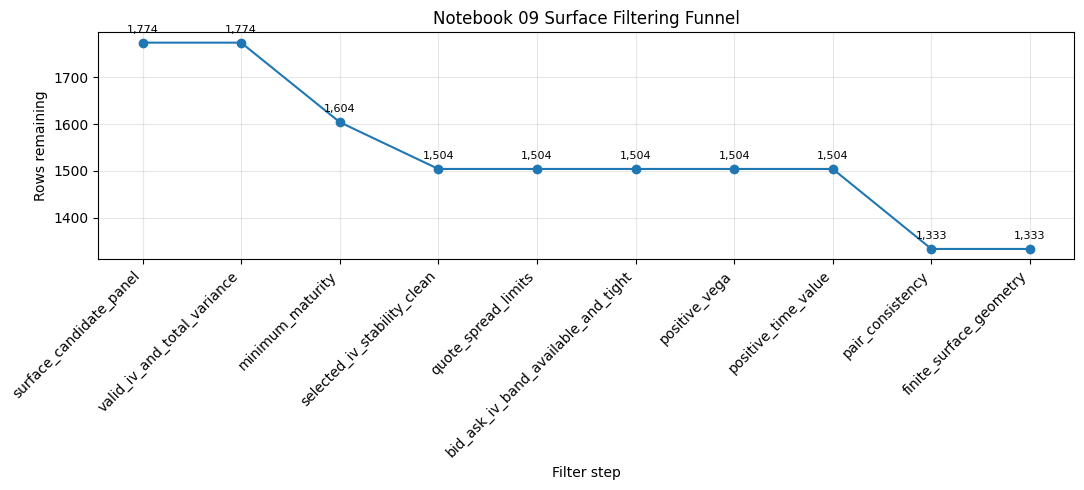

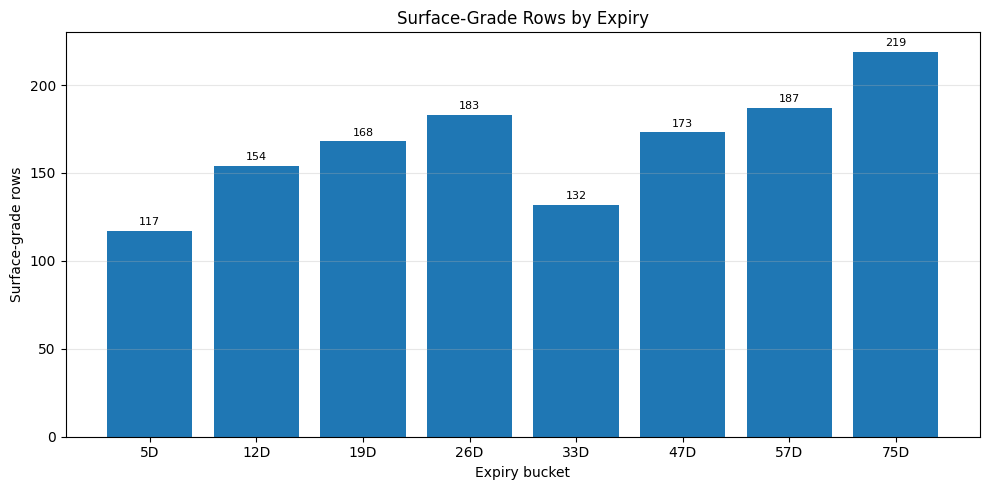

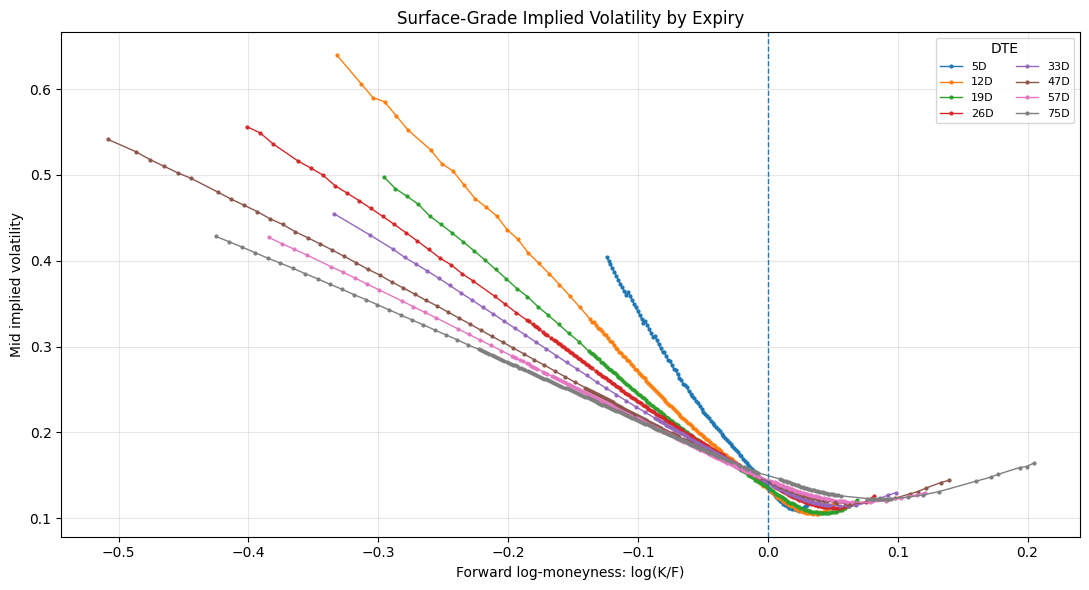

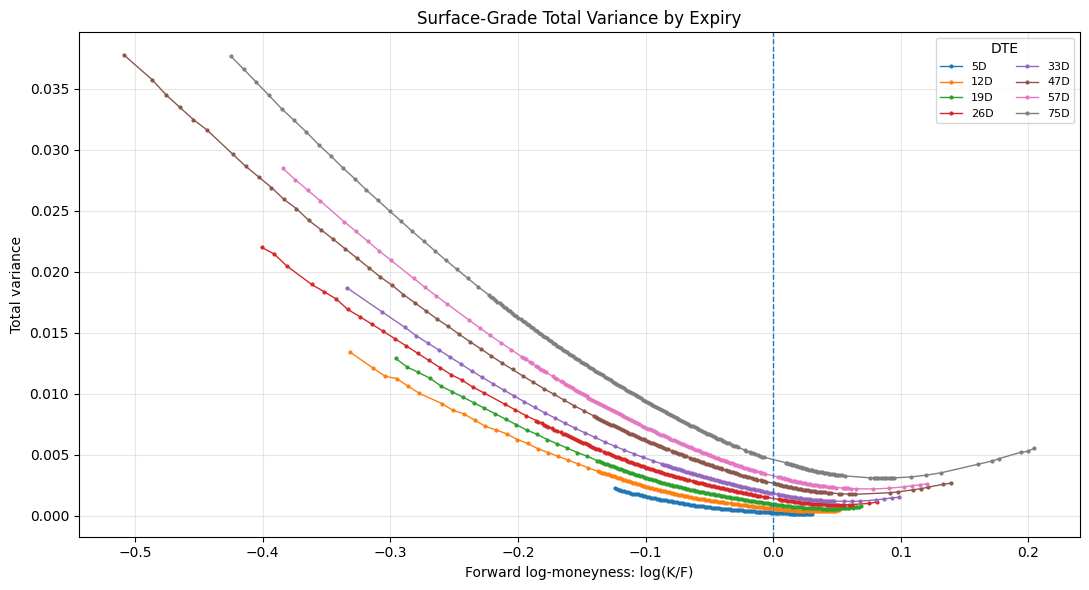

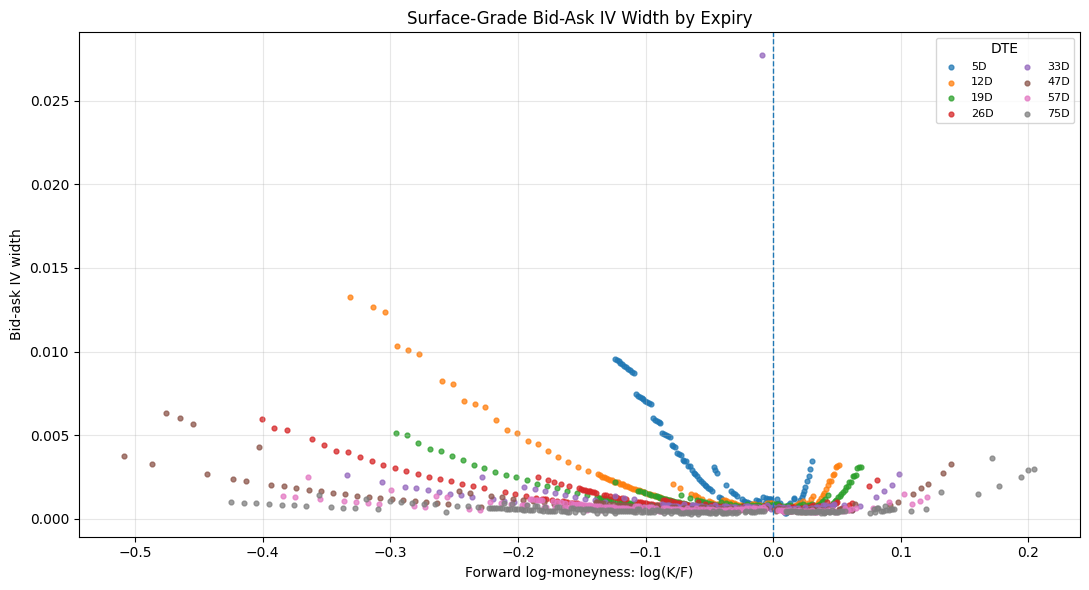

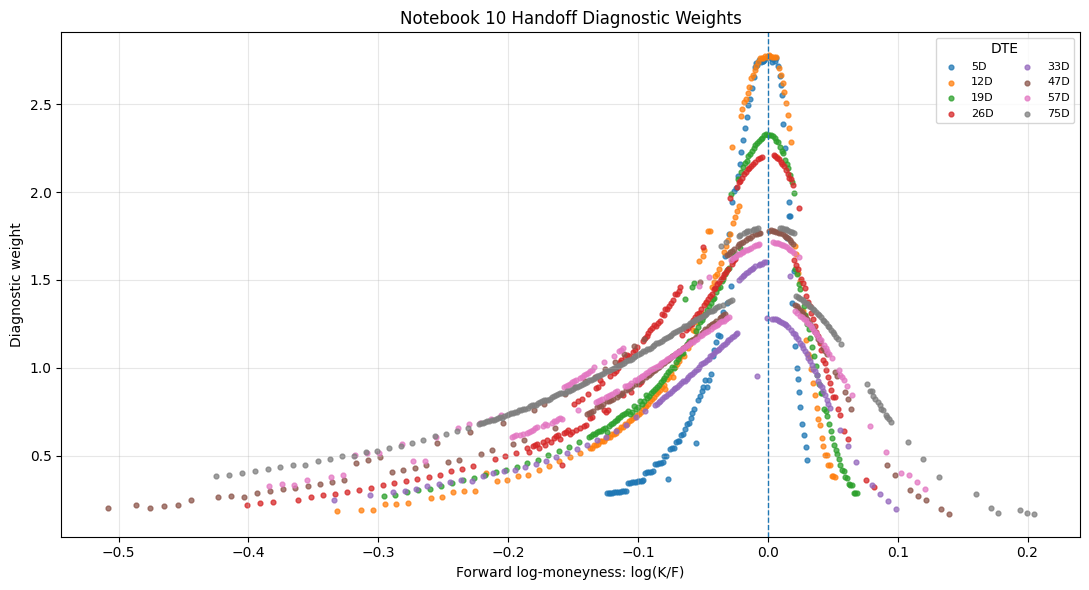

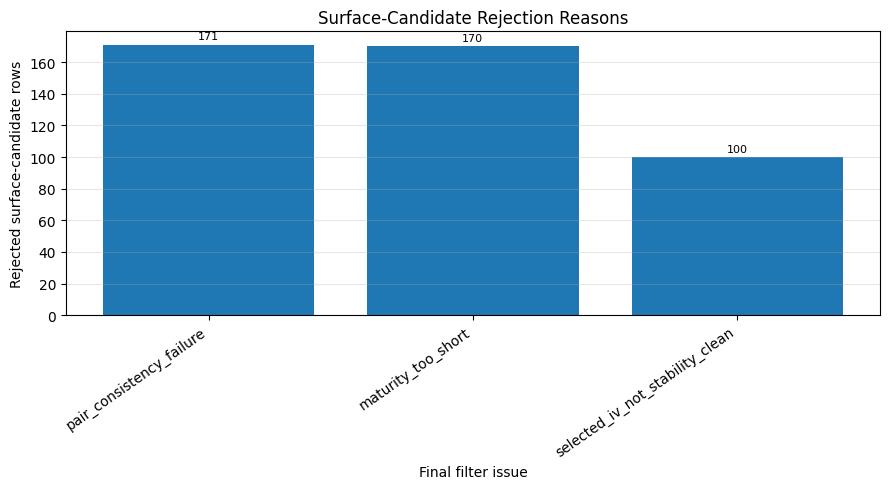

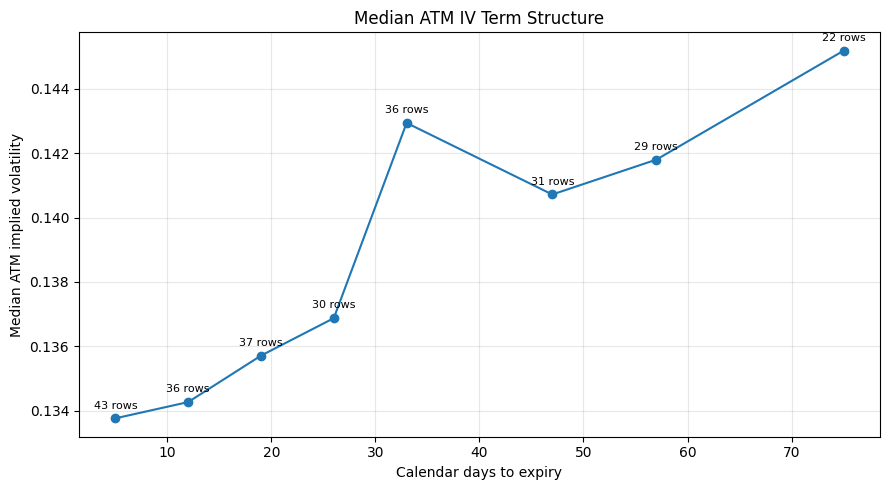

,plot_title,filename,path,exists,size_kb
0,Notebook 09 Surface Filtering Funnel,n09_filter_funnel_20260705_154512_UTC.png,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,107.371094
1,Surface-Grade Rows by Expiry,n09_surface_grade_rows_by_expiry_20260705_1545...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,36.933594
2,Surface-Grade Implied Volatility by Expiry,n09_surface_grade_iv_smiles_20260705_154512_UT...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,149.745117
3,Surface-Grade Total Variance by Expiry,n09_surface_grade_total_variance_20260705_1545...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,140.911133
4,Surface-Grade Bid-Ask IV Width by Expiry,n09_surface_grade_iv_band_width_20260705_15451...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,125.378906
5,Notebook 10 Handoff Diagnostic Weights,n09_handoff_diagnostic_weights_20260705_154512...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,209.609375
6,Surface-Candidate Rejection Reasons,n09_surface_rejection_reasons_20260705_154512_...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,62.171875
7,Median ATM IV Term Structure,n09_median_atm_iv_term_structure_20260705_1545...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,67.853516


,expiry,dte_calendar,atm_rows,median_atm_iv,median_atm_total_variance
0,2026-07-10 00:00:00+00:00,5.000000,43,0.133770,0.000245
1,2026-07-17 00:00:00+00:00,12.000000,36,0.134275,0.000593
2,2026-07-24 00:00:00+00:00,19.000000,37,0.135715,0.000959
3,2026-07-31 00:00:00+00:00,26.000000,30,0.136878,0.001335
4,2026-08-07 00:00:00+00:00,33.000000,36,0.142934,0.001847
5,2026-08-21 00:00:00+00:00,47.000000,31,0.140714,0.002550
6,2026-08-31 00:00:00+00:00,57.000000,29,0.141795,0.003140
7,2026-09-18 00:00:00+00:00,75.000000,22,0.145174,0.004331


,check,passed,detail
0,all diagnostic plot files were created,True,8
1,plot manifest is non-empty,True,8
2,ATM term structure has at least two expiries,True,8


Diagnostic plots complete.
Diagnostic plots saved: 8
Plot directory: D:\Derivative Pricing Project v1.0+\V1.1\outputs\09_spy_implied_volatility_inversion_and_surface_grade_filtering\diagnostics
Readiness flag: DIAGNOSTIC_PLOTS_COMPLETE


In [12]:
# ============================================================
# Diagnostic Plots
# ============================================================

# These plots summarize the N09 filtering path and the final N10 handoff surface.
#
# They are diagnostic plots only:
# - no smoothing
# - no interpolation
# - no model calibration
# - no static-arbitrage repair
#
# Notebook 10 will perform the raw static-arbitrage diagnostics.

PLOT_OUTPUT_DIR = N09_OUTPUT_DIR / "diagnostics"
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

snapshot_tag_for_plots = globals().get(
    "N08_SNAPSHOT_TAG",
    notebook_09_metadata.get("n09_snapshot_tag", "unknown_snapshot"),
)

diagnostic_plot_manifest: list[dict[str, Any]] = []


# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def save_current_plot(filename: str, title: str) -> Path:
    """
    Save the active matplotlib figure and record it in the plot manifest.
    """
    path = PLOT_OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

    diagnostic_plot_manifest.append(
        {
            "plot_title": title,
            "filename": filename,
            "path": str(path),
            "exists": path.exists(),
            "size_kb": path.stat().st_size / 1024 if path.exists() else np.nan,
        }
    )

    return path


# ------------------------------------------------------------
# 1. Filtering funnel
# ------------------------------------------------------------

funnel_plot_df = filter_funnel_table.copy()

plt.figure(figsize=(11, 5))
plt.plot(
    funnel_plot_df["step"],
    funnel_plot_df["rows_remaining"],
    marker="o",
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rows remaining")
plt.xlabel("Filter step")
plt.title("Notebook 09 Surface Filtering Funnel")
plt.grid(True, alpha=0.3)

for idx, row in funnel_plot_df.iterrows():
    plt.annotate(
        f"{int(row['rows_remaining']):,}",
        (idx, row["rows_remaining"]),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=8,
    )

save_current_plot(
    filename=f"n09_filter_funnel_{snapshot_tag_for_plots}.png",
    title="Notebook 09 Surface Filtering Funnel",
)


# ------------------------------------------------------------
# 2. Final surface-grade rows by expiry
# ------------------------------------------------------------

expiry_rows_plot_df = (
    n10_handoff_panel
    .groupby("expiry", dropna=False)
    .agg(
        rows=("n10_handoff_row_id", "size"),
        dte_calendar=("dte_calendar", "median"),
    )
    .reset_index()
    .sort_values("expiry")
)

expiry_labels = [
    f"{int(dte)}D"
    for dte in expiry_rows_plot_df["dte_calendar"]
]

plt.figure(figsize=(10, 5))
plt.bar(expiry_labels, expiry_rows_plot_df["rows"])
plt.ylabel("Surface-grade rows")
plt.xlabel("Expiry bucket")
plt.title("Surface-Grade Rows by Expiry")
plt.grid(axis="y", alpha=0.3)

for idx, row in expiry_rows_plot_df.iterrows():
    plt.annotate(
        f"{int(row['rows']):,}",
        (idx, row["rows"]),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=8,
    )

save_current_plot(
    filename=f"n09_surface_grade_rows_by_expiry_{snapshot_tag_for_plots}.png",
    title="Surface-Grade Rows by Expiry",
)


# ------------------------------------------------------------
# 3. Implied volatility smile by expiry
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

for expiry, group in n10_handoff_panel.groupby("expiry", sort=True):
    group = group.sort_values("log_moneyness")
    dte_label = int(round(group["dte_calendar"].median()))
    plt.plot(
        group["log_moneyness"],
        group["mid_iv"],
        marker=".",
        linewidth=1.0,
        markersize=4,
        label=f"{dte_label}D",
    )

plt.axvline(0.0, linewidth=1.0, linestyle="--")
plt.xlabel("Forward log-moneyness: log(K/F)")
plt.ylabel("Mid implied volatility")
plt.title("Surface-Grade Implied Volatility by Expiry")
plt.legend(title="DTE", ncols=2, fontsize=8)
plt.grid(True, alpha=0.3)

save_current_plot(
    filename=f"n09_surface_grade_iv_smiles_{snapshot_tag_for_plots}.png",
    title="Surface-Grade Implied Volatility by Expiry",
)


# ------------------------------------------------------------
# 4. Total variance by expiry
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

for expiry, group in n10_handoff_panel.groupby("expiry", sort=True):
    group = group.sort_values("log_moneyness")
    dte_label = int(round(group["dte_calendar"].median()))
    plt.plot(
        group["log_moneyness"],
        group["total_variance"],
        marker=".",
        linewidth=1.0,
        markersize=4,
        label=f"{dte_label}D",
    )

plt.axvline(0.0, linewidth=1.0, linestyle="--")
plt.xlabel("Forward log-moneyness: log(K/F)")
plt.ylabel("Total variance")
plt.title("Surface-Grade Total Variance by Expiry")
plt.legend(title="DTE", ncols=2, fontsize=8)
plt.grid(True, alpha=0.3)

save_current_plot(
    filename=f"n09_surface_grade_total_variance_{snapshot_tag_for_plots}.png",
    title="Surface-Grade Total Variance by Expiry",
)


# ------------------------------------------------------------
# 5. Bid-ask IV width by log-moneyness
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

for expiry, group in n10_handoff_panel.groupby("expiry", sort=True):
    group = group.sort_values("log_moneyness")
    dte_label = int(round(group["dte_calendar"].median()))
    plt.scatter(
        group["log_moneyness"],
        group["iv_width_bid_ask"],
        s=12,
        alpha=0.75,
        label=f"{dte_label}D",
    )

plt.axvline(0.0, linewidth=1.0, linestyle="--")
plt.xlabel("Forward log-moneyness: log(K/F)")
plt.ylabel("Bid-ask IV width")
plt.title("Surface-Grade Bid-Ask IV Width by Expiry")
plt.legend(title="DTE", ncols=2, fontsize=8)
plt.grid(True, alpha=0.3)

save_current_plot(
    filename=f"n09_surface_grade_iv_band_width_{snapshot_tag_for_plots}.png",
    title="Surface-Grade Bid-Ask IV Width by Expiry",
)


# ------------------------------------------------------------
# 6. Diagnostic weight by log-moneyness
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

for expiry, group in n10_handoff_panel.groupby("expiry", sort=True):
    group = group.sort_values("log_moneyness")
    dte_label = int(round(group["dte_calendar"].median()))
    plt.scatter(
        group["log_moneyness"],
        group["diagnostic_weight"],
        s=12,
        alpha=0.75,
        label=f"{dte_label}D",
    )

plt.axvline(0.0, linewidth=1.0, linestyle="--")
plt.xlabel("Forward log-moneyness: log(K/F)")
plt.ylabel("Diagnostic weight")
plt.title("Notebook 10 Handoff Diagnostic Weights")
plt.legend(title="DTE", ncols=2, fontsize=8)
plt.grid(True, alpha=0.3)

save_current_plot(
    filename=f"n09_handoff_diagnostic_weights_{snapshot_tag_for_plots}.png",
    title="Notebook 10 Handoff Diagnostic Weights",
)


# ------------------------------------------------------------
# 7. Surface rejection reasons
# ------------------------------------------------------------

rejection_plot_df = (
    surface_rejection_ledger["final_surface_filter_issue"]
    .value_counts(dropna=False)
    .rename_axis("reason")
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(rejection_plot_df["reason"], rejection_plot_df["rows"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Rejected surface-candidate rows")
plt.xlabel("Final filter issue")
plt.title("Surface-Candidate Rejection Reasons")
plt.grid(axis="y", alpha=0.3)

for idx, row in rejection_plot_df.iterrows():
    plt.annotate(
        f"{int(row['rows']):,}",
        (idx, row["rows"]),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=8,
    )

save_current_plot(
    filename=f"n09_surface_rejection_reasons_{snapshot_tag_for_plots}.png",
    title="Surface-Candidate Rejection Reasons",
)


# ------------------------------------------------------------
# 8. Median IV term structure around ATM
# ------------------------------------------------------------

atm_term_df = (
    n10_handoff_panel
    .loc[n10_handoff_panel["abs_log_moneyness"] <= THRESHOLDS.atm_log_moneyness_band]
    .groupby("expiry", dropna=False)
    .agg(
        dte_calendar=("dte_calendar", "median"),
        atm_rows=("n10_handoff_row_id", "size"),
        median_atm_iv=("mid_iv", "median"),
        median_atm_total_variance=("total_variance", "median"),
    )
    .reset_index()
    .sort_values("dte_calendar")
)

plt.figure(figsize=(9, 5))
plt.plot(
    atm_term_df["dte_calendar"],
    atm_term_df["median_atm_iv"],
    marker="o",
)
plt.xlabel("Calendar days to expiry")
plt.ylabel("Median ATM implied volatility")
plt.title("Median ATM IV Term Structure")
plt.grid(True, alpha=0.3)

for _, row in atm_term_df.iterrows():
    plt.annotate(
        f"{int(row['atm_rows'])} rows",
        (row["dte_calendar"], row["median_atm_iv"]),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=8,
    )

save_current_plot(
    filename=f"n09_median_atm_iv_term_structure_{snapshot_tag_for_plots}.png",
    title="Median ATM IV Term Structure",
)


# ------------------------------------------------------------
# Plot manifest and validation
# ------------------------------------------------------------

diagnostic_plot_manifest = pd.DataFrame(diagnostic_plot_manifest)

plot_validation = pd.DataFrame(
    [
        {
            "check": "all diagnostic plot files were created",
            "passed": bool(diagnostic_plot_manifest["exists"].all()),
            "detail": int(diagnostic_plot_manifest["exists"].sum()),
        },
        {
            "check": "plot manifest is non-empty",
            "passed": bool(len(diagnostic_plot_manifest) > 0),
            "detail": int(len(diagnostic_plot_manifest)),
        },
        {
            "check": "ATM term structure has at least two expiries",
            "passed": bool(len(atm_term_df) >= 2),
            "detail": int(len(atm_term_df)),
        },
    ]
)

display(diagnostic_plot_manifest)
display(atm_term_df)
display(plot_validation)

if not plot_validation["passed"].all():
    failed_plot_checks = plot_validation.loc[
        ~plot_validation["passed"],
        "check",
    ].tolist()
    raise ValueError(
        "Diagnostic plot validation failed: "
        + "; ".join(failed_plot_checks)
    )


# ------------------------------------------------------------
# Metadata update
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "diagnostic_plot_manifest": diagnostic_plot_manifest.to_dict(orient="records"),
        "atm_term_structure_summary": atm_term_df.to_dict(orient="records"),
        "plot_validation": plot_validation.to_dict(orient="records"),
        "diagnostic_plot_count": int(len(diagnostic_plot_manifest)),
        "diagnostic_plot_dir": str(PLOT_OUTPUT_DIR),
        "readiness_flag": "DIAGNOSTIC_PLOTS_COMPLETE",
    }
)

print("Diagnostic plots complete.")
print(f"Diagnostic plots saved: {len(diagnostic_plot_manifest):,}")
print(f"Plot directory: {PLOT_OUTPUT_DIR}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

In [13]:
# ============================================================
# Artifact Export and Final Validation
# ============================================================

# This cell writes the Notebook 09 handoff artifacts and runs the final
# readiness validation for Notebook 10.
#
# Final readiness means:
# - valid IV inversion has been completed
# - unstable observations were filtered or flagged
# - the surface-grade panel is saved
# - the Notebook 10 handoff panel is saved
# - all exclusions are auditable
#
# It does not mean the surface is arbitrage-free.

N09_ARTIFACT_TAG = globals().get(
    "N08_SNAPSHOT_TAG",
    notebook_09_metadata.get("n08_snapshot_tag", "unknown_snapshot"),
)

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

N09_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Rebuild key panels defensively
# ------------------------------------------------------------

iv_grade_panel = contract_panel.loc[
    contract_panel["iv_grade_flag"].fillna(False).astype(bool)
].copy()

iv_stability_clean_panel = contract_panel.loc[
    contract_panel["iv_stability_clean_flag"].fillna(False).astype(bool)
].copy()

surface_grade_handoff_panel = n10_handoff_panel.copy()


# ------------------------------------------------------------
# JSON-safe conversion helper
# ------------------------------------------------------------

def make_json_safe(obj: Any) -> Any:
    """
    Recursively convert pandas/numpy/path objects into JSON-safe objects.
    """
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, (pd.Timestamp, datetime)):
        return obj.isoformat()

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        value = float(obj)
        return None if not np.isfinite(value) else value

    if isinstance(obj, np.ndarray):
        return make_json_safe(obj.tolist())

    if isinstance(obj, pd.DataFrame):
        return make_json_safe(obj.to_dict(orient="records"))

    if isinstance(obj, pd.Series):
        return make_json_safe(obj.to_dict())

    if pd.isna(obj) if not isinstance(obj, (list, dict, tuple, np.ndarray, pd.DataFrame, pd.Series)) else False:
        return None

    return obj


# ------------------------------------------------------------
# File writer helpers
# ------------------------------------------------------------

artifact_write_records: list[dict[str, Any]] = []


def write_dataframe_artifact(
    df: pd.DataFrame,
    path: Path,
    artifact_name: str,
    file_role: str,
    also_csv: bool = False,
) -> None:
    """
    Write a DataFrame artifact and record it in the manifest.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    else:
        raise ValueError(f"Unsupported DataFrame artifact suffix: {path.suffix}")

    artifact_write_records.append(
        {
            "artifact_name": artifact_name,
            "file_role": file_role,
            "path": str(path),
            "suffix": path.suffix.lower(),
            "rows": int(len(df)),
            "columns": int(df.shape[1]),
            "exists": path.exists(),
            "size_mb": path.stat().st_size / 1_000_000 if path.exists() else np.nan,
        }
    )

    if also_csv and path.suffix.lower() == ".parquet":
        csv_path = path.with_suffix(".csv")
        df.to_csv(csv_path, index=False)

        artifact_write_records.append(
            {
                "artifact_name": artifact_name + "_csv_copy",
                "file_role": file_role + "_csv_copy",
                "path": str(csv_path),
                "suffix": ".csv",
                "rows": int(len(df)),
                "columns": int(df.shape[1]),
                "exists": csv_path.exists(),
                "size_mb": csv_path.stat().st_size / 1_000_000 if csv_path.exists() else np.nan,
            }
        )


def write_json_artifact(
    payload: dict[str, Any],
    path: Path,
    artifact_name: str,
    file_role: str,
) -> None:
    """
    Write a JSON artifact and record it in the manifest.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe(payload), f, indent=2)

    artifact_write_records.append(
        {
            "artifact_name": artifact_name,
            "file_role": file_role,
            "path": str(path),
            "suffix": ".json",
            "rows": np.nan,
            "columns": np.nan,
            "exists": path.exists(),
            "size_mb": path.stat().st_size / 1_000_000 if path.exists() else np.nan,
        }
    )


# ------------------------------------------------------------
# Core output paths
# ------------------------------------------------------------

artifact_paths = {
    "contract_panel": N09_OUTPUT_DIR / f"spy_n09_contract_panel_{N09_ARTIFACT_TAG}.parquet",
    "iv_grade_panel": N09_OUTPUT_DIR / f"spy_n09_iv_grade_panel_{N09_ARTIFACT_TAG}.parquet",
    "iv_stability_clean_panel": N09_OUTPUT_DIR / f"spy_n09_iv_stability_clean_panel_{N09_ARTIFACT_TAG}.parquet",
    "surface_candidate_panel": N09_OUTPUT_DIR / f"spy_n09_surface_candidate_panel_{N09_ARTIFACT_TAG}.parquet",
    "surface_filter_panel": N09_OUTPUT_DIR / f"spy_n09_surface_filter_panel_{N09_ARTIFACT_TAG}.parquet",
    "surface_grade_panel": N09_OUTPUT_DIR / f"spy_n09_surface_grade_panel_{N09_ARTIFACT_TAG}.parquet",
    "n10_handoff_panel": N09_OUTPUT_DIR / f"spy_n09_n10_handoff_panel_{N09_ARTIFACT_TAG}.parquet",
    "contract_audit_ledger": N09_OUTPUT_DIR / f"spy_n09_contract_audit_ledger_{N09_ARTIFACT_TAG}.parquet",
    "surface_rejection_ledger": N09_OUTPUT_DIR / f"spy_n09_surface_rejection_ledger_{N09_ARTIFACT_TAG}.csv",
    "surface_acceptance_ledger": N09_OUTPUT_DIR / f"spy_n09_surface_acceptance_ledger_{N09_ARTIFACT_TAG}.csv",
    "expiry_viability_table": N09_OUTPUT_DIR / f"spy_n09_expiry_viability_table_{N09_ARTIFACT_TAG}.csv",
    "filter_funnel_table": N09_OUTPUT_DIR / f"spy_n09_filter_funnel_table_{N09_ARTIFACT_TAG}.csv",
    "diagnostic_plot_manifest": N09_OUTPUT_DIR / f"spy_n09_diagnostic_plot_manifest_{N09_ARTIFACT_TAG}.csv",
    "notebook09_metadata": N09_OUTPUT_DIR / f"spy_n09_metadata_{N09_ARTIFACT_TAG}.json",
    "artifact_manifest_csv": N09_OUTPUT_DIR / f"spy_n09_artifact_manifest_{N09_ARTIFACT_TAG}.csv",
    "artifact_manifest_json": N09_OUTPUT_DIR / f"spy_n09_artifact_manifest_{N09_ARTIFACT_TAG}.json",
    "final_validation_ledger": N09_OUTPUT_DIR / f"spy_n09_final_validation_ledger_{N09_ARTIFACT_TAG}.csv",
}

processed_handoff_paths = {
    "n10_handoff_panel_processed": PROCESSED_DATA_DIR / f"spy_option_n10_handoff_{N09_ARTIFACT_TAG}.parquet",
    "surface_grade_panel_processed": PROCESSED_DATA_DIR / f"spy_option_surface_grade_panel_{N09_ARTIFACT_TAG}.parquet",
    "notebook09_artifact_manifest_processed": PROCESSED_DATA_DIR / f"spy_notebook09_artifact_manifest_{N09_ARTIFACT_TAG}.csv",
    "notebook09_final_validation_processed": PROCESSED_DATA_DIR / f"spy_notebook09_final_validation_ledger_{N09_ARTIFACT_TAG}.csv",
}


# ------------------------------------------------------------
# Final validation before writing final metadata
# ------------------------------------------------------------

final_handoff_summary = pd.DataFrame(
    [
        {"metric": "contract_panel_rows", "value": int(len(contract_panel))},
        {"metric": "iv_grade_rows", "value": int(len(iv_grade_panel))},
        {"metric": "iv_stability_clean_rows", "value": int(len(iv_stability_clean_panel))},
        {"metric": "surface_candidate_rows", "value": int(len(surface_candidate_panel))},
        {"metric": "surface_grade_rows", "value": int(len(surface_grade_panel))},
        {"metric": "n10_handoff_rows", "value": int(len(surface_grade_handoff_panel))},
        {"metric": "surface_rejection_ledger_rows", "value": int(len(surface_rejection_ledger))},
        {"metric": "contract_audit_ledger_rows", "value": int(len(contract_audit_ledger))},
        {"metric": "surface_grade_expiries", "value": int(surface_grade_panel["expiry"].nunique())},
        {"metric": "n10_handoff_expiries", "value": int(surface_grade_handoff_panel["expiry"].nunique())},
        {"metric": "diagnostic_plot_count", "value": int(len(diagnostic_plot_manifest))},
    ]
)

notebook09_final_validation_ledger = pd.DataFrame(
    [
        {
            "check": "contract panel is non-empty",
            "passed": bool(len(contract_panel) > 0),
            "detail": int(len(contract_panel)),
        },
        {
            "check": "IV-grade panel is non-empty",
            "passed": bool(len(iv_grade_panel) > 0),
            "detail": int(len(iv_grade_panel)),
        },
        {
            "check": "stability-clean panel is non-empty",
            "passed": bool(len(iv_stability_clean_panel) > 0),
            "detail": int(len(iv_stability_clean_panel)),
        },
        {
            "check": "surface candidate panel is non-empty",
            "passed": bool(len(surface_candidate_panel) > 0),
            "detail": int(len(surface_candidate_panel)),
        },
        {
            "check": "surface-grade panel is non-empty",
            "passed": bool(len(surface_grade_panel) > 0),
            "detail": int(len(surface_grade_panel)),
        },
        {
            "check": "N10 handoff row count equals surface-grade row count",
            "passed": bool(len(surface_grade_handoff_panel) == len(surface_grade_panel)),
            "detail": int(len(surface_grade_handoff_panel)),
        },
        {
            "check": "N10 handoff expiry count equals surface-grade expiry count",
            "passed": bool(
                surface_grade_handoff_panel["expiry"].nunique()
                == surface_grade_panel["expiry"].nunique()
            ),
            "detail": int(surface_grade_handoff_panel["expiry"].nunique()),
        },
        {
            "check": "N10 handoff has no duplicate expiry-strike rows",
            "passed": bool(
                surface_grade_handoff_panel[["expiry", "strike"]]
                .duplicated()
                .sum()
                == 0
            ),
            "detail": int(
                surface_grade_handoff_panel[["expiry", "strike"]]
                .duplicated()
                .sum()
            ),
        },
        {
            "check": "N10 handoff has finite positive IV",
            "passed": bool(
                (
                    surface_grade_handoff_panel["mid_iv"].notna()
                    & np.isfinite(surface_grade_handoff_panel["mid_iv"])
                    & (surface_grade_handoff_panel["mid_iv"] > 0)
                ).all()
            ),
            "detail": int(len(surface_grade_handoff_panel)),
        },
        {
            "check": "N10 handoff has finite nonnegative total variance",
            "passed": bool(
                (
                    surface_grade_handoff_panel["total_variance"].notna()
                    & np.isfinite(surface_grade_handoff_panel["total_variance"])
                    & (surface_grade_handoff_panel["total_variance"] >= 0)
                ).all()
            ),
            "detail": int(len(surface_grade_handoff_panel)),
        },
        {
            "check": "surface rejection plus acceptance equals surface candidates",
            "passed": bool(
                len(surface_rejection_ledger) + len(surface_acceptance_ledger)
                == len(surface_filter_panel)
            ),
            "detail": int(len(surface_rejection_ledger) + len(surface_acceptance_ledger)),
        },
        {
            "check": "contract audit ledger covers contract panel",
            "passed": bool(len(contract_audit_ledger) == len(contract_panel)),
            "detail": int(len(contract_audit_ledger)),
        },
        {
            "check": "filter funnel ends at surface-grade row count",
            "passed": bool(
                int(filter_funnel_table["rows_remaining"].iloc[-1])
                == len(surface_grade_panel)
            ),
            "detail": int(filter_funnel_table["rows_remaining"].iloc[-1]),
        },
        {
            "check": "diagnostic plots were created",
            "passed": bool(
                len(diagnostic_plot_manifest) > 0
                and diagnostic_plot_manifest["exists"].all()
            ),
            "detail": int(len(diagnostic_plot_manifest)),
        },
        {
            "check": "ready for Notebook 10 raw diagnostics",
            "passed": bool(
                len(surface_grade_handoff_panel) > 0
                and surface_grade_handoff_panel["expiry"].nunique() >= 2
            ),
            "detail": int(surface_grade_handoff_panel["expiry"].nunique()),
        },
    ]
)

NOTEBOOK_09_READY_FOR_10 = bool(notebook09_final_validation_ledger["passed"].all())
NOTEBOOK_09_STATUS = "READY_FOR_10" if NOTEBOOK_09_READY_FOR_10 else "FAILED_FINAL_VALIDATION"


# ------------------------------------------------------------
# Metadata update before export
# ------------------------------------------------------------

notebook_09_metadata.update(
    {
        "final_validation_completed": True,
        "final_validation_timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "final_handoff_summary": final_handoff_summary.to_dict(orient="records"),
        "final_validation_ledger": notebook09_final_validation_ledger.to_dict(orient="records"),
        "NOTEBOOK_09_READY_FOR_10": NOTEBOOK_09_READY_FOR_10,
        "NOTEBOOK_09_STATUS": NOTEBOOK_09_STATUS,
        "readiness_flag": NOTEBOOK_09_STATUS,
    }
)


# ------------------------------------------------------------
# Write Notebook 09 output artifacts
# ------------------------------------------------------------

write_dataframe_artifact(
    contract_panel,
    artifact_paths["contract_panel"],
    "contract_panel",
    "full_contract_panel_with_iv_diagnostics",
)

write_dataframe_artifact(
    iv_grade_panel,
    artifact_paths["iv_grade_panel"],
    "iv_grade_panel",
    "valid_mid_iv_rows",
)

write_dataframe_artifact(
    iv_stability_clean_panel,
    artifact_paths["iv_stability_clean_panel"],
    "iv_stability_clean_panel",
    "iv_grade_rows_without_stability_warnings",
)

write_dataframe_artifact(
    surface_candidate_panel,
    artifact_paths["surface_candidate_panel"],
    "surface_candidate_panel",
    "one_observation_per_expiry_strike_before_strict_surface_filtering",
)

write_dataframe_artifact(
    surface_filter_panel,
    artifact_paths["surface_filter_panel"],
    "surface_filter_panel",
    "surface_candidate_panel_with_filter_flags",
)

write_dataframe_artifact(
    surface_grade_panel,
    artifact_paths["surface_grade_panel"],
    "surface_grade_panel",
    "strict_surface_grade_panel",
)

write_dataframe_artifact(
    surface_grade_handoff_panel,
    artifact_paths["n10_handoff_panel"],
    "n10_handoff_panel",
    "compact_notebook10_handoff_panel",
    also_csv=True,
)

write_dataframe_artifact(
    contract_audit_ledger,
    artifact_paths["contract_audit_ledger"],
    "contract_audit_ledger",
    "contract_level_audit_trail",
)

write_dataframe_artifact(
    surface_rejection_ledger,
    artifact_paths["surface_rejection_ledger"],
    "surface_rejection_ledger",
    "surface_candidate_rejection_ledger",
)

write_dataframe_artifact(
    surface_acceptance_ledger,
    artifact_paths["surface_acceptance_ledger"],
    "surface_acceptance_ledger",
    "surface_candidate_acceptance_ledger",
)

write_dataframe_artifact(
    expiry_viability_table,
    artifact_paths["expiry_viability_table"],
    "expiry_viability_table",
    "expiry_level_surface_viability",
)

write_dataframe_artifact(
    filter_funnel_table,
    artifact_paths["filter_funnel_table"],
    "filter_funnel_table",
    "sequential_surface_filter_funnel",
)

write_dataframe_artifact(
    diagnostic_plot_manifest,
    artifact_paths["diagnostic_plot_manifest"],
    "diagnostic_plot_manifest",
    "saved_diagnostic_plot_manifest",
)

write_dataframe_artifact(
    notebook09_final_validation_ledger,
    artifact_paths["final_validation_ledger"],
    "final_validation_ledger",
    "notebook09_final_validation_results",
)

write_json_artifact(
    notebook_09_metadata,
    artifact_paths["notebook09_metadata"],
    "notebook09_metadata",
    "notebook09_metadata_json",
)


# ------------------------------------------------------------
# Write Notebook 10 handoff copies into data/processed
# ------------------------------------------------------------

write_dataframe_artifact(
    surface_grade_handoff_panel,
    processed_handoff_paths["n10_handoff_panel_processed"],
    "n10_handoff_panel_processed_copy",
    "processed_directory_handoff_for_notebook10",
)

write_dataframe_artifact(
    surface_grade_panel,
    processed_handoff_paths["surface_grade_panel_processed"],
    "surface_grade_panel_processed_copy",
    "processed_directory_surface_grade_panel",
)


# ------------------------------------------------------------
# Build and write artifact manifest
# ------------------------------------------------------------

notebook09_artifact_manifest = pd.DataFrame(artifact_write_records)

notebook09_artifact_manifest["notebook_id"] = NOTEBOOK_ID
notebook09_artifact_manifest["notebook_short_name"] = NOTEBOOK_SHORT_NAME
notebook09_artifact_manifest["underlying"] = UNDERLYING
notebook09_artifact_manifest["artifact_tag"] = N09_ARTIFACT_TAG
notebook09_artifact_manifest["created_utc"] = datetime.now(timezone.utc).isoformat(timespec="seconds")

notebook09_artifact_manifest = notebook09_artifact_manifest[
    [
        "notebook_id",
        "notebook_short_name",
        "underlying",
        "artifact_tag",
        "created_utc",
        "artifact_name",
        "file_role",
        "suffix",
        "rows",
        "columns",
        "exists",
        "size_mb",
        "path",
    ]
]

notebook09_artifact_manifest.to_csv(
    artifact_paths["artifact_manifest_csv"],
    index=False,
)

with open(artifact_paths["artifact_manifest_json"], "w", encoding="utf-8") as f:
    json.dump(
        make_json_safe(notebook09_artifact_manifest.to_dict(orient="records")),
        f,
        indent=2,
    )

# Add manifest entries for the manifest files themselves.
for manifest_path, artifact_name, file_role in [
    (
        artifact_paths["artifact_manifest_csv"],
        "artifact_manifest_csv",
        "notebook09_artifact_manifest_csv",
    ),
    (
        artifact_paths["artifact_manifest_json"],
        "artifact_manifest_json",
        "notebook09_artifact_manifest_json",
    ),
]:
    notebook09_artifact_manifest = pd.concat(
        [
            notebook09_artifact_manifest,
            pd.DataFrame(
                [
                    {
                        "notebook_id": NOTEBOOK_ID,
                        "notebook_short_name": NOTEBOOK_SHORT_NAME,
                        "underlying": UNDERLYING,
                        "artifact_tag": N09_ARTIFACT_TAG,
                        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                        "artifact_name": artifact_name,
                        "file_role": file_role,
                        "suffix": manifest_path.suffix.lower(),
                        "rows": np.nan,
                        "columns": np.nan,
                        "exists": manifest_path.exists(),
                        "size_mb": manifest_path.stat().st_size / 1_000_000 if manifest_path.exists() else np.nan,
                        "path": str(manifest_path),
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

# Rewrite manifest with self-references included.
notebook09_artifact_manifest.to_csv(
    artifact_paths["artifact_manifest_csv"],
    index=False,
)

with open(artifact_paths["artifact_manifest_json"], "w", encoding="utf-8") as f:
    json.dump(
        make_json_safe(notebook09_artifact_manifest.to_dict(orient="records")),
        f,
        indent=2,
    )

# Processed directory convenience copies.
notebook09_artifact_manifest.to_csv(
    processed_handoff_paths["notebook09_artifact_manifest_processed"],
    index=False,
)

notebook09_final_validation_ledger.to_csv(
    processed_handoff_paths["notebook09_final_validation_processed"],
    index=False,
)


# ------------------------------------------------------------
# Artifact write validation
# ------------------------------------------------------------

artifact_export_validation = pd.DataFrame(
    [
        {
            "check": "all registered artifacts exist",
            "passed": bool(notebook09_artifact_manifest["exists"].all()),
            "detail": int(notebook09_artifact_manifest["exists"].sum()),
        },
        {
            "check": "N10 handoff written to output directory",
            "passed": bool(artifact_paths["n10_handoff_panel"].exists()),
            "detail": str(artifact_paths["n10_handoff_panel"]),
        },
        {
            "check": "N10 handoff written to processed directory",
            "passed": bool(processed_handoff_paths["n10_handoff_panel_processed"].exists()),
            "detail": str(processed_handoff_paths["n10_handoff_panel_processed"]),
        },
        {
            "check": "metadata JSON written",
            "passed": bool(artifact_paths["notebook09_metadata"].exists()),
            "detail": str(artifact_paths["notebook09_metadata"]),
        },
        {
            "check": "final validation passed",
            "passed": bool(NOTEBOOK_09_READY_FOR_10),
            "detail": NOTEBOOK_09_STATUS,
        },
    ]
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(final_handoff_summary)
display(notebook09_final_validation_ledger)
display(artifact_export_validation)
display(notebook09_artifact_manifest)

if not artifact_export_validation["passed"].all():
    failed_export_checks = artifact_export_validation.loc[
        ~artifact_export_validation["passed"],
        "check",
    ].tolist()
    raise ValueError(
        "Notebook 09 artifact export validation failed: "
        + "; ".join(failed_export_checks)
    )

if not NOTEBOOK_09_READY_FOR_10:
    failed_final_checks = notebook09_final_validation_ledger.loc[
        ~notebook09_final_validation_ledger["passed"],
        "check",
    ].tolist()
    raise ValueError(
        "Notebook 09 final validation failed: "
        + "; ".join(failed_final_checks)
    )

print("Notebook 09 artifact export complete.")
print(f"Notebook 09 status: {NOTEBOOK_09_STATUS}")
print(f"N10 handoff rows: {len(surface_grade_handoff_panel):,}")
print(f"N10 handoff expiries: {surface_grade_handoff_panel['expiry'].nunique():,}")
print(f"Output directory: {N09_OUTPUT_DIR}")
print(f"Processed handoff path: {processed_handoff_paths['n10_handoff_panel_processed']}")
print("Readiness flag:", notebook_09_metadata["readiness_flag"])

,metric,value
0,contract_panel_rows,3527
1,iv_grade_rows,3479
2,iv_stability_clean_rows,1890
3,surface_candidate_rows,1774
4,surface_grade_rows,1333
5,n10_handoff_rows,1333
6,surface_rejection_ledger_rows,441
7,contract_audit_ledger_rows,3527
8,surface_grade_expiries,8
9,n10_handoff_expiries,8


,check,passed,detail
0,contract panel is non-empty,True,3527
1,IV-grade panel is non-empty,True,3479
2,stability-clean panel is non-empty,True,1890
3,surface candidate panel is non-empty,True,1774
4,surface-grade panel is non-empty,True,1333
5,N10 handoff row count equals surface-grade row...,True,1333
6,N10 handoff expiry count equals surface-grade ...,True,8
7,N10 handoff has no duplicate expiry-strike rows,True,0
8,N10 handoff has finite positive IV,True,1333
9,N10 handoff has finite nonnegative total variance,True,1333


,check,passed,detail
0,all registered artifacts exist,True,20
1,N10 handoff written to output directory,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
2,N10 handoff written to processed directory,True,D:\Derivative Pricing Project v1.0+\V1.1\data\...
3,metadata JSON written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
4,final validation passed,True,READY_FOR_10


,notebook_id,notebook_short_name,underlying,artifact_tag,created_utc,artifact_name,file_role,suffix,rows,columns,exists,size_mb,path
0,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,contract_panel,full_contract_panel_with_iv_diagnostics,.parquet,"3,527.000000",193.000000,True,1.216375,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
1,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,iv_grade_panel,valid_mid_iv_rows,.parquet,"3,479.000000",193.000000,True,1.202800,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
2,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,iv_stability_clean_panel,iv_grade_rows_without_stability_warnings,.parquet,"1,890.000000",193.000000,True,0.715647,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
3,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,surface_candidate_panel,one_observation_per_expiry_strike_before_stric...,.parquet,"1,774.000000",72.000000,True,0.434989,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
4,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,surface_filter_panel,surface_candidate_panel_with_filter_flags,.parquet,"1,774.000000",88.000000,True,0.446410,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
5,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,surface_grade_panel,strict_surface_grade_panel,.parquet,"1,333.000000",89.000000,True,0.358116,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
6,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,n10_handoff_panel,compact_notebook10_handoff_panel,.parquet,"1,333.000000",55.000000,True,0.352948,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
7,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,n10_handoff_panel_csv_copy,compact_notebook10_handoff_panel_csv_copy,.csv,"1,333.000000",55.000000,True,1.122068,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
8,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,contract_audit_ledger,contract_level_audit_trail,.parquet,"3,527.000000",61.000000,True,0.580808,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
9,09_spy_implied_volatility_inversion_and_surfac...,N09,SPY,20260705_154512_UTC,2026-07-05T17:37:15+00:00,surface_rejection_ledger,surface_candidate_rejection_ledger,.csv,441.000000,41.000000,True,0.233761,D:\Derivative Pricing Project v1.0+\V1.1\outpu...


Notebook 09 artifact export complete.
Notebook 09 status: READY_FOR_10
N10 handoff rows: 1,333
N10 handoff expiries: 8
Output directory: D:\Derivative Pricing Project v1.0+\V1.1\outputs\09_spy_implied_volatility_inversion_and_surface_grade_filtering
Processed handoff path: D:\Derivative Pricing Project v1.0+\V1.1\data\processed\spy_option_n10_handoff_20260705_154512_UTC.parquet
Readiness flag: READY_FOR_10


## Notebook 09 Final Summary

Notebook 09 completed successfully.

The notebook converted the Notebook 08 SPY quote-quality option panel into a surface-grade implied-volatility handoff panel for Notebook 10.

Final status:

`READY_FOR_10`

---

## Final row counts

| Stage | Rows |
|---|---:|
| Notebook 08 candidate rows | 3,527 |
| IV-grade rows | 3,479 |
| IV stability-clean rows | 1,890 |
| Surface-candidate rows | 1,774 |
| Surface-grade rows | 1,333 |
| Notebook 10 handoff rows | 1,333 |

The final surface-grade panel contains 8 viable expiries, ranging from 5 to 75 calendar days to expiry.

---

## Main exclusions

| Exclusion category | Rows |
|---|---:|
| Failed BSM mid-price bound | 48 |
| IV not stability-clean | 1,589 |
| Not selected for surface candidate | 386 |
| Surface candidate rejected after selection | 441 |

The 441 surface-candidate rejections were mainly caused by:

| Final surface filter issue | Rows |
|---|---:|
| Pair consistency failure | 171 |
| Maturity too short | 170 |
| Selected IV not stability-clean | 100 |

---

## Final handoff artifact

Notebook 10 should load:

`data/processed/spy_option_n10_handoff_20260705_154512_UTC.parquet`

This file contains the compact empirical surface panel:

- expiry
- time to maturity
- strike
- forward
- forward log-moneyness
- selected option side
- mid IV
- bid IV
- ask IV
- bid-ask IV width
- total variance
- diagnostic weight
- audit references

---

## What this notebook allows us to claim

Notebook 09 supports the following claims:

1. SPY option quotes were checked against Black-Scholes-Merton price bounds before IV inversion.
2. Mid implied volatility was successfully inverted for the IV-grade subset.
3. Low-vega, short-maturity, wide-spread, and unstable IV observations were flagged.
4. Call-put pairs were reconciled before constructing the one-observation-per-expiry-strike surface.
5. A stricter surface-grade subset was created for raw static-arbitrage diagnostics.
6. Rejections are auditable through both contract-level and surface-candidate ledgers.
7. The final Notebook 10 handoff panel passed validation.

---

## What this notebook does not claim

Notebook 09 does not claim that the surface is arbitrage-free.

It also does not claim that the surface is smooth, calibrated, repaired, or model-ready.

The correct next step is Notebook 10:

> Diagnose raw static-arbitrage violations before applying any smoothing, repair, SVI, Heston, or Bates calibration.

Ready for Notebook 10 means ready for raw surface diagnostics, not ready for calibration.